# TFM 1.- CREACIÓN DE LA BASE DE DATOS
     m o-o l o-a l o
     molopezalonso@gmail.com
     Mónica López Alonso
Creación de base de datos

In [1]:
import pandas as pd

datos = {
    "Fuente": [
        "World Bank – WDI",
        "World Bank – WGI",
        "IMF Data / WEO / DataMapper",
        "OECD Data",
        "Trading Economics / TheGlobalEconomy",
        "Damodaran NYU"
    ],
    "Qué aporta": [
        "PIB, inflación, deuda, comercio, población, balanza, desarrollo, indicadores macro",
        "Gobernanza: estabilidad política, control de corrupción, calidad regulatoria, estado de derecho, etc.",
        "PIB, inflación, desempleo, deuda pública, cuenta corriente, déficit, previsiones macro",
        "Variables macro y financieras para países OCDE",
        "Ratings soberanos, indicadores de riesgo, datos de mercado",
        "Country risk premium y default spread"
    ],
    "Frecuencia": [
        "Anual",
        "Anual",
        "Anual y algunas series trimestrales",
        "Anual/trimestral",
        "Variable",
        "Actualizaciones periódicas"
    ],
    "Librerías / acceso": [
        "wbgapi, wbdata, API Banco Mundial",
        "API Banco Mundial / descarga DataBank",
        "requests, pandas, API IMF, SDMX",
        "API SDMX, pandasdmx",
        "API, descarga, posible limitación de acceso",
        "Excel/CSV, pandas"
    ]
}

fuentes_df = pd.DataFrame(datos)

from IPython.display import display

tabla = (
    fuentes_df.style

    # Ocultar los números 0, 1, 2...
    .hide(axis="index")

    # Formato general de las celdas
    .set_properties(**{
        "text-align": "left",
        "vertical-align": "middle",
        "white-space": "normal",
        "overflow-wrap": "break-word",
        "padding": "10px",
        "border": "1px solid #dddddd",
        "font-size": "15px"
    })

    # Primera columna
    .set_properties(
        subset=["Fuente"],
        **{
            "background-color": "#d9eaf4",
            "font-weight": "bold",
            "width": "22%"
        }
    )

    # Anchos de las demás columnas
    .set_properties(
        subset=["Qué aporta"],
        **{"width": "38%"}
    )
    .set_properties(
        subset=["Frecuencia"],
        **{"width": "18%"}
    )
    .set_properties(
        subset=["Librerías / acceso"],
        **{"width": "22%"}
    )

    # Formato de la tabla y de los encabezados
    .set_table_styles([
        {
            "selector": "table",
            "props": [
                ("width", "100%"),
                ("table-layout", "fixed"),
                ("border-collapse", "collapse")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#d9eaf4"),
                ("text-align", "left"),
                ("font-weight", "bold"),
                ("padding", "10px"),
                ("border", "1px solid #dddddd")
            ]
        },
        {
            "selector": "tbody tr:nth-child(even)",
            "props": [
                ("background-color", "#f5f5f5")
            ]
        }
    ])
)

display(tabla)

Fuente,Qué aporta,Frecuencia,Librerías / acceso
World Bank – WDI,"PIB, inflación, deuda, comercio, población, balanza, desarrollo, indicadores macro",Anual,"wbgapi, wbdata, API Banco Mundial"
World Bank – WGI,"Gobernanza: estabilidad política, control de corrupción, calidad regulatoria, estado de derecho, etc.",Anual,API Banco Mundial / descarga DataBank
IMF Data / WEO / DataMapper,"PIB, inflación, desempleo, deuda pública, cuenta corriente, déficit, previsiones macro",Anual y algunas series trimestrales,"requests, pandas, API IMF, SDMX"
OECD Data,Variables macro y financieras para países OCDE,Anual/trimestral,"API SDMX, pandasdmx"
Trading Economics / TheGlobalEconomy,"Ratings soberanos, indicadores de riesgo, datos de mercado",Variable,"API, descarga, posible limitación de acceso"
Damodaran NYU,Country risk premium y default spread,Actualizaciones periódicas,"Excel/CSV, pandas"


In [24]:
#Librerias
from pathlib import Path
import time
import requests
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display

El periodo inicial seleccionado comprende los años 2000-2024. La decisión de seleccionar un horizonte temporal tan amplio, se basa en la idea de analaizar la evolucion del riesgo país durante las distintas fases del ciclo económico y observar le comportamiento de las distintas variables tanto en periodos de estabilidad como en episodios de crisis. 

En un principio se planteo coger el peridodo 2010-2025, pero se decidio cambiar debido a dos principales motivos:
- Al seleccionar 2010, perdiamos información sobre uno de los momentos más importates economicamente de europa. Por lo que al selecionar varios años antes de las crisis financiera internacional, se puede establecer unha referencia sobre la situación económica previa.
- Muchas variables/paises no tienen todavia el dato 2025

Además se plantea la idea de crear uan variable, que separe las distintas etapas económicas.
De este modo, el periodo analizado permite distinguir diferentes etapas: una fase anterior a la crisis financiera global entre 2000 y 2007; la crisis financiera internacional de 2008-2009; la crisis de deuda soberana, especialmente relevante para las economías europeas, entre 2010 y 2012; el periodo de recuperación y expansión económica comprendido entre 2013 y 2019; la crisis provocada por la pandemia durante 2020 y 2021; y el periodo reciente, desde 2022, caracterizado por el aumento de la inflación y el endurecimiento de la política monetaria.

Inicialmente se recopilarán todos los datos disponibles para este periodo. Posteriormente, la muestra definitiva utilizada en los modelos econométricos se determinará teniendo en cuenta la cobertura de cada variable y la cantidad de observaciones disponibles por país y año.

In [3]:
START_YEAR = 2000
END_YEAR = 2024

Se empieza con **World Development Indicators — WDI**, que permite descargar variables macroeconómicas de una gran cantidad de países y años.

## Primera fase: variables macroeconómicas

El primer bloque recoge la situación y evolución general de la economía de cada país. Se incorporan el crecimiento real del PIB, el PIB y el PIB per cápita ajustados por paridad de poder adquisitivo, el PIB per cápita en dólares constantes, la inflación, el desempleo, la inversión, el ahorro nacional y el tipo de cambio.

A partir del crecimiento anual del PIB se calculará también su media móvil de los últimos cinco años, con el objetivo de representar la tendencia económica del país y reducir el efecto de variaciones puntuales. Los datos proceden principalmente de los Indicadores de Desarrollo Mundial del Banco Mundial y se recopilan para el periodo 2000-2024.

In [44]:
import pandas as pd
from IPython.display import display

datos_wdi = {
    "Variable": [
        "Crecimiento real del PIB",
        "PIB per cápita",
        "PIB, PPA",
        "PIB per cápita, PPA",
        "Inflación",
        "Desempleo",
        "Inversión",
        "Ahorro nacional",
        "Tipo de cambio"
    ],
    "Código WDI": [
        "NY.GDP.MKTP.KD.ZG",
        "NY.GDP.PCAP.KD",
        "NY.GDP.MKTP.PP.KD",
        "NY.GDP.PCAP.PP.KD",
        "FP.CPI.TOTL.ZG",
        "SL.UEM.TOTL.ZS",
        "NE.GDI.TOTL.ZS",
        "NY.GNS.ICTR.ZS",
        "PA.NUS.FCRF"
    ],
    "Medida": [
        "% anual",
        "USD constantes de 2015",
        "USD internacionales constantes de 2021",
        "USD internacionales constantes de 2021 por habitante",
        "% anual",
        "% de la población activa",
        "Formación bruta de capital, % del PIB",
        "Ahorro bruto, % del PIB",
        "Moneda local por USD"
    ]
}

variables_wdi_df = pd.DataFrame(datos_wdi)

tabla_wdi = (
    variables_wdi_df.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "left",
        "vertical-align": "middle",
        "white-space": "normal",
        "overflow-wrap": "break-word",
        "padding": "10px",
        "border": "1px solid #dddddd",
        "font-size": "10px"
    })
    .set_properties(
        subset=["Variable"],
        **{
            "background-color": "#d9eaf4",
            "font-weight": "bold",
            "width": "35%"
        }
    )
    .set_properties(
        subset=["Código WDI"],
        **{
            "font-family": "monospace",
            "width": "25%"
        }
    )
    .set_properties(
        subset=["Medida"],
        **{"width": "40%"}
    )
    .set_table_styles([
        {
            "selector": "table",
            "props": [
                ("width", "100%"),
                ("table-layout", "fixed"),
                ("border-collapse", "collapse")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#d9eaf4"),
                ("text-align", "left"),
                ("font-weight", "bold"),
                ("padding", "10px"),
                ("border", "1px solid #dddddd")
            ]
        },
        {
            "selector": "tbody tr:nth-child(even) td:not(:first-child)",
            "props": [
                ("background-color", "#f5f5f5")
            ]
        }
    ])
)

display(tabla_wdi)

Variable,Código WDI,Medida
Crecimiento real del PIB,NY.GDP.MKTP.KD.ZG,% anual
PIB per cápita,NY.GDP.PCAP.KD,USD constantes de 2015
"PIB, PPA",NY.GDP.MKTP.PP.KD,USD internacionales constantes de 2021
"PIB per cápita, PPA",NY.GDP.PCAP.PP.KD,USD internacionales constantes de 2021 por habitante
Inflación,FP.CPI.TOTL.ZG,% anual
Desempleo,SL.UEM.TOTL.ZS,% de la población activa
Inversión,NE.GDI.TOTL.ZS,"Formación bruta de capital, % del PIB"
Ahorro nacional,NY.GNS.ICTR.ZS,"Ahorro bruto, % del PIB"
Tipo de cambio,PA.NUS.FCRF,Moneda local por USD


In [5]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 200)

# Carpetas del proyecto
RAW_PATH = Path("data/raw")
PROCESSED_PATH = Path("data/processed")

RAW_PATH.mkdir(parents=True, exist_ok=True)
PROCESSED_PATH.mkdir(parents=True, exist_ok=True)

BASE_URL = "https://api.worldbank.org/v2"

In [45]:
# Variables a descargar
INDICATORS = {
    "NY.GDP.MKTP.KD.ZG": "gdp_growth_pct",
    "NY.GDP.PCAP.KD": "gdp_per_capita_constant_2015_usd",
    "FP.CPI.TOTL.ZG": "inflation_cpi_pct",
    "SL.UEM.TOTL.ZS": "unemployment_pct",
    "NE.GDI.TOTL.ZS": "investment_pct_gdp",
    "NY.GNS.ICTR.ZS": "gross_savings_pct_gdp",
    "PA.NUS.FCRF": "exchange_rate_lcu_per_usd",
    "NY.GDP.MKTP.PP.KD": "gdp_ppp_constant_2021_intl_usd",
    "NY.GDP.PCAP.PP.KD": "gdp_per_capita_ppp_constant_2021_intl_usd",
}

In [7]:
# Funciones de descarga
def get_json(url, params=None, max_attempts=3):
    """
    Realiza una petición a la API con varios intentos
    en caso de que haya un error temporal de conexión.
    """
    
    last_error = None

    for attempt in range(max_attempts):
        try:
            response = requests.get(
                url,
                params=params,
                timeout=60
            )
            
            response.raise_for_status()
            return response.json()

        except (requests.RequestException, ValueError) as error:
            last_error = error
            
            if attempt < max_attempts - 1:
                wait_seconds = 2 ** attempt
                print(
                    f"Error temporal. Nuevo intento en "
                    f"{wait_seconds} segundos..."
                )
                time.sleep(wait_seconds)

    raise RuntimeError(
        f"No se pudo descargar la información: {last_error}"
    )


def download_country_metadata():
    """
    Descarga el listado de países y economías del Banco Mundial
    y elimina los agregados regionales o económicos.
    """
    
    url = f"{BASE_URL}/country"
    
    params = {
        "format": "json",
        "per_page": 400
    }

    payload = get_json(url, params=params)

    if not payload or len(payload) < 2:
        raise ValueError("La API no devolvió información de países.")

    countries = pd.json_normalize(payload[1])

    # Los agregados del Banco Mundial tienen region.id == "NA"
    countries = countries[
        countries["region.id"] != "NA"
    ].copy()

    countries = countries.rename(
        columns={
            "id": "iso3",
            "iso2Code": "iso2",
            "name": "country",
            "region.value": "region",
            "incomeLevel.value": "income_level"
        }
    )

    countries = countries[
        [
            "iso3",
            "iso2",
            "country",
            "region",
            "income_level"
        ]
    ].copy()

    countries["region"] = countries["region"].str.strip()
    countries["income_level"] = countries["income_level"].str.strip()

    return countries


def download_indicator(indicator_code, variable_name):
    """
    Descarga una variable de WDI para todos los países
    entre START_YEAR y END_YEAR.
    """
    
    url = (
        f"{BASE_URL}/country/all/"
        f"indicator/{indicator_code}"
    )

    params = {
        "format": "json",
        "date": f"{START_YEAR}:{END_YEAR}",
        "per_page": 20000,
        "source": 2
    }

    payload = get_json(url, params=params)

    if (
        not payload
        or len(payload) < 2
        or payload[1] is None
    ):
        print(f"Sin datos para {indicator_code}")
        return pd.DataFrame()

    data = pd.DataFrame(payload[1])

    data = data.rename(
        columns={
            "countryiso3code": "iso3",
            "date": "year",
            "value": "value"
        }
    )

    data["year"] = pd.to_numeric(
        data["year"],
        errors="coerce"
    ).astype("Int64")

    data["value"] = pd.to_numeric(
        data["value"],
        errors="coerce"
    )

    data["indicator_code"] = indicator_code
    data["variable"] = variable_name

    return data[
        [
            "iso3",
            "year",
            "indicator_code",
            "variable",
            "value"
        ]
    ]

In [46]:
# Descarga de datos 
# Metadatos de países
countries = download_country_metadata()

print(
    f"Número de países y economías, "
    f"excluyendo agregados: {countries['iso3'].nunique()}"
)

# Descarga de cada variable
downloaded_data = []

for indicator_code, variable_name in INDICATORS.items():
    
    print(
        f"Descargando {variable_name} "
        f"({indicator_code})..."
    )
    
    indicator_data = download_indicator(
        indicator_code=indicator_code,
        variable_name=variable_name
    )

    downloaded_data.append(indicator_data)

# Base en formato largo
wdi_macro_long = pd.concat(
    downloaded_data,
    ignore_index=True
)

# Eliminamos agregados conservando únicamente códigos
# incluidos en la tabla de países
wdi_macro_long = wdi_macro_long[
    wdi_macro_long["iso3"].isin(countries["iso3"])
].copy()

wdi_macro_long = wdi_macro_long.sort_values(
    ["iso3", "year", "variable"]
).reset_index(drop=True)

wdi_macro_long.head(20)

Número de países y economías, excluyendo agregados: 217
Descargando gdp_growth_pct (NY.GDP.MKTP.KD.ZG)...
Descargando gdp_per_capita_constant_2015_usd (NY.GDP.PCAP.KD)...
Error temporal. Nuevo intento en 1 segundos...
Error temporal. Nuevo intento en 2 segundos...
Descargando inflation_cpi_pct (FP.CPI.TOTL.ZG)...
Error temporal. Nuevo intento en 1 segundos...
Descargando unemployment_pct (SL.UEM.TOTL.ZS)...
Descargando investment_pct_gdp (NE.GDI.TOTL.ZS)...
Error temporal. Nuevo intento en 1 segundos...
Descargando gross_savings_pct_gdp (NY.GNS.ICTR.ZS)...
Error temporal. Nuevo intento en 1 segundos...
Descargando exchange_rate_lcu_per_usd (PA.NUS.FCRF)...
Descargando gdp_ppp_constant_2021_intl_usd (NY.GDP.MKTP.PP.KD)...
Descargando gdp_per_capita_ppp_constant_2021_intl_usd (NY.GDP.PCAP.PP.KD)...


,iso3,year,indicator_code,variable,value
0,ABW,2000,PA.NUS.FCRF,exchange_rate_lcu_per_usd,1.790000e+00
1,ABW,2000,NY.GDP.MKTP.KD.ZG,gdp_growth_pct,7.622921e+00
2,ABW,2000,NY.GDP.PCAP.KD,gdp_per_capita_constant_2015_usd,2.810490e+04
3,ABW,2000,NY.GDP.PCAP.PP.KD,gdp_per_capita_ppp_constant_2021_intl_usd,3.761899e+04
4,ABW,2000,NY.GDP.MKTP.PP.KD,gdp_ppp_constant_2021_intl_usd,3.407829e+09
5,ABW,2000,NY.GNS.ICTR.ZS,gross_savings_pct_gdp,2.371464e+01
6,ABW,2000,FP.CPI.TOTL.ZG,inflation_cpi_pct,4.044021e+00
7,ABW,2000,NE.GDI.TOTL.ZS,investment_pct_gdp,2.549411e+01
8,ABW,2000,SL.UEM.TOTL.ZS,unemployment_pct,NaN
9,ABW,2001,PA.NUS.FCRF,exchange_rate_lcu_per_usd,1.790000e+00


In [47]:
# Creamos todas las combinaciones de país y año,
# incluso cuando falten todos los indicadores
years = pd.DataFrame({
    "year": range(START_YEAR, END_YEAR + 1)
})

country_year_grid = countries.merge(
    years,
    how="cross"
)

# Pasamos las variables de filas a columnas
wdi_values_wide = (
    wdi_macro_long
    .pivot_table(
        index=["iso3", "year"],
        columns="variable",
        values="value",
        aggfunc="first"
    )
    .reset_index()
)

wdi_values_wide.columns.name = None

# Panel definitivo del bloque macroeconómico
wdi_macro_panel = country_year_grid.merge(
    wdi_values_wide,
    on=["iso3", "year"],
    how="left"
)

wdi_macro_panel = wdi_macro_panel.sort_values(
    ["iso3", "year"]
).reset_index(drop=True)

print("Dimensiones del panel:", wdi_macro_panel.shape)

#wdi_macro_panel.head(20)

Dimensiones del panel: (5425, 15)


In [48]:
## Clasificación de los periodos económicos
def classify_period(year):
    """
    Clasifica cada año en uno de los principales
    periodos económicos de la muestra.
    """
    
    if 2000 <= year <= 2007:
        return "Pre-crisis financiera"
    
    elif 2008 <= year <= 2009:
        return "Crisis financiera global"
    
    elif 2010 <= year <= 2012:
        return "Crisis de deuda soberana"
    
    elif 2013 <= year <= 2019:
        return "Recuperación y expansión"
    
    elif 2020 <= year <= 2021:
        return "Pandemia"
    
    elif 2022 <= year <= 2024:
        return "Inflación y endurecimiento monetario"
    
    else:
        return "Fuera del periodo analizado"


wdi_macro_panel["economic_period"] = (
    wdi_macro_panel["year"].apply(classify_period)
)

# orden cornológico 
period_order = [
    "Pre-crisis financiera",
    "Crisis financiera global",
    "Crisis de deuda soberana",
    "Recuperación y expansión",
    "Pandemia",
    "Inflación y endurecimiento monetario"
]

wdi_macro_panel["economic_period"] = pd.Categorical(
    wdi_macro_panel["economic_period"],
    categories=period_order,
    ordered=True
)

In [62]:
wdi_macro_panel[
    ["year", "economic_period"]
].head(10)

,year,economic_period
0,2000,Pre-crisis financiera
1,2001,Pre-crisis financiera
2,2002,Pre-crisis financiera
3,2003,Pre-crisis financiera
4,2004,Pre-crisis financiera
5,2005,Pre-crisis financiera
6,2006,Pre-crisis financiera
7,2007,Pre-crisis financiera
8,2008,Crisis financiera global
9,2009,Crisis financiera global


In [50]:
# Numero de obs por periodo
wdi_macro_panel["economic_period"].value_counts(
    sort=False
)

economic_period
Pre-crisis financiera                   1736
Crisis financiera global                 434
Crisis de deuda soberana                 651
Recuperación y expansión                1519
Pandemia                                 434
Inflación y endurecimiento monetario     651
Name: count, dtype: int64

In [51]:
available_data = wdi_macro_long.dropna(
    subset=["value"]
).copy()

coverage = (
    available_data
    .groupby(
        ["variable", "indicator_code"],
        as_index=False
    )
    .agg(
        observations_available=("value", "count"),
        countries_with_data=("iso3", "nunique"),
        first_year=("year", "min"),
        last_year=("year", "max")
    )
)

possible_observations = (
    countries["iso3"].nunique()
    * (END_YEAR - START_YEAR + 1)
)

coverage["possible_observations"] = possible_observations

coverage["coverage_pct"] = (
    100
    * coverage["observations_available"]
    / coverage["possible_observations"]
).round(2)

coverage = coverage.sort_values(
    "coverage_pct",
    ascending=False
).reset_index(drop=True)

In [52]:
wdi_macro_long.to_csv(
    RAW_PATH / "wdi_macro_long_2000_2024.csv",
    index=False,
    encoding="utf-8-sig"
)

wdi_macro_panel.to_csv(
    PROCESSED_PATH / "wdi_macro_panel_2000_2024.csv",
    index=False,
    encoding="utf-8-sig"
)

coverage.to_csv(
    PROCESSED_PATH / "wdi_macro_coverage_2000_2024.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Archivos guardados correctamente.")

Archivos guardados correctamente.


`wdi_macro_long_2000_2024.csv`: Es la base descargada del Banco Mundial en formato largo. Cada fila representa el valor de una variable para un país y un año determinados.

`wdi_macro_panel_2000_2024.csv`: Es la base principal preparada para el análisis. Está en formato ancho o panel, de manera que cada fila representa una combinación país-año y cada variable aparece en una columna.

`wdi_macro_coverage_2000_2024.csv`: Es un archivo de diagnóstico de cobertura. No contiene la base país-año, sino un resumen de cuántos datos existen para cada indicador.

In [53]:
coverage

,variable,indicator_code,observations_available,countries_with_data,first_year,last_year,possible_observations,coverage_pct
0,exchange_rate_lcu_per_usd,PA.NUS.FCRF,5170,213,2000,2024,5425,95.30
1,gdp_growth_pct,NY.GDP.MKTP.KD.ZG,5168,214,2000,2024,5425,95.26
2,gdp_per_capita_constant_2015_usd,NY.GDP.PCAP.KD,5159,213,2000,2024,5425,95.10
3,gdp_per_capita_ppp_constant_2021_intl_usd,NY.GDP.PCAP.PP.KD,4916,199,2000,2024,5425,90.62
4,gdp_ppp_constant_2021_intl_usd,NY.GDP.MKTP.PP.KD,4916,199,2000,2024,5425,90.62
5,unemployment_pct,SL.UEM.TOTL.ZS,4666,187,2000,2024,5425,86.01
6,inflation_cpi_pct,FP.CPI.TOTL.ZG,4519,193,2000,2024,5425,83.30
7,investment_pct_gdp,NE.GDI.TOTL.ZS,4273,185,2000,2024,5425,78.76
8,gross_savings_pct_gdp,NY.GNS.ICTR.ZS,3827,178,2000,2024,5425,70.54


### Análisis descriptivo preliminar VARIABLES MACROECONÓMICAS

En cada bloque de variables se realiza un análisis descriptivo preliminar con el objetivo de comprobar la calidad y disponibilidad de los datos descargados. Se revisan las dimensiones de la base, la cobertura geográfica y temporal, la presencia de valores ausentes, posibles duplicados y la distribución básica de las variables.

Este análisis permite detectar problemas antes de integrar las distintas fuentes. No obstante, el estudio descriptivo completo se realizará una vez construida la base de datos final, ya que la unión de los bloques macroeconómico, fiscal, externo, institucional y de calificación crediticia puede modificar tanto el número de países como la cobertura temporal de la muestra.


Por otro lado, se cerribira detalladamente las variables introducidas en esta primera parte del data set.

##### 1.- CRECIMIENTO REAL DEL PIB
> "NY.GDP.MKTP.KD.ZG": "gdp_growth_pct"

Es la tasa anual de crecimiento del PIB real. Al estar calculada a precios constantes, refleja el aumento de la producción descontando el efecto de la inflación.
Mide la capacidad de la economía para generar actividad, ingresos fiscales y recursos con los que atender sus obligaciones.

Por lo que un crecimiento elevado y estable suele asociarse con un menor riesgo país.

                     Mayor crecimiento del PIB ⇒ Menor riesgo país
Variables derivadas interesantes:
- `gdp_growth_3y_mean`
- `gdp_growth_3y_std`
- `recession_dummy`


##### 2.- PIB REAL PER CÁPITA
> "NY.GDP.PCAP.KD": "gdp_per_capita_constant_2015_usd"

Es el PIB real dividido por la población, expresado en dólares constantes de 2015. Aproxima el nivel de producción o renta media por habitante sin que el resultado esté distorsionado por la inflación. 

Un PIB per cápita bajo no implica necesariamente una crisis inmediata, pero suele indicar una menor capacidad para afrontar shocks externos, desastres, recesiones o incrementos de la deuda.

                     Mayor PIB per capita ⇒ Menor riesgo país
Utilididad predictiva: usar el logaritmo lo que reduce la asímetria entre países muy ricos y muy pobres, y por tanot permite interpretar mejor las diferencias relativas.
`log_gdp_per_capita = np.log(gdp_per_capita_constant_2015_usd)`

##### 3.- INFLACIÓN
> "FP.CPI.TOTL.ZG": "inflation_cpi_pct"

Es la variación porcentual anual del índice de precios al consumo. Mide el aumento del coste de una cesta de bienes y servicios consumidos por los hogares.
Es uno de los indicadores más importantes de inestabilidad macroeconómica y monetaria.
 

                     Mayor inflación ⇒ Mayor riesgo país
Sin embargo, la relación probablemente no sea completamente lineal. Pasar del 2 % al 4 % no tiene el mismo significado que pasar del 40 % al 80 %. Además, una deflación intensa también puede indicar una economía muy debilitada.

Sería conveniente incluir:
- `inflation_abs = abs(inflation_cpi_pct)`
- `high_inflation_dummy = inflation_cpi_pct > 10`
- `inflation_3y_std`

También se puede winsorizarla o aplicar una transformación que limite el efecto de las hiperinflaciones.

##### 4.- DESEMPLEO
> "SL.UEM.TOTL.ZS": "unemployment_pct"

Es el porcentaje de la población activa que no tiene empleo, está disponible para trabajar y busca trabajo. Este indicador concreto utiliza estimaciones modelizadas de la OIT para mejorar la comparabilidad internacional.
Mide el grado de debilidad del mercado laboral y puede reflejar problemas de demanda, baja actividad productiva o dificultades estructurales.

                     Mayor desempleo ⇒ Mayor riesgo país
Su utilidad esperada es media, por lo que se va a incluir el `unemployment_change`, ya que cambio anual puede ser más informativo que el nivel aislado.

##### 5.- FORMACIÓN BRUTA DE CAPITAL
> "NE.GDI.TOTL.ZS": "investment_pct_gdp"

Es la formación bruta de capital como porcentaje del PIB. Incluye la inversión en activos fijos —infraestructuras, edificios, maquinaria y equipos— y las variaciones de existencias.
Representa el esfuerzo inversor realizado por la economía y su capacidad para ampliar la producción futura.

                     Mayor inversión productiva ⇒  Menor riesgo país
Sin embargo, es una variable ambigua. Una tasa de inversión muy elevada también puede proceder de:
- burbujas inmobiliarias;
- expansión excesiva del crédito;
- proyectos públicos poco rentables;
- sobrecapacidad productiva;
- inversión financiada mediante deuda externa.

Por eso podría existir una relación en forma de U: una inversión demasiado baja es negativa, pero una inversión extraordinariamente alta también puede anticipar desequilibrios. Por lo que se investigará sobre posibles trnasformaciones.

##### 6.- AHORRO BRUTO
> "NY.GNS.ICTR.ZS": "gross_savings_pct_gdp"

Es el ahorro bruto de la economía expresado como porcentaje del PIB. Representa la parte de la renta que no se destina al consumo y que puede utilizarse para financiar inversión. 
Mide la capacidad de un país para financiar internamente su inversión y reducir su dependencia de capital extranjero.
 
                     Mayor ahorro nacional ⇒ Menor riesgo país
No obstante, debe interpretarse junto con la inversión. La diferencia entre ahorro e inversión está relacionada con la posición exterior de la economía:

$$
\text{Ahorro−Inversión≈Saldo por cuenta corriente}
$$

Por tanto, sería muy interesante construir:

`saving_investment_gap = (
    gross_savings_pct_gdp - investment_pct_gdp
)`
Un valor negativo indica que el país invierte más de lo que ahorra y necesita financiación exterior.
Un déficit persistente puede aumentar la vulnerabilidad frente a salidas de capital.

Utilidad predictiva: media-alta cuando se combina con deuda externa, cuenta corriente y reservas internacionales.

##### 7.- TIPO DE CAMBIO OFICIAL
> "PA.NUS.FCRF": "exchange_rate_lcu_per_usd"

El efecto es especialmente fuerte cuando el gobierno, los bancos o las empresas tienen mucha deuda en moneda extranjera.

No se debe utilizar directamente el nivel del tipo de cambio para comparar países.
Un valor de 1.000 unidades por dólar no implica necesariamente más riesgo que un valor de 1, porque las unidades monetarias son arbitrarias y algunos países han realizado redenominaciones.

Lo relevante es su variación:
`exchange_rate_log_change = (
    np.log(exchange_rate_lcu_per_usd)
    - np.log(exchange_rate_lcu_per_usd_lag1)
)`

                     Mayor depreciaicón ⇒ Mayor riesgo país


En esta primera base de datos se hna tomados 2 decisiones metodológicas importante.

La primera ha sido la elección de descargar la variable PIB REAL PC, `"NY.GDP.PCAP.KD": "gdp_per_capita_constant_2015_usd"` a dolares constantes de 2015, no en corrientes, de esta forma se evita que la comparación temporal este dominada por la inflación.

Y por otro lado, como se acaba de mencionar, el tipo de cambio. No es directamente comparable por lo que se descarga como dato base para su posterior transformación:

$$
\text{Depreciación}_{i,t} = \frac{TC_{i,t}}{TC_{i,t-1}} \times 100
$$

##### 8.- PIB, PPA
> "NY.GDP.MKTP.PP.KD": "gdp_ppp_constant_2021_intl_usd"

Representa el valor total de los bienes y servicios producidos por un país, ajustado mediante la paridad del poder adquisitivo y expresado en dólares internacionales constantes de 2021. Este ajuste permite comparar el tamaño real de las economías reduciendo las diferencias provocadas por los distintos niveles de precios.

Mide la dimensión económica del país y su capacidad potencial para generar recursos, ingresos públicos y producción. Las economías de mayor tamaño suelen disponer de una base productiva más amplia y de una mayor capacidad para afrontar perturbaciones económicas y financieras.

                     Mayor PIB, PPA ⇒ Menor riesgo país

Su utilidad esperada es media-alta. Debido a las grandes diferencias de tamaño entre países y a la fuerte asimetría de esta variable, se utilizará también su transformación logarítmica, `log_gdp_ppp`.

##### 9.- PIB PER CÁPITA, PPA
> "NY.GDP.PCAP.PP.KD": "gdp_per_capita_ppp_constant_2021_intl_usd"

Representa el PIB por habitante ajustado por paridad del poder adquisitivo y expresado en dólares internacionales constantes de 2021. Permite comparar el nivel económico medio de los países teniendo en cuenta las diferencias en el coste de vida.

Mide el nivel de desarrollo económico, la productividad y la capacidad adquisitiva media de la población. Un PIB per cápita elevado suele estar asociado con economías más desarrolladas, instituciones más sólidas y una mayor capacidad para hacer frente a sus compromisos financieros.

              Mayor PIB per cápita, PPA ⇒ Menor riesgo país

Su utilidad esperada es alta. Dado que presenta una distribución asimétrica y diferencias muy elevadas entre países, se utilizará también su transformación logarítmica, `log_gdp_per_capita_ppp`.

In [54]:
df_macro = wdi_macro_panel.copy()

macro_variables = [
    "gdp_growth_pct",
    "gdp_per_capita_constant_2015_usd",
    "inflation_cpi_pct",
    "unemployment_pct",
    "investment_pct_gdp",
    "gross_savings_pct_gdp",
    "exchange_rate_lcu_per_usd",
    "gdp_ppp_constant_2021_intl_usd",
    "gdp_per_capita_ppp_constant_2021_intl_usd"
]

print("Dimensiones:", df_macro.shape)
print("Número de países:", df_macro["iso3"].nunique())
print(
    "Periodo:",
    df_macro["year"].min(),
    "-",
    df_macro["year"].max()
)
print(
    "Duplicados país-año:",
    df_macro.duplicated(["iso3", "year"]).sum()
)

Dimensiones: (5425, 16)
Número de países: 217
Periodo: 2000 - 2024
Duplicados país-año: 0


In [74]:
macro_variables = [
    "gdp_growth_pct",
    "gdp_per_capita_constant_2015_usd",
    "inflation_cpi_pct",
    "unemployment_pct",
    "investment_pct_gdp",
    "gross_savings_pct_gdp",
    "exchange_rate_lcu_per_usd"
]

summary_macro = (
    df_macro[macro_variables]
    .describe(percentiles=[0.25, 0.50, 0.75])
    .T
    )

summary_macro["missing_values"] = (
    df_macro[macro_variables]
    .isna()
    .sum()
)

summary_macro["missing_pct"] = (
    df_macro[macro_variables]
    .isna()
    .mean()
    .mul(100)
)

summary_macro = summary_macro[
    [
        "count",
        "missing_values",
        "missing_pct",
        "mean",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max"
    ]
].round(3)

display(summary_macro)

,count,missing_values,missing_pct,mean,std,min,25%,50%,75%,max
gdp_growth_pct,5168.0,257,4.737,3.328,5.981000e+00,-54.402,1.221,3.522,5.800,8.682700e+01
gdp_per_capita_constant_2015_usd,5159.0,266,4.903,15741.432,2.304549e+04,233.032,1926.754,5724.432,20528.002,2.471701e+05
inflation_cpi_pct,4519.0,906,16.700,6.749,1.993000e+01,-16.860,1.626,3.494,7.045,5.572020e+02
unemployment_pct,4666.0,759,13.991,8.001,6.009000e+00,0.100,3.721,6.128,10.764,3.732000e+01
investment_pct_gdp,4273.0,1152,21.235,24.002,8.534000e+00,-15.678,19.058,23.115,27.915,7.678200e+01
gross_savings_pct_gdp,3827.0,1598,29.456,23.187,1.640600e+01,-39.173,15.591,21.487,28.651,3.729750e+02
exchange_rate_lcu_per_usd,5170.0,255,4.700,1301011.471,9.350206e+07,0.044,1.136,6.923,107.511,6.723052e+09


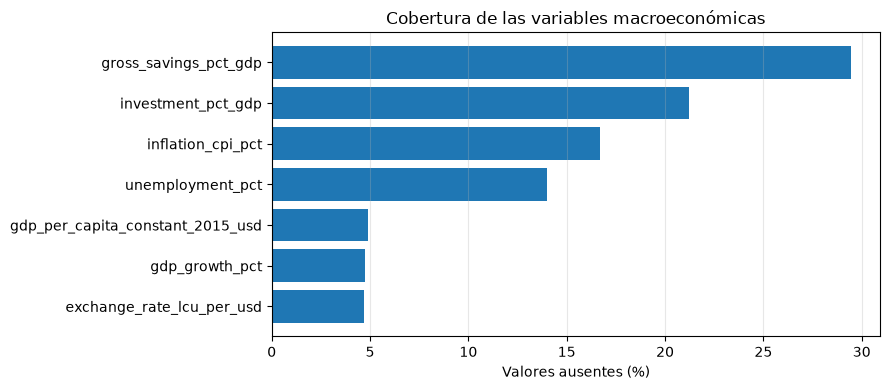

In [57]:
missing_pct = (
    df_macro[macro_variables]
    .isna()
    .mean()
    .mul(100)
    .sort_values()
)

plt.figure(figsize=(9, 4))

plt.barh(
    missing_pct.index,
    missing_pct.values
)

plt.xlabel("Valores ausentes (%)")
plt.title("Cobertura de las variables macroeconómicas")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## Segunda fase: Variables fiscales

El segundo bloque recoge la situación de las finanzas públicas de cada país. Se incorporan la deuda pública, el saldo presupuestario, los ingresos y gastos públicos y el saldo primario, expresados como porcentaje del PIB.

A partir del saldo fiscal y del saldo primario se calcula también la carga de intereses de la deuda. Los datos proceden del Fiscal Monitor del Fondo Monetario Internacional y se descargan para el periodo 2000-2024.

In [65]:
datos_fmi = {
    "Variable": [
        "Deuda pública",
        "Saldo fiscal",
        "Saldo primario",
        "Ingresos públicos",
        "Gasto público"
    ],
    "Código FMI": [
        "G_XWDG_G01_GDP_PT",
        "GGXCNL_G01_GDP_PT",
        "GGXONLB_G01_GDP_PT",
        "GGR_G01_GDP_PT",
        "G_X_G01_GDP_PT"
    ],
    "Medida": [
        "Deuda bruta del gobierno general, % del PIB",
        "Déficit o superávit del gobierno general, % del PIB",
        "Saldo fiscal excluyendo los intereses netos, % del PIB",
        "Ingresos del gobierno general, % del PIB",
        "Gasto total del gobierno general, % del PIB"
    ]
}

variables_fmi_df = pd.DataFrame(datos_fmi)

tabla_fmi = (
    variables_fmi_df.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "left",
        "vertical-align": "middle",
        "white-space": "normal",
        "overflow-wrap": "break-word",
        "padding": "10px",
        "border": "1px solid #dddddd",
        "font-size": "10px"
    })
    .set_properties(
        subset=["Variable"],
        **{
            "background-color": "#d9eaf4",
            "font-weight": "bold",
            "width": "30%"
        }
    )
    .set_properties(
        subset=["Código FMI"],
        **{
            "font-family": "monospace",
            "width": "28%"
        }
    )
    .set_properties(
        subset=["Medida"],
        **{
            "width": "42%"
        }
    )
    .set_table_styles([
        {
            "selector": "table",
            "props": [
                ("width", "100%"),
                ("table-layout", "fixed"),
                ("border-collapse", "collapse")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#d9eaf4"),
                ("text-align", "left"),
                ("font-weight", "bold"),
                ("padding", "10px"),
                ("border", "1px solid #dddddd"),
                ("font-size", "10px")
            ]
        },
        {
            "selector": "tbody tr:nth-child(even) td:not(:first-child)",
            "props": [
                ("background-color", "#f5f5f5")
            ]
        }
    ])
)

display(tabla_fmi)

Variable,Código FMI,Medida
Deuda pública,G_XWDG_G01_GDP_PT,"Deuda bruta del gobierno general, % del PIB"
Saldo fiscal,GGXCNL_G01_GDP_PT,"Déficit o superávit del gobierno general, % del PIB"
Saldo primario,GGXONLB_G01_GDP_PT,"Saldo fiscal excluyendo los intereses netos, % del PIB"
Ingresos públicos,GGR_G01_GDP_PT,"Ingresos del gobierno general, % del PIB"
Gasto público,G_X_G01_GDP_PT,"Gasto total del gobierno general, % del PIB"


In [41]:
FISCAL_INDICATORS = {
    "G_XWDG_G01_GDP_PT": "government_debt_pct_gdp",
    "GGXCNL_G01_GDP_PT": "fiscal_balance_pct_gdp",
    "GGXONLB_G01_GDP_PT": "primary_balance_pct_gdp",
    "GGR_G01_GDP_PT": "government_revenue_pct_gdp",
    "G_X_G01_GDP_PT": "government_expenditure_pct_gdp"}

FISCAL_INDICATORS

{'G_XWDG_G01_GDP_PT': 'government_debt_pct_gdp',
 'GGXCNL_G01_GDP_PT': 'fiscal_balance_pct_gdp',
 'GGXONLB_G01_GDP_PT': 'primary_balance_pct_gdp',
 'GGR_G01_GDP_PT': 'government_revenue_pct_gdp',
 'G_X_G01_GDP_PT': 'government_expenditure_pct_gdp'}

In [36]:
# Funcion de descarga
IMF_BASE_URL = (
    "https://www.imf.org/external/datamapper/api/v2"
)

def download_imf_indicator(
    indicator_code,
    variable_name,
    start_year=START_YEAR,
    end_year=END_YEAR
):
    """
    Descarga un indicador del FMI para todos los países
    y lo devuelve en formato largo.
    """
    years = ",".join(
        str(year)
        for year in range(start_year, end_year + 1)
    )
    url = f"{IMF_BASE_URL}/{indicator_code}"

    payload = get_json(
        url,
        params={"periods": years}
    )
    indicator_values = (
        payload
        .get("values", {})
        .get(indicator_code, {})
    )

    rows = []

    for iso3, yearly_values in indicator_values.items():

        if not isinstance(yearly_values, dict):
            continue

        for year, value in yearly_values.items():

            rows.append({
                "iso3": iso3,
                "year": year,
                "indicator_code": indicator_code,
                "variable": variable_name,
                "value": value
            })

    data = pd.DataFrame(rows)

    if data.empty:
        print(f"Sin datos para {indicator_code}")
        return data

    data["year"] = pd.to_numeric(
        data["year"],
        errors="coerce"
    ).astype("Int64")

    data["value"] = pd.to_numeric(
        data["value"],
        errors="coerce"
    )

    return data

In [42]:
# descarga de variables
fiscal_downloads = []

for indicator_code, variable_name in FISCAL_INDICATORS.items():

    print(
        f"Descargando {variable_name} "
        f"({indicator_code})..."
    )

    indicator_data = download_imf_indicator(
        indicator_code=indicator_code,
        variable_name=variable_name
    )

    fiscal_downloads.append(indicator_data)


imf_fiscal_long = pd.concat(
    fiscal_downloads,
    ignore_index=True
)

Descargando government_debt_pct_gdp (G_XWDG_G01_GDP_PT)...
Descargando fiscal_balance_pct_gdp (GGXCNL_G01_GDP_PT)...
Descargando primary_balance_pct_gdp (GGXONLB_G01_GDP_PT)...
Descargando government_revenue_pct_gdp (GGR_G01_GDP_PT)...
Descargando government_expenditure_pct_gdp (G_X_G01_GDP_PT)...


In [66]:
# homogenización codigos
IMF_ISO_REPLACEMENTS = {
    "UVK": "XKX",
    "KOS": "XKX"
}

imf_fiscal_long["iso3"] = (
    imf_fiscal_long["iso3"]
    .replace(IMF_ISO_REPLACEMENTS)
)

imf_fiscal_long = imf_fiscal_long[
    imf_fiscal_long["iso3"].isin(countries["iso3"])
].copy()

imf_fiscal_long = imf_fiscal_long.sort_values(
    ["iso3", "year", "variable"]
).reset_index(drop=True)

display(imf_fiscal_long.head())

,iso3,year,indicator_code,variable,value
0,ABW,1995,GGXCNL_G01_GDP_PT,fiscal_balance_pct_gdp,-0.833617
1,ABW,1995,G_XWDG_G01_GDP_PT,government_debt_pct_gdp,55.095211
2,ABW,1995,G_X_G01_GDP_PT,government_expenditure_pct_gdp,26.331776
3,ABW,1995,GGR_G01_GDP_PT,government_revenue_pct_gdp,25.498160
4,ABW,1995,GGXONLB_G01_GDP_PT,primary_balance_pct_gdp,0.339121


In [67]:
imf_fiscal_values = (
    imf_fiscal_long
    .pivot_table(
        index=["iso3", "year"],
        columns="variable",
        values="value",
        aggfunc="first"
    )
    .reset_index()
)

imf_fiscal_values.columns.name = None


imf_fiscal_panel = country_year_grid.merge(
    imf_fiscal_values,
    on=["iso3", "year"],
    how="left"
)

imf_fiscal_panel = imf_fiscal_panel.sort_values(
    ["iso3", "year"]
).reset_index(drop=True)

print("Dimensiones:", imf_fiscal_panel.shape)

display(imf_fiscal_panel.head())

Dimensiones: (5425, 11)


,iso3,iso2,country,region,income_level,year,fiscal_balance_pct_gdp,government_debt_pct_gdp,government_expenditure_pct_gdp,government_revenue_pct_gdp,primary_balance_pct_gdp
0,ABW,AW,Aruba,Latin America & Caribbean,High income,2000,0.644936,38.613316,21.605565,22.250501,1.884842
1,ABW,AW,Aruba,Latin America & Caribbean,High income,2001,-0.835328,44.325613,22.508321,21.672993,0.553913
2,ABW,AW,Aruba,Latin America & Caribbean,High income,2002,-3.168732,47.078650,24.659862,21.491130,-1.757165
3,ABW,AW,Aruba,Latin America & Caribbean,High income,2003,1.896117,40.848111,25.135690,27.031807,3.143192
4,ABW,AW,Aruba,Latin America & Caribbean,High income,2004,-8.530898,42.543007,29.244513,20.713615,-6.403721


Se crea la variable "pagos netos de intereses sobre el PIB" -> `net_interest_payments_pct_gdp` como la diferencia entre el saldo primario y el saldo fiscal

In [70]:
imf_fiscal_panel["net_interest_payments_pct_gdp"] = (
    imf_fiscal_panel["primary_balance_pct_gdp"]
    - imf_fiscal_panel["fiscal_balance_pct_gdp"]
)

In [72]:
period_label = f"{START_YEAR}_{END_YEAR}"

imf_fiscal_long.to_csv(
    RAW_PATH / f"imf_fiscal_long_{period_label}.csv",
    index=False,
    encoding="utf-8-sig"
)

imf_fiscal_panel.to_csv(
    PROCESSED_PATH / f"imf_fiscal_panel_{period_label}.csv",
    index=False,
    encoding="utf-8-sig"
)

fiscal_coverage = summary_fiscal[
    [
        "count",
        "missing_values",
        "missing_pct"
    ]
].copy()

fiscal_coverage.to_csv(
    PROCESSED_PATH / f"imf_fiscal_coverage_{period_label}.csv",
    encoding="utf-8-sig"
)

print("Archivos fiscales guardados correctamente.")

Archivos fiscales guardados correctamente.


## Análisis descriptivo preliminar VARIABLES FISCALES

En este segundo bloque se realiza una revisión preliminar de las variables fiscales con el objetivo de comprobar la calidad, disponibilidad y cobertura de los datos descargados. Se revisan las dimensiones de la base, el número de países y años incluidos, la presencia de valores ausentes y la existencia de posibles duplicados.

Las variables fiscales permiten evaluar la capacidad del sector público para obtener ingresos, financiar sus gastos y hacer frente a sus obligaciones. El análisis descriptivo completo y las posibles transformaciones se realizarán una vez integrados todos los bloques de información.

### 1.- DEUDA BRUTA DEL GOBIERNO GENERAL
> `"G_XWDG_G01_GDP_PT": "general_government_debt_pct_gdp"`

Representa la deuda bruta del conjunto de las administraciones públicas como porcentaje del PIB. Incluye el endeudamiento del gobierno central y, cuando la cobertura estadística lo permite, el de las administraciones regionales, locales y los fondos de la Seguridad Social.

Mide la carga de deuda pública en relación con el tamaño de la economía y la capacidad potencial del país para hacer frente a sus obligaciones.

                     Mayor deuda pública ⇒ Mayor riesgo país
Sin embargo, la deuda debe interpretarse conjuntamente con el crecimiento económico, los tipos de interés, el saldo fiscal y la moneda en la que está denominada.

Variables derivadas que podrán estudiarse posteriormente:
- `government_debt_change`
- `government_debt_3y_change`

El cambio de la deuda se calculará en puntos porcentuales, ya que la variable original está expresada como porcentaje del PIB.

### 2.- SALDO FISCAL
> `"GGXCNL_G01_GDP_PT": "fiscal_balance_pct_gdp"`

Representa la diferencia entre los ingresos y el gasto total del gobierno general, incluyendo los pagos de intereses, como porcentaje del PIB.

Un valor positivo indica superávit fiscal, mientras que un valor negativo indica déficit. Los déficits elevados y persistentes pueden incrementar las necesidades de financiación y provocar un aumento de la deuda pública.

              Mayor saldo fiscal ⇒ Menor riesgo país
Variables derivadas que podrán estudiarse posteriormente:
- `fiscal_balance_3y_mean`
- `fiscal_deficit_dummy`
- `persistent_deficit_dummy`

### 3.- SALDO PRIMARIO
> `"GGXONLB_G01_GDP_PT": "primary_balance_pct_gdp"`

Representa la diferencia entre los ingresos y los gastos públicos excluyendo los pagos netos de intereses, como porcentaje del PIB.

Permite analizar la posición fiscal generada por las decisiones actuales de ingresos y gastos sin que el resultado esté condicionado directamente por el coste de la deuda acumulada en años anteriores.

              Mayor saldo primario ⇒ Menor riesgo país
Un superávit primario indica que los ingresos son suficientes para cubrir los gastos distintos de los intereses. Un déficit primario persistente puede dificultar la estabilización de la deuda pública.

Variables derivadas que podrán estudiarse posteriormente:
- `primary_balance_3y_mean`
- `primary_deficit_dummy`

### 4.- INGRESOS PÚBLICOS
> `"GGR_G01_GDP_PT": "government_revenue_pct_gdp"`

Representa los ingresos del gobierno general como porcentaje del PIB. Incluye los recursos obtenidos mediante impuestos, cotizaciones sociales y otras fuentes de ingresos públicos.

Mide la capacidad recaudatoria del Estado y los recursos disponibles para financiar el gasto público y atender sus obligaciones.

La relación con el riesgo país no es completamente directa. Un nivel reducido de ingresos puede reflejar una baja capacidad fiscal, mientras que unos ingresos elevados no implican necesariamente un menor riesgo si van acompañados de un gasto todavía mayor.

Variables derivadas que podrán estudiarse posteriormente:
- `government_revenue_change`
- `government_revenue_3y_mean`

### 5.- GASTO PÚBLICO
> `"G_X_G01_GDP_PT": "government_expenditure_pct_gdp"`

Representa el gasto total del gobierno general como porcentaje del PIB. Incluye el gasto corriente, las prestaciones sociales, la inversión pública y los pagos de intereses.

Mide el tamaño de la intervención pública en relación con la economía. Un gasto elevado puede provocar déficits y acumulación de deuda cuando no está respaldado por ingresos suficientes.

Sin embargo, no puede establecerse automáticamente que un mayor gasto implique un mayor riesgo país, ya que también puede reflejar mejores servicios públicos, inversión productiva o medidas temporales adoptadas durante una crisis.

Variables derivadas que podrán estudiarse posteriormente:
- `government_expenditure_change`
- `government_expenditure_3y_mean`

### 6.- PAGOS NETOS DE INTERESES
> `"net_interest_payments_pct_gdp"`

Los pagos netos de intereses se calculan como la diferencia entre el saldo primario y el saldo fiscal:

`net_interest_payments_pct_gdp = primary_balance_pct_gdp - fiscal_balance_pct_gdp`
Representan la carga que supone el pago neto de intereses de la deuda pública como porcentaje del PIB.

Una carga de intereses elevada reduce los recursos disponibles para financiar otras políticas públicas y puede aumentar las necesidades de financiación del Estado.

              Mayores pagos de intereses ⇒ Mayor riesgo país
Esta variable se incorpora directamente en el bloque fiscal porque procede de una identidad contable entre dos indicadores originales. No debe confundirse con el servicio total de la deuda, que también puede incluir la devolución del principal.

In [84]:
df_fiscal = imf_fiscal_panel.copy()

fiscal_variables = [
    "government_debt_pct_gdp",
    "fiscal_balance_pct_gdp",
    "primary_balance_pct_gdp",
    "government_revenue_pct_gdp",
    "government_expenditure_pct_gdp",
    "net_interest_payments_pct_gdp"
]
print("Dimensiones:", df_fiscal.shape)
print(
    "Número de países:",
    df_fiscal["iso3"].nunique()
)

print(
    "Periodo:",
    df_fiscal["year"].min(),
    "-",
    df_fiscal["year"].max()
)

print(
    "Duplicados país-año:",
    df_fiscal.duplicated(
        ["iso3", "year"]
    ).sum()
)

Dimensiones: (5425, 12)
Número de países: 217
Periodo: 2000 - 2024
Duplicados país-año: 0


In [83]:
summary_fiscal = (
    imf_fiscal_panel[fiscal_variables]
    .describe(percentiles=[0.25, 0.50, 0.75])
    .T
)

summary_fiscal["missing_values"] = (
    imf_fiscal_panel[fiscal_variables]
    .isna()
    .sum()
)

summary_fiscal["missing_pct"] = (
    imf_fiscal_panel[fiscal_variables]
    .isna()
    .mean()
    .mul(100)
)

summary_fiscal = summary_fiscal[
    [
        "count",
        "missing_values",
        "missing_pct",
        "mean",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max"
    ]
].round(2)

display(summary_fiscal)

,count,missing_values,missing_pct,mean,std,min,25%,50%,75%,max
government_debt_pct_gdp,4633.0,792,14.60,55.13,44.55,0.00,28.68,45.69,69.17,600.11
fiscal_balance_pct_gdp,4714.0,711,13.11,-1.92,6.78,-55.75,-4.53,-2.31,-0.01,125.14
primary_balance_pct_gdp,4583.0,842,15.52,-0.48,6.23,-55.75,-2.75,-0.75,1.39,126.46
government_revenue_pct_gdp,4739.0,686,12.65,29.06,15.88,0.64,18.27,25.83,37.05,164.05
government_expenditure_pct_gdp,4714.0,711,13.11,31.05,15.03,2.49,20.54,28.58,38.77,145.87
net_interest_payments_pct_gdp,4583.0,842,15.52,1.59,2.18,-24.89,0.50,1.25,2.38,16.88


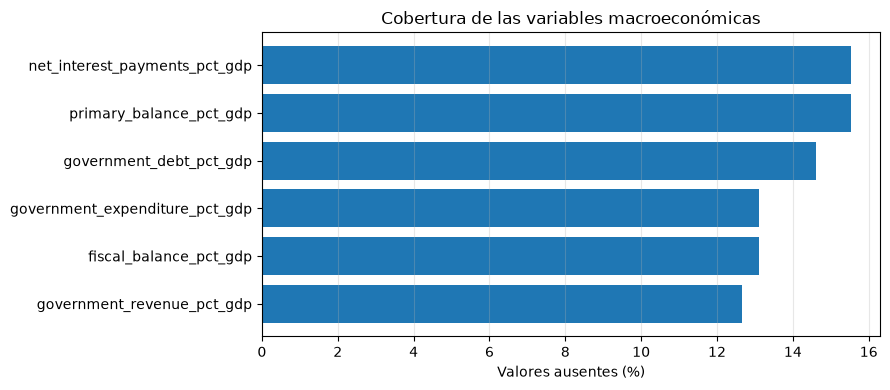

In [75]:
missing_pct = (
    imf_fiscal_panel[fiscal_variables]
    .isna()
    .mean()
    .mul(100)
    .sort_values()
)

plt.figure(figsize=(9, 4))

plt.barh(
    missing_pct.index,
    missing_pct.values
)

plt.xlabel("Valores ausentes (%)")
plt.title("Cobertura de las variables macroeconómicas")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## Tercera fase: Variables externas

El tercer bloque recoge la posición económica y financiera de cada país frente al resto del mundo. Se incorporan el saldo de la cuenta corriente, la deuda externa, el servicio de la deuda, la deuda externa a corto plazo, las exportaciones e importaciones, las reservas internacionales y la inversión extranjera directa.

Estas variables permiten analizar la dependencia de la financiación exterior, la capacidad del país para generar divisas, la proximidad de sus obligaciones internacionales y los recursos disponibles para responder ante salidas de capital o dificultades de refinanciación.

Los datos proceden de los Indicadores de Desarrollo Mundial y de las Estadísticas Internacionales de Deuda del Banco Mundial, y se descargan para el periodo 2000-2024. A partir de las exportaciones e importaciones sobre el PIB se calculará también el grado de apertura comercial.

In [149]:
datos_externos = {
    "Variable": [
        "Saldo de la cuenta corriente",
        "Deuda externa total",
        "Deuda externa relativa",
        "Servicio de la deuda externa",
        "Deuda externa a corto plazo",
        "Crecimiento de las exportaciones",
        "Exportaciones",
        "Importaciones",
        "Reservas sobre deuda externa",
        "Reservas en meses de importaciones",
        "Inversión extranjera directa"
    ],
    "Código WDI": [
        "BN.CAB.XOKA.GD.ZS",
        "DT.DOD.DECT.CD",
        "DT.DOD.DECT.GN.ZS",
        "DT.TDS.DECT.EX.ZS",
        "DT.DOD.DSTC.IR.ZS",
        "NE.EXP.GNFS.KD.ZG",
        "NE.EXP.GNFS.ZS",
        "NE.IMP.GNFS.ZS",
        "FI.RES.TOTL.DT.ZS",
        "FI.RES.TOTL.MO",
        "BX.KLT.DINV.WD.GD.ZS"
    ],
    "Medida": [
        "% del PIB",
        "USD corrientes",
        "% de la renta nacional bruta",
        "% de las exportaciones de bienes, servicios e ingresos primarios",
        "% de las reservas internacionales",
        "% de crecimiento anual real",
        "% del PIB",
        "% del PIB",
        "% de la deuda externa total",
        "Número de meses de importaciones",
        "Entradas netas, % del PIB"
    ]
}

variables_externas_df = pd.DataFrame(datos_externos)

tabla_externas = (
    variables_externas_df.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "left",
        "vertical-align": "middle",
        "white-space": "normal",
        "overflow-wrap": "break-word",
        "padding": "10px",
        "border": "1px solid #dddddd",
        "font-size": "10px"
    })
    .set_properties(
        subset=["Variable"],
        **{
            "background-color": "#d9eaf4",
            "font-weight": "bold",
            "width": "32%"
        }
    )
    .set_properties(
        subset=["Código WDI"],
        **{
            "font-family": "monospace",
            "width": "25%"
        }
    )
    .set_properties(
        subset=["Medida"],
        **{
            "width": "43%"
        }
    )
    .set_table_styles([
        {
            "selector": "table",
            "props": [
                ("width", "100%"),
                ("table-layout", "fixed"),
                ("border-collapse", "collapse")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#d9eaf4"),
                ("text-align", "left"),
                ("font-weight", "bold"),
                ("padding", "10px"),
                ("border", "1px solid #dddddd"),
                ("font-size", "10px")
            ]
        },
        {
            "selector": "tbody tr:nth-child(even) td:not(:first-child)",
            "props": [
                ("background-color", "#f5f5f5")
            ]
        }
    ])
)

display(tabla_externas)

Variable,Código WDI,Medida
Saldo de la cuenta corriente,BN.CAB.XOKA.GD.ZS,% del PIB
Deuda externa total,DT.DOD.DECT.CD,USD corrientes
Deuda externa relativa,DT.DOD.DECT.GN.ZS,% de la renta nacional bruta
Servicio de la deuda externa,DT.TDS.DECT.EX.ZS,"% de las exportaciones de bienes, servicios e ingresos primarios"
Deuda externa a corto plazo,DT.DOD.DSTC.IR.ZS,% de las reservas internacionales
Crecimiento de las exportaciones,NE.EXP.GNFS.KD.ZG,% de crecimiento anual real
Exportaciones,NE.EXP.GNFS.ZS,% del PIB
Importaciones,NE.IMP.GNFS.ZS,% del PIB
Reservas sobre deuda externa,FI.RES.TOTL.DT.ZS,% de la deuda externa total
Reservas en meses de importaciones,FI.RES.TOTL.MO,Número de meses de importaciones


In [150]:
EXTERNAL_INDICATORS = {
    "BN.CAB.XOKA.GD.ZS": "current_account_balance_pct_gdp",
    "DT.DOD.DECT.CD": "external_debt_stocks_current_usd",
    "DT.DOD.DECT.GN.ZS": "external_debt_pct_gni",
    "DT.TDS.DECT.EX.ZS": "external_debt_service_pct_exports",
    "DT.DOD.DSTC.IR.ZS": "short_term_debt_pct_reserves",
    "NE.EXP.GNFS.KD.ZG": "exports_growth_pct",
    "NE.EXP.GNFS.ZS": "exports_pct_gdp",
    "NE.IMP.GNFS.ZS": "imports_pct_gdp",
    "FI.RES.TOTL.DT.ZS": "reserves_pct_external_debt",
    "FI.RES.TOTL.MO": "reserves_months_imports",
    "BX.KLT.DINV.WD.GD.ZS": "fdi_net_inflows_pct_gdp"
}

EXTERNAL_INDICATORS

{'BN.CAB.XOKA.GD.ZS': 'current_account_balance_pct_gdp',
 'DT.DOD.DECT.CD': 'external_debt_stocks_current_usd',
 'DT.DOD.DECT.GN.ZS': 'external_debt_pct_gni',
 'DT.TDS.DECT.EX.ZS': 'external_debt_service_pct_exports',
 'DT.DOD.DSTC.IR.ZS': 'short_term_debt_pct_reserves',
 'NE.EXP.GNFS.KD.ZG': 'exports_growth_pct',
 'NE.EXP.GNFS.ZS': 'exports_pct_gdp',
 'NE.IMP.GNFS.ZS': 'imports_pct_gdp',
 'FI.RES.TOTL.DT.ZS': 'reserves_pct_external_debt',
 'FI.RES.TOTL.MO': 'reserves_months_imports',
 'BX.KLT.DINV.WD.GD.ZS': 'fdi_net_inflows_pct_gdp'}

Como todas estas variables proceden del Banco Mundial, reutilizamos las funciones que ya creamos:

    get_json()
    download_indicator()

In [151]:
external_downloads = []

for indicator_code, variable_name in EXTERNAL_INDICATORS.items():

    print(
        f"Descargando {variable_name} "
        f"({indicator_code})..."
    )

    indicator_data = download_indicator(
        indicator_code=indicator_code,
        variable_name=variable_name
    )

    external_downloads.append(indicator_data)


# Base en formato largo
wdi_external_long = pd.concat(
    external_downloads,
    ignore_index=True
)

# Conservamos únicamente países y eliminamos agregados
wdi_external_long = wdi_external_long[
    wdi_external_long["iso3"].isin(countries["iso3"])
].copy()

wdi_external_long = wdi_external_long.sort_values(
    ["iso3", "year", "variable"]
).reset_index(drop=True)

display(wdi_external_long.head())

Descargando current_account_balance_pct_gdp (BN.CAB.XOKA.GD.ZS)...
Descargando external_debt_stocks_current_usd (DT.DOD.DECT.CD)...
Descargando external_debt_pct_gni (DT.DOD.DECT.GN.ZS)...
Descargando external_debt_service_pct_exports (DT.TDS.DECT.EX.ZS)...
Descargando short_term_debt_pct_reserves (DT.DOD.DSTC.IR.ZS)...
Descargando exports_growth_pct (NE.EXP.GNFS.KD.ZG)...
Descargando exports_pct_gdp (NE.EXP.GNFS.ZS)...
Descargando imports_pct_gdp (NE.IMP.GNFS.ZS)...
Descargando reserves_pct_external_debt (FI.RES.TOTL.DT.ZS)...
Descargando reserves_months_imports (FI.RES.TOTL.MO)...
Descargando fdi_net_inflows_pct_gdp (BX.KLT.DINV.WD.GD.ZS)...


,iso3,year,indicator_code,variable,value
0,ABW,2000,BN.CAB.XOKA.GD.ZS,current_account_balance_pct_gdp,11.056872
1,ABW,2000,NE.EXP.GNFS.KD.ZG,exports_growth_pct,NaN
2,ABW,2000,NE.EXP.GNFS.ZS,exports_pct_gdp,74.386011
3,ABW,2000,DT.DOD.DECT.GN.ZS,external_debt_pct_gni,NaN
4,ABW,2000,DT.TDS.DECT.EX.ZS,external_debt_service_pct_exports,NaN


In [153]:
wdi_external_long = (
    wdi_external_long[
        wdi_external_long["iso3"].isin(
            countries["iso3"]
        )
    ]
    .copy()
)

wdi_external_long = (
    wdi_external_long
    .sort_values(
        ["iso3", "year", "variable"]
    )
    .reset_index(drop=True)
)

print(
    "Observaciones descargadas:",
    len(wdi_external_long)
)

print(
    "Número de países:",
    wdi_external_long["iso3"].nunique()
)

display(wdi_external_long.head())

Observaciones descargadas: 59675
Número de países: 217


,iso3,year,indicator_code,variable,value
0,ABW,2000,BN.CAB.XOKA.GD.ZS,current_account_balance_pct_gdp,11.056872
1,ABW,2000,NE.EXP.GNFS.KD.ZG,exports_growth_pct,NaN
2,ABW,2000,NE.EXP.GNFS.ZS,exports_pct_gdp,74.386011
3,ABW,2000,DT.DOD.DECT.GN.ZS,external_debt_pct_gni,NaN
4,ABW,2000,DT.TDS.DECT.EX.ZS,external_debt_service_pct_exports,NaN


In [154]:
external_download_check = (
    wdi_external_long
    .groupby(
        ["indicator_code", "variable"],
        as_index=False
    )
    .agg(
        observations=("value", "count"),
        countries=("iso3", "nunique"),
        first_year=("year", "min"),
        last_year=("year", "max")
    )
    .sort_values("observations", ascending=False)
    .reset_index(drop=True)
)

display(external_download_check)

,indicator_code,variable,observations,countries,first_year,last_year
0,BX.KLT.DINV.WD.GD.ZS,fdi_net_inflows_pct_gdp,4819,217,2000,2024
1,NE.IMP.GNFS.ZS,imports_pct_gdp,4450,217,2000,2024
2,NE.EXP.GNFS.ZS,exports_pct_gdp,4450,217,2000,2024
3,BN.CAB.XOKA.GD.ZS,current_account_balance_pct_gdp,4415,217,2000,2024
4,FI.RES.TOTL.MO,reserves_months_imports,4002,217,2000,2024
5,NE.EXP.GNFS.KD.ZG,exports_growth_pct,3998,217,2000,2024
6,DT.DOD.DECT.CD,external_debt_stocks_current_usd,2958,217,2000,2024
7,DT.DOD.DECT.GN.ZS,external_debt_pct_gni,2916,217,2000,2024
8,DT.TDS.DECT.EX.ZS,external_debt_service_pct_exports,2748,217,2000,2024
9,FI.RES.TOTL.DT.ZS,reserves_pct_external_debt,2613,217,2000,2024


In [155]:
# Transformación de formato largo a formato ancho
wdi_external_values = (
    wdi_external_long
    .pivot_table(
        index=["iso3", "year"],
        columns="variable",
        values="value",
        aggfunc="first"
    )
    .reset_index()
)

wdi_external_values.columns.name = None


# Unión con todas las combinaciones de país y año
wdi_external_panel = country_year_grid.merge(
    wdi_external_values,
    on=["iso3", "year"],
    how="left"
)

wdi_external_panel = wdi_external_panel.sort_values(
    ["iso3", "year"]
).reset_index(drop=True)

print(
    "Dimensiones del panel externo:",
    wdi_external_panel.shape
)

display(wdi_external_panel.head())

Dimensiones del panel externo: (5425, 17)


,iso3,iso2,country,region,income_level,year,current_account_balance_pct_gdp,exports_growth_pct,exports_pct_gdp,external_debt_pct_gni,external_debt_service_pct_exports,external_debt_stocks_current_usd,fdi_net_inflows_pct_gdp,imports_pct_gdp,reserves_months_imports,reserves_pct_external_debt,short_term_debt_pct_reserves
0,ABW,AW,Aruba,Latin America & Caribbean,High income,2000,11.056872,NaN,74.386011,NaN,NaN,NaN,-6.828727,70.686869,1.785034,NaN,NaN
1,ABW,AW,Aruba,Latin America & Caribbean,High income,2001,16.280874,NaN,70.996784,NaN,NaN,NaN,-14.075056,69.394325,2.275344,NaN,NaN
2,ABW,AW,Aruba,Latin America & Caribbean,High income,2002,-17.343452,NaN,64.564314,NaN,NaN,NaN,16.949056,68.666458,2.558116,NaN,NaN
3,ABW,AW,Aruba,Latin America & Caribbean,High income,2003,-8.099023,NaN,62.731213,NaN,NaN,NaN,7.816429,70.063078,2.154841,NaN,NaN
4,ABW,AW,Aruba,Latin America & Caribbean,High income,2004,12.013685,NaN,64.665559,NaN,NaN,NaN,-4.687639,67.765371,0.937018,NaN,NaN


In [156]:
wdi_external_panel["trade_openness_pct_gdp"] = (
    wdi_external_panel["exports_pct_gdp"]
    + wdi_external_panel["imports_pct_gdp"]
)

La apertura comercial se calcula como la suma de las exportaciones y las importaciones de bienes y servicios, ambas expresadas como porcentaje del PIB. El indicador aproxima el grado de integración de la economía en los mercados internacionales.

`trade_openness_pct_gdp = exports_pct_gdp + imports_pct_gdp`

## Análisis descriptivo preliminar VARIABLES EXTERNAS

En este tercer bloque se realiza una revisión preliminar de las variables externas con el objetivo de comprobar la calidad, disponibilidad y cobertura de los datos descargados. Se revisan las dimensiones de la base, el número de países y años incluidos, la presencia de valores ausentes y la existencia de posibles duplicados.

Las variables externas permiten evaluar la capacidad de un país para generar recursos procedentes del exterior, atender sus obligaciones internacionales y hacer frente a posibles salidas de capital o perturbaciones financieras.

El análisis descriptivo completo y las transformaciones de las variables se realizarán una vez integrados todos los bloques de información.

### 1.- SALDO DE LA CUENTA CORRIENTE

> `"BN.CAB.XOKA.GD.ZS": "current_account_balance_pct_gdp"`

Representa el saldo de la cuenta corriente como porcentaje del PIB. Recoge la diferencia entre los ingresos y pagos procedentes del comercio de bienes y servicios, las rentas y las transferencias corrientes entre el país y el resto del mundo.

Un valor positivo indica un superávit por cuenta corriente, mientras que un valor negativo indica un déficit y, por tanto, una necesidad de financiación exterior.

              Mayor saldo de la cuenta corriente ⇒ Menor riesgo país

No obstante, un déficit puntual no implica necesariamente una situación de riesgo. Su efecto dependerá de su persistencia, de la forma en que se financie y de la capacidad futura del país para generar ingresos externos.

Variables derivadas que podrán estudiarse posteriormente:

- `current_account_3y_mean`
- `current_account_deficit_dummy`
- `persistent_current_account_deficit`

### 2.- DEUDA EXTERNA ACUMULADA

> `"DT.DOD.DECT.CD": "external_debt_stocks_current_usd"`

Representa el volumen total de deuda externa pendiente de pago, expresado en dólares corrientes. Incluye las obligaciones contraídas frente a acreedores no residentes.

Mide la exposición del país frente a la financiación internacional y la magnitud de los compromisos que deben atenderse mediante recursos o divisas procedentes del exterior.

                    Mayor deuda externa ⇒ Mayor riesgo país

Sin embargo, el nivel absoluto de deuda externa no es directamente comparable entre países de distinto tamaño. Una economía grande puede mantener un volumen elevado de deuda externa sin presentar necesariamente una mayor vulnerabilidad.

Por este motivo, posteriormente se estudiarán transformaciones como:

- `log_external_debt`
- `external_debt_growth`
- deuda externa en relación con el PIB
- deuda externa en relación con las exportaciones

### 3.- CRECIMIENTO DE LAS EXPORTACIONES

> `"NE.EXP.GNFS.KD.ZG": "exports_growth_pct"`

Representa la tasa anual de crecimiento real de las exportaciones de bienes y servicios. Al calcularse a precios constantes, refleja la variación del volumen exportado reduciendo el efecto de los cambios en los precios.

Mide la capacidad del país para vender bienes y servicios en los mercados internacionales, obtener divisas y generar recursos con los que atender sus obligaciones exteriores.

              Mayor crecimiento de las exportaciones ⇒ Menor riesgo país

Una caída prolongada de las exportaciones puede reducir la entrada de divisas, deteriorar la cuenta corriente y aumentar la vulnerabilidad frente a la deuda externa.

Sin embargo, también debe analizarse la estabilidad del crecimiento, ya que una elevada volatilidad puede indicar una fuerte dependencia de materias primas o de determinados mercados exteriores.

Variables derivadas que podrán estudiarse posteriormente:

- `exports_growth_3y_mean`
- `exports_growth_3y_std`
- `exports_contraction_dummy`

### 4.- RESERVAS SOBRE DEUDA EXTERNA

> `"FI.RES.TOTL.DT.ZS": "reserves_pct_external_debt"`

Representa el volumen de reservas internacionales como porcentaje de la deuda externa total. Las reservas incluyen activos externos controlados por las autoridades monetarias y disponibles para cubrir necesidades de financiación exterior o intervenir en el mercado de divisas.

Mide la capacidad del país para responder ante salidas de capital, dificultades de financiación o problemas para refinanciar su deuda externa.

              Mayores reservas sobre deuda externa ⇒ Menor riesgo país

Un valor reducido puede indicar que el país dispone de un margen limitado para afrontar sus compromisos externos. Por el contrario, un nivel elevado de reservas proporciona una mayor protección frente a perturbaciones internacionales.

Posteriormente podrán estudiarse:

- `low_reserves_dummy`
- transformación logarítmica
- medias móviles
- tratamiento de valores extremadamente elevados

### 5.- DEUDA EXTERNA SOBRE LA RENTA NACIONAL BRUTA

> `"DT.DOD.DECT.GN.ZS": "external_debt_pct_gni"`

Representa el volumen total de deuda externa como porcentaje de la renta nacional bruta. A diferencia del valor absoluto de la deuda, esta variable permite considerar el tamaño económico y la capacidad de generación de renta del país.

Un valor elevado puede indicar una mayor dependencia de acreedores extranjeros y una mayor exposición a variaciones del tipo de cambio, aumentos de los tipos de interés o interrupciones de la financiación internacional.

              Mayor deuda externa relativa ⇒ Mayor riesgo país

Esta medida será previsiblemente más comparable entre países que el stock de deuda expresado en dólares corrientes.

### 6.- SERVICIO DE LA DEUDA EXTERNA

> `"DT.TDS.DECT.EX.ZS": "external_debt_service_pct_exports"`

Representa los pagos efectivos de principal e intereses de la deuda externa como porcentaje de las exportaciones de bienes, servicios e ingresos primarios.

Mide qué proporción de los ingresos externos debe destinarse a atender las obligaciones de deuda. Una carga elevada puede reducir las divisas disponibles para financiar importaciones, mantener reservas o responder ante perturbaciones económicas.

              Mayor servicio de la deuda ⇒ Mayor riesgo país

Esta variable aporta información sobre la presión financiera inmediata, mientras que el stock de deuda refleja el endeudamiento acumulado.

### 7.- DEUDA EXTERNA A CORTO PLAZO SOBRE RESERVAS

> `"DT.DOD.DSTC.IR.ZS": "short_term_debt_pct_reserves"`

Representa la deuda externa con vencimiento original igual o inferior a un año como porcentaje de las reservas internacionales.

Mide si las reservas disponibles son suficientes para cubrir las obligaciones externas más próximas. Un porcentaje elevado puede indicar una mayor vulnerabilidad ante salidas de capital, pérdida de acceso a los mercados o dificultades de refinanciación.

              Mayor deuda a corto plazo sobre reservas
                         ⇒ Mayor riesgo país

### 8.- EXPORTACIONES DE BIENES Y SERVICIOS

> `"NE.EXP.GNFS.ZS": "exports_pct_gdp"`

Representa el valor de las exportaciones de bienes y servicios como porcentaje del PIB.

Mide la importancia del sector exterior en la economía y su capacidad para generar ingresos y divisas. Un nivel elevado puede facilitar el pago de la deuda externa, aunque también puede reflejar una mayor exposición a perturbaciones internacionales.

La relación con el riesgo país puede ser ambigua y dependerá de la diversificación de los productos exportados y de los mercados de destino.

### 9.- IMPORTACIONES DE BIENES Y SERVICIOS

> `"NE.IMP.GNFS.ZS": "imports_pct_gdp"`

Representa el valor de las importaciones de bienes y servicios como porcentaje del PIB.

Mide la dependencia de bienes, servicios y suministros procedentes del exterior. Una elevada proporción de importaciones puede aumentar las necesidades de divisas, aunque también puede corresponder a economías abiertas e integradas en cadenas internacionales de producción.

Su interpretación se realizará conjuntamente con las exportaciones, la cuenta corriente y las reservas internacionales.

### 10.- RESERVAS EN MESES DE IMPORTACIONES

> `"FI.RES.TOTL.MO": "reserves_months_imports"`

Indica el número aproximado de meses de importaciones que podrían financiarse utilizando las reservas internacionales del país.

Mide el margen de liquidez exterior disponible para mantener las compras internacionales si se redujeran temporalmente las entradas de divisas o el acceso a financiación externa.

              Mayores reservas en meses de importaciones
                         ⇒ Menor riesgo país

Esta variable complementa las reservas sobre deuda externa: una compara las reservas con las necesidades comerciales y la otra con las obligaciones financieras.

### 11.- INVERSIÓN EXTRANJERA DIRECTA

> `"BX.KLT.DINV.WD.GD.ZS": "fdi_net_inflows_pct_gdp"`

Representa las entradas netas de inversión extranjera directa como porcentaje del PIB.

Mide los flujos de inversión procedentes del exterior destinados a adquirir una participación duradera o ejercer influencia sobre empresas residentes. Puede reflejar la confianza de los inversores internacionales, la capacidad de atraer capital y la integración del país en la economía mundial.

            Mayor inversión extranjera directa
                       ⇒ Menor riesgo país

Sin embargo, pueden aparecer valores negativos cuando las desinversiones o salidas superan las nuevas entradas. También pueden existir valores extraordinarios en economías pequeñas o centros financieros, por lo que posteriormente se estudiarán sus valores extremos.

### 12.- APERTURA COMERCIAL

> `"trade_openness_pct_gdp"`

Se calcula como la suma de las exportaciones y las importaciones de bienes y servicios, expresadas como porcentaje del PIB.

Mide el grado de integración del país en el comercio internacional. Una mayor apertura puede facilitar el acceso a mercados, tecnología y divisas, pero también puede incrementar la exposición a perturbaciones externas.

Por tanto, la relación con el riesgo país deberá determinarse empíricamente y puede variar según la estructura productiva y el grado de diversificación de cada economía.

In [157]:
period_label = f"{START_YEAR}_{END_YEAR}"

# Datos originales en formato largo
wdi_external_long.to_csv(
    RAW_PATH
    / f"wdi_external_long_{period_label}.csv",
    index=False,
    encoding="utf-8-sig"
)

# Panel país-año
wdi_external_panel.to_csv(
    PROCESSED_PATH
    / f"wdi_external_panel_{period_label}.csv",
    index=False,
    encoding="utf-8-sig"
)

# Resumen de cobertura
external_coverage = summary_external[
    [
        "count",
        "missing_values",
        "missing_pct"
    ]
].copy()

external_coverage.to_csv(
    PROCESSED_PATH
    / f"wdi_external_coverage_{period_label}.csv",
    encoding="utf-8-sig"
)

print(
    "Archivos de variables externas "
    "guardados correctamente."
)

Archivos de variables externas guardados correctamente.


In [158]:
df_external = wdi_external_panel.copy()

external_variables = [
    "current_account_balance_pct_gdp",
    "external_debt_stocks_current_usd",
    "external_debt_pct_gni",
    "external_debt_service_pct_exports",
    "short_term_debt_pct_reserves",
    "exports_growth_pct",
    "exports_pct_gdp",
    "imports_pct_gdp",
    "reserves_pct_external_debt",
    "reserves_months_imports",
    "fdi_net_inflows_pct_gdp",
    "trade_openness_pct_gdp"
]

print("Dimensiones:", df_external.shape)
print(
    "Número de países:",
    df_external["iso3"].nunique()
)

print(
    "Periodo:",
    df_external["year"].min(),
    "-",
    df_external["year"].max()
)

print(
    "Duplicados país-año:",
    df_external.duplicated(
        ["iso3", "year"]
    ).sum()
)

Dimensiones: (5425, 18)
Número de países: 217
Periodo: 2000 - 2024
Duplicados país-año: 0


In [159]:
summary_external = (
    wdi_external_panel[external_variables]
    .describe(percentiles=[0.25, 0.50, 0.75])
    .T
)

summary_external["missing_values"] = (
    wdi_external_panel[external_variables]
    .isna()
    .sum()
)

summary_external["missing_pct"] = (
    wdi_external_panel[external_variables]
    .isna()
    .mean()
    .mul(100)
)

summary_external = summary_external[
    [
        "count",
        "missing_values",
        "missing_pct",
        "mean",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max"
    ]
].round(2)

display(summary_external)

,count,missing_values,missing_pct,mean,std,min,25%,50%,75%,max
current_account_balance_pct_gdp,4415.0,1010,18.62,-2.070000e+00,1.424000e+01,-60.70,-7.260000e+00,-2.620000e+00,2.090000e+00,3.117500e+02
external_debt_stocks_current_usd,2958.0,2467,45.47,4.585208e+10,1.609987e+11,69583145.70,1.773353e+09,6.557270e+09,2.314757e+10,2.724354e+12
external_debt_pct_gni,2916.0,2509,46.25,5.515000e+01,4.896000e+01,1.15,2.665000e+01,4.326000e+01,6.851000e+01,6.104500e+02
external_debt_service_pct_exports,2748.0,2677,49.35,1.409000e+01,1.346000e+01,0.00,5.430000e+00,1.047000e+01,1.812000e+01,1.348000e+02
short_term_debt_pct_reserves,2613.0,2812,51.83,4.548300e+02,1.238393e+04,0.00,1.033000e+01,2.748000e+01,5.833000e+01,5.276468e+05
exports_growth_pct,3998.0,1427,26.30,5.840000e+00,2.630000e+01,-96.36,-1.010000e+00,4.420000e+00,1.042000e+01,1.045450e+03
exports_pct_gdp,4450.0,975,17.97,4.227000e+01,3.220000e+01,0.00,2.232000e+01,3.503000e+01,5.292000e+01,4.338400e+02
imports_pct_gdp,4450.0,975,17.97,4.802000e+01,2.943000e+01,0.00,2.888000e+01,4.139000e+01,6.016000e+01,4.293600e+02
reserves_pct_external_debt,2613.0,2812,51.83,7.249000e+01,2.212800e+02,0.01,1.983000e+01,3.405000e+01,5.819000e+01,3.839050e+03
reserves_months_imports,4002.0,1423,26.23,4.980000e+00,5.100000e+00,0.01,2.240000e+00,3.890000e+00,5.950000e+00,7.924000e+01


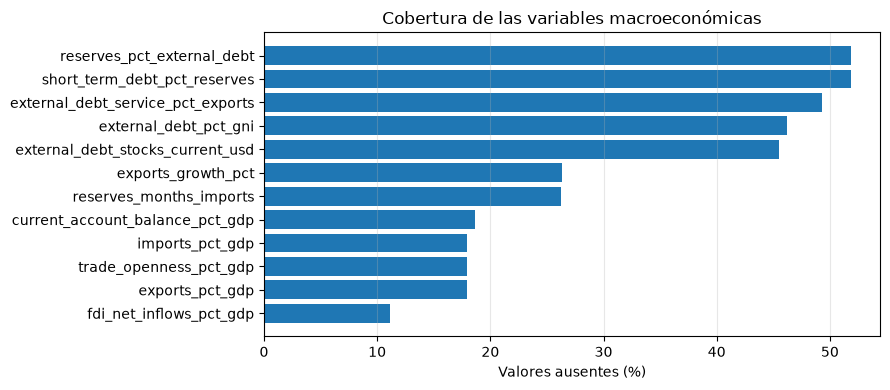

In [160]:
missing_pct = (
    wdi_external_panel[external_variables]
    .isna()
    .mean()
    .mul(100)
    .sort_values()
)

plt.figure(figsize=(9, 4))

plt.barh(
    missing_pct.index,
    missing_pct.values
)

plt.xlabel("Valores ausentes (%)")
plt.title("Cobertura de las variables macroeconómicas")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## Cuarta fase: Variables monetarias y financieras

El cuarto bloque recoge las condiciones de financiación de la economía y la estabilidad del sistema bancario de cada país. Se incorporan la tasa de interés real y la proporción de préstamos bancarios no productivos sobre el total de préstamos brutos.

La tasa de interés real permite aproximar el coste del crédito una vez descontado el efecto de la inflación, mientras que los préstamos no productivos reflejan la calidad de los activos bancarios y el riesgo de impago existente en el sistema financiero.

Los datos se obtienen mediante los Indicadores de Desarrollo Mundial del Banco Mundial. Las fuentes originales son las Estadísticas Financieras Internacionales y los Indicadores de Solidez Financiera del Fondo Monetario Internacional. Las variables se descargan para el periodo 2000-2024.

In [86]:
datos_monetarios_financieros = {
    "Variable": [
        "Tasa de interés real",
        "Préstamos bancarios no productivos"
    ],
    "Código WDI": [
        "FR.INR.RINR",
        "FB.AST.NPER.ZS"
    ],
    "Medida": [
        "% anual",
        "% del total de préstamos brutos"
    ]
}

variables_monetarias_financieras_df = pd.DataFrame(
    datos_monetarios_financieros
)

tabla_monetaria_financiera = (
    variables_monetarias_financieras_df.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "left",
        "vertical-align": "middle",
        "white-space": "normal",
        "overflow-wrap": "break-word",
        "padding": "10px",
        "border": "1px solid #dddddd",
        "font-size": "10px"
    })
    .set_properties(
        subset=["Variable"],
        **{
            "background-color": "#d9eaf4",
            "font-weight": "bold",
            "width": "35%"
        }
    )
    .set_properties(
        subset=["Código WDI"],
        **{
            "font-family": "monospace",
            "width": "25%"
        }
    )
    .set_properties(
        subset=["Medida"],
        **{
            "width": "40%"
        }
    )
    .set_table_styles([
        {
            "selector": "table",
            "props": [
                ("width", "100%"),
                ("table-layout", "fixed"),
                ("border-collapse", "collapse")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#d9eaf4"),
                ("text-align", "left"),
                ("font-weight", "bold"),
                ("padding", "10px"),
                ("border", "1px solid #dddddd"),
                ("font-size", "10px")
            ]
        },
        {
            "selector": "tbody tr:nth-child(even) td:not(:first-child)",
            "props": [
                ("background-color", "#f5f5f5")
            ]
        }
    ])
)

display(tabla_monetaria_financiera)

Variable,Código WDI,Medida
Tasa de interés real,FR.INR.RINR,% anual
Préstamos bancarios no productivos,FB.AST.NPER.ZS,% del total de préstamos brutos


In [87]:
MONETARY_FINANCIAL_INDICATORS = {
    "FR.INR.RINR": "real_interest_rate_pct",
    "FB.AST.NPER.ZS": "bank_npl_pct_gross_loans"
}

MONETARY_FINANCIAL_INDICATORS

{'FR.INR.RINR': 'real_interest_rate_pct',
 'FB.AST.NPER.ZS': 'bank_npl_pct_gross_loans'}

Estas dos variables están disponibles mediante WDI, por lo que se usan las funiones creadas anteriormente:

        get_json()
        download_indicator()

In [88]:
monetary_financial_downloads = []

for indicator_code, variable_name in (
    MONETARY_FINANCIAL_INDICATORS.items()
):

    print(
        f"Descargando {variable_name} "
        f"({indicator_code})..."
    )

    indicator_data = download_indicator(
        indicator_code=indicator_code,
        variable_name=variable_name
    )

    monetary_financial_downloads.append(
        indicator_data
    )


# Base en formato largo
wdi_monetary_financial_long = pd.concat(
    monetary_financial_downloads,
    ignore_index=True
)

# Eliminamos agregados regionales y económicos
wdi_monetary_financial_long = (
    wdi_monetary_financial_long[
        wdi_monetary_financial_long["iso3"].isin(
            countries["iso3"]
        )
    ]
    .copy()
)

wdi_monetary_financial_long = (
    wdi_monetary_financial_long
    .sort_values(
        ["iso3", "year", "variable"]
    )
    .reset_index(drop=True)
)

display(
    wdi_monetary_financial_long.head()
)

Descargando real_interest_rate_pct (FR.INR.RINR)...
Descargando bank_npl_pct_gross_loans (FB.AST.NPER.ZS)...


,iso3,year,indicator_code,variable,value
0,ABW,2000,FB.AST.NPER.ZS,bank_npl_pct_gross_loans,NaN
1,ABW,2000,FR.INR.RINR,real_interest_rate_pct,10.917450
2,ABW,2001,FB.AST.NPER.ZS,bank_npl_pct_gross_loans,NaN
3,ABW,2001,FR.INR.RINR,real_interest_rate_pct,15.885949
4,ABW,2002,FB.AST.NPER.ZS,bank_npl_pct_gross_loans,NaN


In [89]:
# Transformación de formato largo a formato ancho
wdi_monetary_financial_values = (
    wdi_monetary_financial_long
    .pivot_table(
        index=["iso3", "year"],
        columns="variable",
        values="value",
        aggfunc="first"
    )
    .reset_index()
)

wdi_monetary_financial_values.columns.name = None


# Unión con todas las combinaciones país-año
wdi_monetary_financial_panel = (
    country_year_grid.merge(
        wdi_monetary_financial_values,
        on=["iso3", "year"],
        how="left"
    )
)

wdi_monetary_financial_panel = (
    wdi_monetary_financial_panel
    .sort_values(["iso3", "year"])
    .reset_index(drop=True)
)

print(
    "Dimensiones del panel monetario y financiero:",
    wdi_monetary_financial_panel.shape
)

display(
    wdi_monetary_financial_panel.head()
)

Dimensiones del panel monetario y financiero: (5425, 8)


,iso3,iso2,country,region,income_level,year,bank_npl_pct_gross_loans,real_interest_rate_pct
0,ABW,AW,Aruba,Latin America & Caribbean,High income,2000,NaN,10.917450
1,ABW,AW,Aruba,Latin America & Caribbean,High income,2001,NaN,15.885949
2,ABW,AW,Aruba,Latin America & Caribbean,High income,2002,NaN,6.573785
3,ABW,AW,Aruba,Latin America & Caribbean,High income,2003,NaN,7.424575
4,ABW,AW,Aruba,Latin America & Caribbean,High income,2004,NaN,6.604510


## Análisis descriptivo preliminar VARIABLES MONETARIAS Y FINANCIERAS

En este cuarto bloque se realiza una revisión preliminar de las variables monetarias y financieras con el objetivo de comprobar la calidad, disponibilidad y cobertura de los datos descargados. Se revisan las dimensiones de la base, el número de países y años incluidos, la presencia de valores ausentes y la existencia de posibles duplicados.

Estas variables permiten estudiar el coste real de la financiación y la estabilidad del sistema bancario. El análisis descriptivo completo y las posibles transformaciones se realizarán una vez integrados todos los bloques de información.

### 1.- TASA DE INTERÉS REAL

> `"FR.INR.RINR": "real_interest_rate_pct"`

Representa el tipo de interés aplicado a los préstamos una vez ajustado por la inflación medida mediante el deflactor del PIB. Aproxima el coste real de la financiación para los agentes económicos.

Una tasa de interés real elevada puede aumentar el coste del endeudamiento, reducir la inversión y dificultar el pago de las obligaciones financieras. También puede reflejar una política monetaria restrictiva, una inflación inestable o una prima de riesgo elevada.

                  Mayor tasa de interés real ⇒ Mayor riesgo país

Sin embargo, la relación no tiene por qué ser completamente lineal. Una tasa real muy negativa puede reflejar una inflación elevada o una fuerte inestabilidad monetaria, mientras que una tasa excesivamente positiva puede restringir el crédito y la actividad económica.

En el TFG se utilizó la tasa de interés real promedio de los últimos cinco años. Por tanto, durante la fase de transformación se calculará:

`real_interest_rate_5y_mean`

También podrán estudiarse:

- `real_interest_rate_3y_std`
- `real_interest_rate_change`
- `negative_real_interest_dummy`

### 2.- PRÉSTAMOS BANCARIOS NO PRODUCTIVOS

> `"FB.AST.NPER.ZS": "bank_npl_pct_gross_loans"`

Representa el valor de los préstamos no productivos como porcentaje del total de préstamos brutos del sistema bancario.

Un préstamo se considera no productivo cuando presenta un incumplimiento prolongado o existen dudas importantes sobre su recuperación. El indicador permite medir la calidad de los activos bancarios y la proporción de la cartera crediticia que se encuentra deteriorada o en riesgo de impago.

             Mayor proporción de préstamos no productivos
                         ⇒ Mayor riesgo país

Un porcentaje elevado puede indicar dificultades financieras de hogares y empresas, pérdidas potenciales para los bancos, restricciones futuras del crédito y una posible necesidad de apoyo público al sistema financiero.

Por tanto, esta variable puede resultar especialmente informativa durante crisis bancarias, recesiones y periodos posteriores a una expansión excesiva del crédito.

Posteriormente podrán estudiarse:

- `bank_npl_change`
- `bank_npl_3y_mean`
- `high_bank_npl_dummy`
- transformación logarítmica o winsorización si existen valores extremos




In [90]:
df_monetary_financial = (
    wdi_monetary_financial_panel.copy()
)

monetary_financial_variables = [
    "real_interest_rate_pct",
    "bank_npl_pct_gross_loans"
]

print(
    "Dimensiones:",
    df_monetary_financial.shape
)

print(
    "Número de países:",
    df_monetary_financial["iso3"].nunique()
)

print(
    "Periodo:",
    df_monetary_financial["year"].min(),
    "-",
    df_monetary_financial["year"].max()
)

print(
    "Duplicados país-año:",
    df_monetary_financial.duplicated(
        ["iso3", "year"]
    ).sum()
)

Dimensiones: (5425, 8)
Número de países: 217
Periodo: 2000 - 2024
Duplicados país-año: 0


In [161]:
summary_monetary_financial = (
    wdi_monetary_financial_panel[
        monetary_financial_variables
    ]
    .describe(
        percentiles=[0.25, 0.50, 0.75]
    )
    .T
)

summary_monetary_financial[
    "missing_values"
] = (
    wdi_monetary_financial_panel[
        monetary_financial_variables
    ]
    .isna()
    .sum()
)

summary_monetary_financial[
    "missing_pct"
] = (
    wdi_monetary_financial_panel[
        monetary_financial_variables
    ]
    .isna()
    .mean()
    .mul(100)
)

summary_monetary_financial = (
    summary_monetary_financial[
        [
            "count",
            "missing_values",
            "missing_pct",
            "mean",
            "std",
            "min",
            "25%",
            "50%",
            "75%",
            "max"
        ]
    ]
    .round(2)
)

display(summary_monetary_financial)

,count,missing_values,missing_pct,mean,std,min,25%,50%,75%,max
real_interest_rate_pct,3067.0,2358,43.47,5.63,10.65,-89.47,1.77,5.27,9.37,93.92
bank_npl_pct_gross_loans,2267.0,3158,58.21,6.54,7.69,0.09,2.13,3.87,7.97,61.12


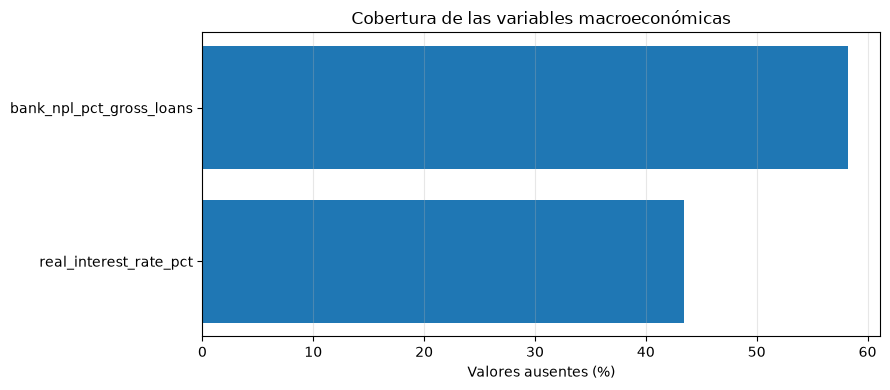

In [94]:
missing_pct = (
    wdi_monetary_financial_panel[monetary_financial_variables]
    .isna()
    .mean()
    .mul(100)
    .sort_values()
)

plt.figure(figsize=(9, 4))

plt.barh(
    missing_pct.index,
    missing_pct.values
)

plt.xlabel("Valores ausentes (%)")
plt.title("Cobertura de las variables macroeconómicas")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [95]:
period_label = f"{START_YEAR}_{END_YEAR}"

# Datos originales en formato largo
wdi_monetary_financial_long.to_csv(
    RAW_PATH
    / (
        "wdi_monetary_financial_long_"
        f"{period_label}.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)

# Panel país-año
wdi_monetary_financial_panel.to_csv(
    PROCESSED_PATH
    / (
        "wdi_monetary_financial_panel_"
        f"{period_label}.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)

# Resumen de cobertura
monetary_financial_coverage = (
    summary_monetary_financial[
        [
            "count",
            "missing_values",
            "missing_pct"
        ]
    ]
    .copy()
)

monetary_financial_coverage.to_csv(
    PROCESSED_PATH
    / (
        "wdi_monetary_financial_coverage_"
        f"{period_label}.csv"
    ),
    encoding="utf-8-sig"
)

print(
    "Archivos de variables monetarias y "
    "financieras guardados correctamente."
)

Archivos de variables monetarias y financieras guardados correctamente.


Hay muchos missings, por lo que se pruebas dsintitas alternativas

    "FR.INR.LEND": "lending_interest_rate_pct"
    "FR.INR.LNDP": "interest_rate_spread_pct"
    "FB.BNK.CAPA.ZS": "bank_capital_to_assets_pct"
    "FB.BNK.CAPA.ZS": "bank_capital_to_assets_pct"
    "FS.AST.PRVT.GD.ZS": "domestic_credit_private_sector_pct_gdp"

In [97]:
ALTERNATIVE_FINANCIAL_INDICATORS = {
    # Alternativas para condiciones monetarias
    "FR.INR.LEND": "lending_interest_rate_pct",
    "FR.INR.LNDP": "interest_rate_spread_pct",

    # Alternativas para estabilidad y exposición bancaria
    "FB.BNK.CAPA.ZS": "bank_capital_to_assets_pct",
    "FD.AST.PRVT.GD.ZS": (
        "domestic_credit_private_sector_banks_pct_gdp"
    ),
    "FS.AST.PRVT.GD.ZS": (
        "domestic_credit_private_sector_pct_gdp"
    )
}

ALTERNATIVE_FINANCIAL_INDICATORS

{'FR.INR.LEND': 'lending_interest_rate_pct',
 'FR.INR.LNDP': 'interest_rate_spread_pct',
 'FB.BNK.CAPA.ZS': 'bank_capital_to_assets_pct',
 'FD.AST.PRVT.GD.ZS': 'domestic_credit_private_sector_banks_pct_gdp',
 'FS.AST.PRVT.GD.ZS': 'domestic_credit_private_sector_pct_gdp'}

In [98]:
alternative_financial_downloads = []

for indicator_code, variable_name in (
    ALTERNATIVE_FINANCIAL_INDICATORS.items()
):

    print(
        f"Descargando {variable_name} "
        f"({indicator_code})..."
    )

    indicator_data = download_indicator(
        indicator_code=indicator_code,
        variable_name=variable_name
    )

    alternative_financial_downloads.append(
        indicator_data
    )


wdi_alternative_financial_long = pd.concat(
    alternative_financial_downloads,
    ignore_index=True
)

# Eliminación de agregados
wdi_alternative_financial_long = (
    wdi_alternative_financial_long[
        wdi_alternative_financial_long["iso3"].isin(
            countries["iso3"]
        )
    ]
    .copy()
)

wdi_alternative_financial_long = (
    wdi_alternative_financial_long
    .sort_values(["iso3", "year", "variable"])
    .reset_index(drop=True)
)

display(wdi_alternative_financial_long.head())

Descargando lending_interest_rate_pct (FR.INR.LEND)...
Descargando interest_rate_spread_pct (FR.INR.LNDP)...
Descargando bank_capital_to_assets_pct (FB.BNK.CAPA.ZS)...
Descargando domestic_credit_private_sector_banks_pct_gdp (FD.AST.PRVT.GD.ZS)...
Descargando domestic_credit_private_sector_pct_gdp (FS.AST.PRVT.GD.ZS)...


,iso3,year,indicator_code,variable,value
0,ABW,2000,FB.BNK.CAPA.ZS,bank_capital_to_assets_pct,NaN
1,ABW,2000,FD.AST.PRVT.GD.ZS,domestic_credit_private_sector_banks_pct_gdp,44.799701
2,ABW,2000,FS.AST.PRVT.GD.ZS,domestic_credit_private_sector_pct_gdp,44.799701
3,ABW,2000,FR.INR.LNDP,interest_rate_spread_pct,5.866667
4,ABW,2000,FR.INR.LEND,lending_interest_rate_pct,12.066667


In [99]:
wdi_alternative_financial_values = (
    wdi_alternative_financial_long
    .pivot_table(
        index=["iso3", "year"],
        columns="variable",
        values="value",
        aggfunc="first"
    )
    .reset_index()
)

wdi_alternative_financial_values.columns.name = None


wdi_alternative_financial_panel = (
    country_year_grid.merge(
        wdi_alternative_financial_values,
        on=["iso3", "year"],
        how="left"
    )
)

wdi_alternative_financial_panel = (
    wdi_alternative_financial_panel
    .sort_values(["iso3", "year"])
    .reset_index(drop=True)
)

In [100]:
original_financial_variables = [
    "real_interest_rate_pct",
    "bank_npl_pct_gross_loans"
]

alternative_financial_variables = list(
    ALTERNATIVE_FINANCIAL_INDICATORS.values()
)


financial_comparison_panel = (
    country_year_grid[
        ["iso3", "year"]
    ]
    .merge(
        wdi_monetary_financial_panel[
            ["iso3", "year"]
            + original_financial_variables
        ],
        on=["iso3", "year"],
        how="left",
        validate="one_to_one"
    )
    .merge(
        wdi_alternative_financial_panel[
            ["iso3", "year"]
            + alternative_financial_variables
        ],
        on=["iso3", "year"],
        how="left",
        validate="one_to_one"
    )
)

In [101]:
financial_variables_to_compare = (
    original_financial_variables
    + alternative_financial_variables
)

coverage_comparison = []

for variable in financial_variables_to_compare:

    valid_data = financial_comparison_panel.loc[
        financial_comparison_panel[variable].notna(),
        ["iso3", "year"]
    ]

    coverage_comparison.append({
        "variable": variable,
        "count": financial_comparison_panel[
            variable
        ].notna().sum(),
        "missing_values": financial_comparison_panel[
            variable
        ].isna().sum(),
        "missing_pct": (
            financial_comparison_panel[
                variable
            ].isna().mean() * 100
        ),
        "countries_with_data": (
            valid_data["iso3"].nunique()
        ),
        "first_year": valid_data["year"].min(),
        "last_year": valid_data["year"].max()
    })


coverage_comparison = (
    pd.DataFrame(coverage_comparison)
    .sort_values("missing_pct")
    .reset_index(drop=True)
)

coverage_comparison[
    "missing_pct"
] = coverage_comparison[
    "missing_pct"
].round(2)

display(coverage_comparison)

,variable,count,missing_values,missing_pct,countries_with_data,first_year,last_year
0,domestic_credit_private_sector_banks_pct_gdp,4306,1119,20.63,186,2000,2024
1,domestic_credit_private_sector_pct_gdp,4009,1416,26.10,186,2000,2024
2,lending_interest_rate_pct,3073,2352,43.35,147,2000,2024
3,real_interest_rate_pct,3067,2358,43.47,147,2000,2024
4,interest_rate_spread_pct,2847,2578,47.52,138,2000,2024
5,bank_npl_pct_gross_loans,2267,3158,58.21,154,2000,2024
6,bank_capital_to_assets_pct,2212,3213,59.23,151,2000,2024


La cobertura de las variables monetarias y financieras es inferior a la de otros bloques. La variable de crédito bancario al sector privado presenta la mayor disponibilidad, con aproximadamente un 20 % de valores ausentes, por lo que se mantiene como principal indicador financiero. Las variables de tipo de interés real y préstamos no productivos también se conservan en la base maestra, aunque su incorporación al modelo definitivo dependerá de la cobertura conjunta con la variable objetivo y el resto de predictores.

## Quinta fase: Variables institucionales

El quinto bloque recoge la calidad institucional y la capacidad de gobierno de cada país. Se incorporan la estabilidad política, la efectividad gubernamental, el Estado de derecho, el control de la corrupción, la calidad regulatoria y la voz y rendición de cuentas.

Estas variables permiten analizar la solidez de las instituciones, la capacidad del Estado para aplicar políticas públicas, el cumplimiento de las normas y la exposición a conflictos políticos, violencia o corrupción.

Los datos proceden de los Worldwide Governance Indicators del Banco Mundial y se descargan para el periodo 2000-2024. Se utilizan las estimaciones estandarizadas, donde los valores más elevados representan una mejor calidad institucional.

In [102]:
datos_institucionales = {
    "Variable": [
        "Estabilidad política y ausencia de violencia",
        "Efectividad gubernamental",
        "Estado de derecho",
        "Control de la corrupción",
        "Calidad regulatoria",
        "Voz y rendición de cuentas"
    ],
    "Código WGI": [
        "PV.EST",
        "GE.EST",
        "RL.EST",
        "CC.EST",
        "RQ.EST",
        "VA.EST"
    ],
    "Medida": [
        "Estimación estandarizada; valores altos indican mayor estabilidad",
        "Estimación estandarizada; valores altos indican mayor efectividad",
        "Estimación estandarizada; valores altos indican mayor Estado de derecho",
        "Estimación estandarizada; valores altos indican mayor control de la corrupción",
        "Estimación estandarizada; valores altos indican mayor calidad regulatoria",
        "Estimación estandarizada; valores altos indican mayor participación y rendición de cuentas"
    ]
}

variables_institucionales_df = pd.DataFrame(
    datos_institucionales
)

tabla_institucionales = (
    variables_institucionales_df.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "left",
        "vertical-align": "middle",
        "white-space": "normal",
        "overflow-wrap": "break-word",
        "padding": "10px",
        "border": "1px solid #dddddd",
        "font-size": "10px"
    })
    .set_properties(
        subset=["Variable"],
        **{
            "background-color": "#d9eaf4",
            "font-weight": "bold",
            "width": "35%"
        }
    )
    .set_properties(
        subset=["Código WGI"],
        **{
            "font-family": "monospace",
            "width": "20%"
        }
    )
    .set_properties(
        subset=["Medida"],
        **{
            "width": "45%"
        }
    )
    .set_table_styles([
        {
            "selector": "table",
            "props": [
                ("width", "100%"),
                ("table-layout", "fixed"),
                ("border-collapse", "collapse")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#d9eaf4"),
                ("text-align", "left"),
                ("font-weight", "bold"),
                ("padding", "10px"),
                ("border", "1px solid #dddddd"),
                ("font-size", "10px")
            ]
        },
        {
            "selector": "tbody tr:nth-child(even) td:not(:first-child)",
            "props": [
                ("background-color", "#f5f5f5")
            ]
        }
    ])
)

display(tabla_institucionales)

Variable,Código WGI,Medida
Estabilidad política y ausencia de violencia,PV.EST,Estimación estandarizada; valores altos indican mayor estabilidad
Efectividad gubernamental,GE.EST,Estimación estandarizada; valores altos indican mayor efectividad
Estado de derecho,RL.EST,Estimación estandarizada; valores altos indican mayor Estado de derecho
Control de la corrupción,CC.EST,Estimación estandarizada; valores altos indican mayor control de la corrupción
Calidad regulatoria,RQ.EST,Estimación estandarizada; valores altos indican mayor calidad regulatoria
Voz y rendición de cuentas,VA.EST,Estimación estandarizada; valores altos indican mayor participación y rendición de cuentas


In [119]:
import pandas as pd
import requests

WGI_URL = (
    "https://datacatalogfiles.worldbank.org/"
    "ddh-published/0038026/DR0095947/"
    "wgidataset_with_sourcedata-2025.xlsx"
)

WGI_FILE = RAW_PATH / "wgi_2025_1996_2024.xlsx"

if not WGI_FILE.exists():

    print("Descargando el archivo WGI oficial...")

    response = requests.get(
        WGI_URL,
        timeout=180
    )

    response.raise_for_status()

    WGI_FILE.write_bytes(response.content)

    print("Archivo descargado correctamente.")

else:
    print("El archivo WGI ya está descargado.")

print(WGI_FILE)

El archivo WGI ya está descargado.
data\raw\wgi_2025_1996_2024.xlsx


In [120]:
wgi_excel = pd.ExcelFile(WGI_FILE)


print("Hojas disponibles:")
print(wgi_excel.sheet_names)

Hojas disponibles:
['va', 'pv', 'ge', 'rq', 'rl', 'cc']


In [122]:
wgi_downloads = []

for sheet_name, indicator_info in WGI_SHEETS.items():

    print(
        f"Leyendo {indicator_info['variable']} "
        f"({indicator_info['indicator_code']})..."
    )

    sheet_data = pd.read_excel(
        WGI_FILE,
        sheet_name=sheet_name
    )

    # Localizamos la columna de estimación automáticamente
    estimate_columns = [
        column
        for column in sheet_data.columns
        if str(column).startswith(
            "Governance estimate"
        )
    ]

    if not estimate_columns:
        raise KeyError(
            f"No se encontró la estimación "
            f"en la hoja {sheet_name}."
        )

    estimate_column = estimate_columns[0]

    indicator_data = (
        sheet_data[
            [
                "Economy (code)",
                "Year",
                estimate_column
            ]
        ]
        .rename(
            columns={
                "Economy (code)": "iso3",
                "Year": "year",
                estimate_column: "value"
            }
        )
        .copy()
    )

    indicator_data["year"] = pd.to_numeric(
        indicator_data["year"],
        errors="coerce"
    ).astype("Int64")

    indicator_data["value"] = pd.to_numeric(
        indicator_data["value"],
        errors="coerce"
    )

    indicator_data["indicator_code"] = (
        indicator_info["indicator_code"]
    )

    indicator_data["variable"] = (
        indicator_info["variable"]
    )

    # Selección del periodo del TFM
    indicator_data = indicator_data[
        indicator_data["year"].between(
            START_YEAR,
            END_YEAR
        )
    ].copy()

    wgi_downloads.append(indicator_data)

Leyendo political_stability_estimate (PV.EST)...
Leyendo government_effectiveness_estimate (GE.EST)...
Leyendo rule_of_law_estimate (RL.EST)...
Leyendo control_of_corruption_estimate (CC.EST)...
Leyendo regulatory_quality_estimate (RQ.EST)...
Leyendo voice_accountability_estimate (VA.EST)...


In [123]:
wgi_institutional_long = pd.concat(
    wgi_downloads,
    ignore_index=True
)

# Conservamos únicamente los países
# presentes en nuestra base principal
wgi_institutional_long = (
    wgi_institutional_long[
        wgi_institutional_long["iso3"].isin(
            countries["iso3"]
        )
    ]
    .copy()
)

wgi_institutional_long = (
    wgi_institutional_long
    .sort_values(
        ["iso3", "year", "variable"]
    )
    .reset_index(drop=True)
)

print(
    "Observaciones:",
    len(wgi_institutional_long)
)

print(
    "Número de países:",
    wgi_institutional_long["iso3"].nunique()
)

display(wgi_institutional_long.head())

Observaciones: 28972
Número de países: 206


,iso3,year,value,indicator_code,variable
0,ABW,2004,0.966286,CC.EST,control_of_corruption_estimate
1,ABW,2004,0.895142,GE.EST,government_effectiveness_estimate
2,ABW,2004,0.629215,PV.EST,political_stability_estimate
3,ABW,2004,0.743312,RQ.EST,regulatory_quality_estimate
4,ABW,2004,0.607024,RL.EST,rule_of_law_estimate


In [126]:
wgi_download_check = (
    wgi_institutional_long
    .groupby(
        ["indicator_code", "variable"],
        as_index=False
    )
    .agg(
        observations=("value", "count"),
        countries=("iso3", "nunique"),
        first_year=("year", "min"),
        last_year=("year", "max")
    )
)

display(wgi_download_check)

,indicator_code,variable,observations,countries,first_year,last_year
0,CC.EST,control_of_corruption_estimate,4808,206,2000,2024
1,GE.EST,government_effectiveness_estimate,4782,204,2000,2024
2,PV.EST,political_stability_estimate,4858,206,2000,2024
3,RL.EST,rule_of_law_estimate,4879,206,2000,2024
4,RQ.EST,regulatory_quality_estimate,4781,204,2000,2024
5,VA.EST,voice_accountability_estimate,4864,206,2000,2024


In [127]:
wgi_institutional_values = (
    wgi_institutional_long
    .pivot_table(
        index=["iso3", "year"],
        columns="variable",
        values="value",
        aggfunc="first"
    )
    .reset_index()
)

wgi_institutional_values.columns.name = None


wgi_institutional_panel = (
    country_year_grid.merge(
        wgi_institutional_values,
        on=["iso3", "year"],
        how="left",
        validate="one_to_one"
    )
)

wgi_institutional_panel = (
    wgi_institutional_panel
    .sort_values(["iso3", "year"])
    .reset_index(drop=True)
)

print(
    "Dimensiones:",
    wgi_institutional_panel.shape
)

print(
    "Duplicados país-año:",
    wgi_institutional_panel.duplicated(
        ["iso3", "year"]
    ).sum()
)

display(wgi_institutional_panel.head())

Dimensiones: (5425, 12)
Duplicados país-año: 0


,iso3,iso2,country,region,income_level,year,control_of_corruption_estimate,government_effectiveness_estimate,political_stability_estimate,regulatory_quality_estimate,rule_of_law_estimate,voice_accountability_estimate
0,ABW,AW,Aruba,Latin America & Caribbean,High income,2000,NaN,NaN,NaN,NaN,NaN,NaN
1,ABW,AW,Aruba,Latin America & Caribbean,High income,2001,NaN,NaN,NaN,NaN,NaN,NaN
2,ABW,AW,Aruba,Latin America & Caribbean,High income,2002,NaN,NaN,NaN,NaN,NaN,NaN
3,ABW,AW,Aruba,Latin America & Caribbean,High income,2003,NaN,NaN,NaN,NaN,NaN,NaN
4,ABW,AW,Aruba,Latin America & Caribbean,High income,2004,0.966286,0.895142,0.629215,0.743312,0.607024,0.443246


## Análisis descriptivo preliminar VARIABLES INSTITUCIONALES

En este quinto bloque se realiza una revisión preliminar de las variables institucionales con el objetivo de comprobar la calidad, disponibilidad y cobertura de los datos descargados. Se revisan las dimensiones de la base, el número de países y años incluidos, la presencia de valores ausentes y la existencia de posibles duplicados.

Las variables institucionales permiten evaluar la estabilidad política, la capacidad de actuación del Estado, el cumplimiento de las normas, la calidad regulatoria y el control de la corrupción.

El análisis descriptivo completo y las posibles transformaciones se realizarán una vez integrados todos los bloques de información.

### 1.- ESTABILIDAD POLÍTICA Y AUSENCIA DE VIOLENCIA O TERRORISMO

> `"PV.EST": "political_stability_estimate"`

Mide la percepción sobre la probabilidad de que el gobierno sea desestabilizado o sustituido por medios inconstitucionales o violentos, incluyendo la violencia política y el terrorismo.

Una mayor inestabilidad puede interrumpir la actividad económica, reducir la inversión, provocar salidas de capital y dificultar el cumplimiento de las obligaciones financieras del país.

              Mayor estabilidad política ⇒ Menor riesgo país

Esta variable conserva el indicador de estabilidad política y terrorismo utilizado en el TFG, pero empleando directamente la fuente oficial del Banco Mundial.

### 2.- EFECTIVIDAD GUBERNAMENTAL

> `"GE.EST": "government_effectiveness_estimate"`

Mide la percepción sobre la calidad de los servicios públicos, la competencia e independencia de la Administración, la formulación de políticas y la capacidad del gobierno para aplicarlas de manera efectiva.

Una Administración eficaz puede gestionar mejor los recursos públicos, recaudar ingresos, ejecutar reformas y responder ante crisis económicas o financieras.

          Mayor efectividad gubernamental ⇒ Menor riesgo país

### 3.- ESTADO DE DERECHO

> `"RL.EST": "rule_of_law_estimate"`

Mide la confianza de los agentes en las normas de la sociedad y su cumplimiento. Incluye aspectos relacionados con la protección de los derechos de propiedad, el cumplimiento de los contratos, la actuación de la policía y los tribunales y la incidencia de la delincuencia.

Un Estado de derecho sólido reduce la incertidumbre jurídica, favorece la inversión y mejora la protección de acreedores e inversores.

                 Mayor Estado de derecho ⇒ Menor riesgo país

### 4.- CONTROL DE LA CORRUPCIÓN

> `"CC.EST": "control_of_corruption_estimate"`

Mide la percepción sobre el grado en que el poder público se utiliza para obtener beneficios privados, incluyendo tanto pequeñas prácticas corruptas como grandes casos de apropiación del Estado por intereses particulares.

La corrupción puede reducir la eficiencia del gasto público, disminuir la recaudación, perjudicar la confianza institucional y desincentivar la inversión.

            Mayor control de la corrupción ⇒ Menor riesgo país

Esta variable permite conservar el componente de corrupción incluido en el TFG utilizando una fuente homogénea y comparable internacionalmente.

### 5.- CALIDAD REGULATORIA

> `"RQ.EST": "regulatory_quality_estimate"`

Mide la capacidad del gobierno para formular y aplicar políticas y regulaciones que favorezcan el desarrollo del sector privado.

Una regulación estable y predecible reduce los costes de operar, mejora la confianza empresarial y facilita la inversión y el crecimiento económico.

                Mayor calidad regulatoria ⇒ Menor riesgo país

### 6.- VOZ Y RENDICIÓN DE CUENTAS

> `"VA.EST": "voice_accountability_estimate"`

Mide la capacidad de la ciudadanía para participar en la elección de sus gobiernos, así como la libertad de expresión, la libertad de asociación y la existencia de medios de comunicación independientes.

Una mayor participación y rendición de cuentas puede favorecer la transparencia de las instituciones y limitar la adopción de decisiones públicas arbitrarias.

             Mayor voz y rendición de cuentas ⇒ Menor riesgo país

Esta dimensión también puede actuar como una aproximación institucional al grado de democracia, aunque posteriormente se estudiará la incorporación de un índice de democracia específico.

In [128]:
df_institutional = wgi_institutional_panel.copy()

institutional_variables = [
    "political_stability_estimate",
    "government_effectiveness_estimate",
    "rule_of_law_estimate",
    "control_of_corruption_estimate",
    "regulatory_quality_estimate",
    "voice_accountability_estimate"
]

print(
    "Dimensiones:",
    df_institutional.shape
)

print(
    "Número de países:",
    df_institutional["iso3"].nunique()
)

print(
    "Periodo:",
    df_institutional["year"].min(),
    "-",
    df_institutional["year"].max()
)

print(
    "Duplicados país-año:",
    df_institutional.duplicated(
        ["iso3", "year"]
    ).sum()
)

Dimensiones: (5425, 12)
Número de países: 217
Periodo: 2000 - 2024
Duplicados país-año: 0


In [129]:
summary_institutional = (
    wgi_institutional_panel[
        institutional_variables
    ]
    .describe(
        percentiles=[0.25, 0.50, 0.75]
    )
    .T
)

summary_institutional["missing_values"] = (
    wgi_institutional_panel[
        institutional_variables
    ]
    .isna()
    .sum()
)

summary_institutional["missing_pct"] = (
    wgi_institutional_panel[
        institutional_variables
    ]
    .isna()
    .mean()
    .mul(100)
)

summary_institutional = (
    summary_institutional[
        [
            "count",
            "missing_values",
            "missing_pct",
            "mean",
            "std",
            "min",
            "25%",
            "50%",
            "75%",
            "max"
        ]
    ]
    .round(2)
)

display(summary_institutional)

,count,missing_values,missing_pct,mean,std,min,25%,50%,75%,max
political_stability_estimate,4858.0,567,10.45,-0.03,0.99,-3.05,-0.66,0.03,0.83,1.76
government_effectiveness_estimate,4782.0,643,11.85,-0.03,0.99,-2.46,-0.75,-0.15,0.66,2.35
rule_of_law_estimate,4879.0,546,10.06,-0.04,1.00,-2.51,-0.81,-0.19,0.79,2.11
control_of_corruption_estimate,4808.0,617,11.37,-0.04,1.00,-2.06,-0.80,-0.23,0.66,2.40
regulatory_quality_estimate,4781.0,644,11.87,-0.02,0.99,-2.58,-0.74,-0.15,0.73,2.26
voice_accountability_estimate,4864.0,561,10.34,-0.02,0.99,-2.36,-0.83,0.00,0.83,1.98


In [130]:
period_label = f"{START_YEAR}_{END_YEAR}"

# Datos en formato largo
wgi_institutional_long.to_csv(
    RAW_PATH
    / f"wgi_institutional_long_{period_label}.csv",
    index=False,
    encoding="utf-8-sig"
)

# Panel país-año
wgi_institutional_panel.to_csv(
    PROCESSED_PATH
    / f"wgi_institutional_panel_{period_label}.csv",
    index=False,
    encoding="utf-8-sig"
)

# Resumen de cobertura
institutional_coverage = (
    summary_institutional[
        [
            "count",
            "missing_values",
            "missing_pct"
        ]
    ]
    .copy()
)

institutional_coverage.to_csv(
    PROCESSED_PATH
    / f"wgi_institutional_coverage_{period_label}.csv",
    encoding="utf-8-sig"
)

print(
    "Archivos de variables institucionales "
    "guardados correctamente."
)

Archivos de variables institucionales guardados correctamente.


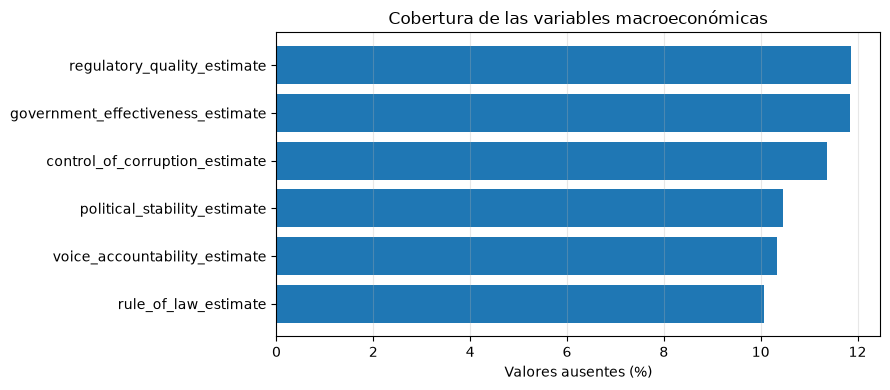

In [132]:
missing_pct = (
    wgi_institutional_panel[
        institutional_variables
    ]
    .isna()
    .mean()
    .mul(100)
    .sort_values()
)

plt.figure(figsize=(9, 4))

plt.barh(
    missing_pct.index,
    missing_pct.values
)

plt.xlabel("Valores ausentes (%)")
plt.title("Cobertura de las variables macroeconómicas")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


#### INDICE DE DEMOCRACIA
Este bloque incorpora una medida específica del grado de democracia de cada país. Se utiliza el Índice de Democracia Electoral elaborado por el proyecto Varieties of Democracy —V-Dem—, que analiza hasta qué punto los gobernantes son elegidos mediante elecciones libres y justas, con sufragio amplio y garantías para la libertad de expresión y asociación.

El indicador toma valores comprendidos entre 0 y 1, donde los valores más elevados representan un mayor nivel de democracia electoral. Los datos se obtienen del panel país-año V-Dem Core y se seleccionan para el periodo 2000-2024.

In [134]:
from pathlib import Path
import requests
import pyreadr
import pandas as pd


VDEM_URL = (
    "https://raw.githubusercontent.com/"
    "vdeminstitute/vdemdata/master/data/vdem.RData"
)

VDEM_FILE = RAW_PATH / "vdem_latest.RData"


print("Descargando la versión más reciente de V-Dem...")

response = requests.get(
    VDEM_URL,
    timeout=300
)

response.raise_for_status()

VDEM_FILE.write_bytes(response.content)

print("Archivo descargado correctamente:")
print(VDEM_FILE)

Descargando la versión más reciente de V-Dem...
Archivo descargado correctamente:
data\raw\vdem_latest.RData


In [136]:
vdem_objects = pyreadr.read_r(
    VDEM_FILE
)

print(
    "Objetos encontrados:",
    list(vdem_objects.keys())
)

Objetos encontrados: ['vdem']


In [137]:
if "vdem" in vdem_objects:
    vdem_raw = vdem_objects["vdem"]
else:
    vdem_raw = next(
        iter(vdem_objects.values())
    )

print(
    "Dimensiones originales:",
    vdem_raw.shape
)

display(vdem_raw.head())

Dimensiones originales: (28092, 4618)


country_name country_text_id  country_id    year historical_date  project  historical                  histname  codingstart  codingend  codingstart_contemp  codingend_contemp  codingstart_hist  \
0       Mexico             MEX         3.0  1789.0      1789-12-31      1.0         1.0  Viceroyalty of New Spain       1789.0     2025.0               1900.0             2025.0            1789.0   
1       Mexico             MEX         3.0  1790.0      1790-12-31      1.0         1.0  Viceroyalty of New Spain       1789.0     2025.0               1900.0             2025.0            1789.0   
2       Mexico             MEX         3.0  1791.0      1791-12-31      1.0         1.0  Viceroyalty of New Spain       1789.0     2025.0               1900.0             2025.0            1789.0   
3       Mexico             MEX         3.0  1792.0      1792-12-31      1.0         1.0  Viceroyalty of New Spain       1789.0     2025.0               1900.0             2025.0            1789.0   
4       Mexico             MEX         3.0  1793.0      1793-12-31      1.0         1.0  Viceroyalty of New Spain       1789.0     2025.0               1900.0             2025.0            1789.0   

   codingend_hist  gapstart1  gapstart2  gapstart3  gapend1  gapend2  gapend3  gap_index  COWcode  v2x_polyarchy  v2x_polyarchy_codelow  v2x_polyarchy_codehigh  v2x_polyarchy_sd  v2x_libdem  \
0          1920.0        NaN        NaN        NaN      NaN      NaN      NaN        1.0     70.0          0.027                  0.016                   0.036             0.011       0.044   
1          1920.0        NaN        NaN        NaN      NaN      NaN      NaN        1.0     70.0          0.027                  0.016                   0.036             0.011       0.044   
2          1920.0        NaN        NaN        NaN      NaN      NaN      NaN        1.0     70.0          0.027                  0.016                   0.036             0.011       0.044   
3          1920.0        NaN        NaN        NaN      NaN      NaN      NaN        1.0     70.0          0.027                  0.016                   0.036             0.011       0.044   
4          1920.0        NaN        NaN        NaN      NaN      NaN      NaN        1.0     70.0          0.027                  0.016                   0.036             0.011       0.044   

   v2x_libdem_codelow  v2x_libdem_codehigh  v2x_libdem_sd  v2x_partipdem  v2x_partipdem_codelow  v2x_partipdem_codehigh  v2x_partipdem_sd  v2x_delibdem  v2x_delibdem_codelow  v2x_delibdem_codehigh  \
0                0.03                0.057          0.014          0.006                  0.001                   0.009             0.006           NaN                   NaN                    NaN   
1                0.03                0.057          0.014          0.006                  0.001                   0.009             0.006           NaN                   NaN                    NaN   
2                0.03                0.057          0.014          0.006                  0.001                   0.009             0.006           NaN                   NaN                    NaN   
3                0.03                0.057          0.014          0.006                  0.001                   0.009             0.006           NaN                   NaN                    NaN   
4                0.03                0.057          0.014          0.006                  0.001                   0.009             0.006           NaN                   NaN                    NaN   

   v2x_delibdem_sd  v2x_egaldem  v2x_egaldem_codelow  v2x_egaldem_codehigh  v2x_egaldem_sd  v2x_api  v2x_api_codelow  v2x_api_codehigh  v2x_api_sd  v2x_mpi  v2x_mpi_codelow  v2x_mpi_codehigh  \
0              NaN          NaN                  NaN                   NaN             NaN    0.055            0.032             0.072       0.021      0.0              0.0               0.0   
1              NaN          NaN                  NaN       

In [138]:
required_vdem_columns = [
    "country_text_id",
    "country_name",
    "year",
    "v2x_polyarchy"
]

missing_vdem_columns = [
    column
    for column in required_vdem_columns
    if column not in vdem_raw.columns
]

if missing_vdem_columns:
    raise KeyError(
        "No se han encontrado estas columnas: "
        f"{missing_vdem_columns}"
    )

print(
    "Las columnas necesarias están disponibles."
)

Las columnas necesarias están disponibles.


In [139]:
vdem_democracy_values = (
    vdem_raw[
        [
            "country_text_id",
            "country_name",
            "year",
            "v2x_polyarchy"
        ]
    ]
    .rename(
        columns={
            "country_text_id": "iso3",
            "country_name": "country_vdem",
            "v2x_polyarchy": (
                "electoral_democracy_index"
            )
        }
    )
    .copy()
)

In [140]:
vdem_democracy_values["year"] = pd.to_numeric(
    vdem_democracy_values["year"],
    errors="coerce"
).astype("Int64")

vdem_democracy_values[
    "electoral_democracy_index"
] = pd.to_numeric(
    vdem_democracy_values[
        "electoral_democracy_index"
    ],
    errors="coerce"
)

In [141]:
vdem_democracy_values = (
    vdem_democracy_values[
        vdem_democracy_values["year"].between(
            START_YEAR,
            END_YEAR
        )
    ]
    .dropna(
        subset=["iso3", "year"]
    )
    .copy()
)

In [142]:
vdem_democracy_values = (
    vdem_democracy_values[
        vdem_democracy_values["iso3"].isin(
            countries["iso3"]
        )
    ]
    .sort_values(["iso3", "year"])
    .reset_index(drop=True)
)

print(
    "Observaciones:",
    len(vdem_democracy_values)
)

print(
    "Número de países:",
    vdem_democracy_values["iso3"].nunique()
)

display(vdem_democracy_values.head())

Observaciones: 4364
Número de países: 175


,iso3,country_vdem,year,electoral_democracy_index
0,AFG,Afghanistan,2000,0.073
1,AFG,Afghanistan,2001,0.083
2,AFG,Afghanistan,2002,0.218
3,AFG,Afghanistan,2003,0.224
4,AFG,Afghanistan,2004,0.235


In [143]:
vdem_duplicates = (
    vdem_democracy_values
    .duplicated(["iso3", "year"])
    .sum()
)

print(
    "Duplicados país-año:",
    vdem_duplicates
)

Duplicados país-año: 0


In [144]:
vdem_democracy_panel = (
    country_year_grid.merge(
        vdem_democracy_values[
            [
                "iso3",
                "year",
                "electoral_democracy_index"
            ]
        ],
        on=["iso3", "year"],
        how="left",
        validate="one_to_one"
    )
)

vdem_democracy_panel = (
    vdem_democracy_panel
    .sort_values(["iso3", "year"])
    .reset_index(drop=True)
)

print(
    "Dimensiones:",
    vdem_democracy_panel.shape
)

print(
    "Número de países:",
    vdem_democracy_panel["iso3"].nunique()
)

print(
    "Periodo:",
    vdem_democracy_panel["year"].min(),
    "-",
    vdem_democracy_panel["year"].max()
)

display(vdem_democracy_panel.head())

Dimensiones: (5425, 7)
Número de países: 217
Periodo: 2000 - 2024


,iso3,iso2,country,region,income_level,year,electoral_democracy_index
0,ABW,AW,Aruba,Latin America & Caribbean,High income,2000,NaN
1,ABW,AW,Aruba,Latin America & Caribbean,High income,2001,NaN
2,ABW,AW,Aruba,Latin America & Caribbean,High income,2002,NaN
3,ABW,AW,Aruba,Latin America & Caribbean,High income,2003,NaN
4,ABW,AW,Aruba,Latin America & Caribbean,High income,2004,NaN


In [145]:
democracy_variables = [
    "electoral_democracy_index"
]

summary_democracy = (
    vdem_democracy_panel[
        democracy_variables
    ]
    .describe(
        percentiles=[0.25, 0.50, 0.75]
    )
    .T
)

summary_democracy["missing_values"] = (
    vdem_democracy_panel[
        democracy_variables
    ]
    .isna()
    .sum()
)

summary_democracy["missing_pct"] = (
    vdem_democracy_panel[
        democracy_variables
    ]
    .isna()
    .mean()
    .mul(100)
)

summary_democracy = summary_democracy[
    [
        "count",
        "missing_values",
        "missing_pct",
        "mean",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max"
    ]
].round(3)

display(summary_democracy)

,count,missing_values,missing_pct,mean,std,min,25%,50%,75%,max
electoral_democracy_index,4364.0,1061,19.558,0.515,0.262,0.014,0.277,0.518,0.76,0.922


In [146]:
period_label = f"{START_YEAR}_{END_YEAR}"

vdem_democracy_values.to_csv(
    PROCESSED_PATH
    / f"vdem_democracy_values_{period_label}.csv",
    index=False,
    encoding="utf-8-sig"
)

vdem_democracy_panel.to_csv(
    PROCESSED_PATH
    / f"vdem_democracy_panel_{period_label}.csv",
    index=False,
    encoding="utf-8-sig"
)

democracy_coverage = summary_democracy[
    [
        "count",
        "missing_values",
        "missing_pct"
    ]
].copy()

democracy_coverage.to_csv(
    PROCESSED_PATH
    / f"vdem_democracy_coverage_{period_label}.csv",
    encoding="utf-8-sig"
)

print(
    "Archivos del índice de democracia "
    "guardados correctamente."
)

Archivos del índice de democracia guardados correctamente.


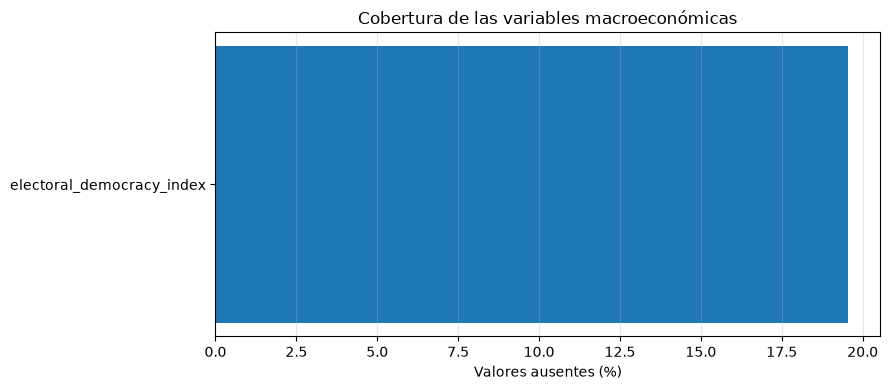

In [147]:
missing_pct = (
    vdem_democracy_panel[
        democracy_variables]
    .isna()
    .mean()
    .mul(100)
    .sort_values()
)

plt.figure(figsize=(9, 4))

plt.barh(
    missing_pct.index,
    missing_pct.values
)

plt.xlabel("Valores ausentes (%)")
plt.title("Cobertura de las variables macroeconómicas")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


Para terminar la base de datos se añaden las siguientes variaables.

1. Apertura comercial
   
`"NE.EXP.GNFS.ZS": "exports_pct_gdp"`
`"NE.IMP.GNFS.ZS": "imports_pct_gdp"`

Para luego contruir:

\begin{equation}
\text{trade\_openness\_pct\_gdp} = \text{exports\_pct\_gdp} + \text{imports\_pct\_gdp}
\end{equation}

## Séptima fase: Historial de impago soberano

Este bloque incorpora información sobre los episodios de impago y reestructuración de la deuda soberana. Se utiliza la base BoC–BoE Sovereign Default Database, elaborada por el Banco de Canadá en colaboración con el Banco de Inglaterra y actualizada anualmente.

La base recoge el volumen de obligaciones públicas en situación de impago frente a acreedores oficiales y privados. A partir del importe total de deuda en default se construyen indicadores que identifican si el país se encuentra actualmente en impago, si ha registrado algún episodio durante los cinco o diez años anteriores y el tiempo transcurrido desde el último episodio.

Estas variables permiten incorporar al modelo la reputación crediticia histórica del país, ya que un impago reciente o persistente puede influir en la percepción de solvencia, el acceso a los mercados financieros y la calificación crediticia soberana.

Los datos originales abarcan desde 1960 hasta el último año disponible. Para el panel final se seleccionan las observaciones correspondientes al periodo 2000-2024, aunque se conserva la información anterior para calcular correctamente el historial de impago.

In [163]:
datos_default = {
    "Variable": [
        "Deuda soberana en impago",
        "Impago soberano actual",
        "Impago en los 5 años anteriores",
        "Impago en los 10 años anteriores",
        "Años desde el último impago",
        "Sin impagos históricos registrados"
    ],
    "Código": [
        "sovereign_debt_in_default_usd_mn",
        "sovereign_default_dummy",
        "default_previous_5y",
        "default_previous_10y",
        "years_since_last_default",
        "never_default_history_dummy"
    ],
    "Medida": [
        "Millones de USD",
        "Variable binaria: 1 si existe deuda soberana en impago",
        "Variable binaria: 1 si hubo impago entre t-5 y t-1",
        "Variable binaria: 1 si hubo impago entre t-10 y t-1",
        "Número de años desde el último impago registrado",
        "Variable binaria: 1 si no existe ningún impago previo"
    ]
}

variables_default_df = pd.DataFrame(datos_default)

tabla_default = (
    variables_default_df.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "left",
        "vertical-align": "middle",
        "white-space": "normal",
        "overflow-wrap": "break-word",
        "padding": "10px",
        "border": "1px solid #dddddd",
        "font-size": "10px"
    })
    .set_properties(
        subset=["Variable"],
        **{
            "background-color": "#d9eaf4",
            "font-weight": "bold",
            "width": "32%"
        }
    )
    .set_properties(
        subset=["Código"],
        **{
            "font-family": "monospace",
            "width": "32%"
        }
    )
    .set_properties(
        subset=["Medida"],
        **{
            "width": "36%"
        }
    )
    .set_table_styles([
        {
            "selector": "table",
            "props": [
                ("width", "100%"),
                ("table-layout", "fixed"),
                ("border-collapse", "collapse")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#d9eaf4"),
                ("text-align", "left"),
                ("font-weight", "bold"),
                ("padding", "10px"),
                ("border", "1px solid #dddddd"),
                ("font-size", "10px")
            ]
        },
        {
            "selector": "tbody tr:nth-child(even) td:not(:first-child)",
            "props": [
                ("background-color", "#f5f5f5")
            ]
        }
    ])
)

display(tabla_default)

Variable,Código,Medida
Deuda soberana en impago,sovereign_debt_in_default_usd_mn,Millones de USD
Impago soberano actual,sovereign_default_dummy,Variable binaria: 1 si existe deuda soberana en impago
Impago en los 5 años anteriores,default_previous_5y,Variable binaria: 1 si hubo impago entre t-5 y t-1
Impago en los 10 años anteriores,default_previous_10y,Variable binaria: 1 si hubo impago entre t-10 y t-1
Años desde el último impago,years_since_last_default,Número de años desde el último impago registrado
Sin impagos históricos registrados,never_default_history_dummy,Variable binaria: 1 si no existe ningún impago previo


In [166]:
from pathlib import Path
from urllib.parse import urljoin

import requests
from bs4 import BeautifulSoup


DEFAULT_DATABASE_FILE = (
    RAW_PATH / "boc_boe_sovereign_default_latest.xlsx"
)

DEFAULT_DATABASE_PAGE = (
    "https://www.bankofcanada.ca/2025/10/"
    "staff-analytical-note-2025-24/"
)


def download_sovereign_default_database():
    """
    Localiza y descarga el Excel oficial de la base
    BoC-BoE de impagos soberanos.
    """

    headers = {
        "User-Agent": (
            "Mozilla/5.0 "
            "(academic research; sovereign risk TFM)"
        )
    }

    # Abrimos la publicación oficial
    page_response = requests.get(
        DEFAULT_DATABASE_PAGE,
        headers=headers,
        timeout=30
    )

    page_response.raise_for_status()

    soup = BeautifulSoup(
        page_response.text,
        "html.parser"
    )

    # Buscamos el enlace al Excel
    excel_links = []

    for link in soup.find_all("a", href=True):

        href = link["href"]

        if (
            href.lower().endswith(".xlsx")
            and "boc-boe" in href.lower()
            and "database" in href.lower()
        ):
            excel_links.append(
                urljoin(
                    DEFAULT_DATABASE_PAGE,
                    href
                )
            )

    if not excel_links:
        raise RuntimeError(
            "No se encontró el enlace al Excel "
            "en la página oficial."
        )

    database_url = excel_links[0]

    print("Descargando:")
    print(database_url)

    file_response = requests.get(
        database_url,
        headers=headers,
        timeout=120
    )

    file_response.raise_for_status()

    # Los archivos xlsx son contenedores ZIP
    if file_response.content[:2] != b"PK":
        raise RuntimeError(
            "El archivo descargado no parece "
            "ser un Excel válido."
        )

    DEFAULT_DATABASE_FILE.write_bytes(
        file_response.content
    )

    return {
        "file": DEFAULT_DATABASE_FILE,
        "url": database_url,
        "source": "Bank of Canada"
    }

In [167]:
default_download_info = (
    download_sovereign_default_database()
)

print("Fuente:", default_download_info["source"])
print("Archivo:", default_download_info["file"])
print("Enlace utilizado:", default_download_info["url"])

Descargando:
https://www.bankofcanada.ca/wp-content/uploads/2025/10/BoC-BoE-Database-2025.xlsx
Fuente: Bank of Canada
Archivo: data\raw\boc_boe_sovereign_default_latest.xlsx
Enlace utilizado: https://www.bankofcanada.ca/wp-content/uploads/2025/10/BoC-BoE-Database-2025.xlsx


In [168]:
default_excel = pd.ExcelFile(
    DEFAULT_DATABASE_FILE
)

print("Hojas disponibles:")
print(default_excel.sheet_names)

Hojas disponibles:
['2025 in Progress', 'Debt_2025']


In [169]:
def find_default_data_sheet(excel_file):
    """
    Identifica la hoja que contiene las observaciones
    país-año de la base de impagos.
    """

    preferred_sheets = [
        sheet
        for sheet in excel_file.sheet_names
        if (
            sheet.lower().startswith("debt_")
            or sheet.lower().startswith("data_")
        )
    ]

    if preferred_sheets:
        return preferred_sheets[0]

    # Alternativa: buscar la palabra OBSERVATIONS.
    for sheet in excel_file.sheet_names:

        preview = pd.read_excel(
            excel_file,
            sheet_name=sheet,
            header=None,
            nrows=100
        )

        first_column = (
            preview.iloc[:, 0]
            .astype(str)
            .str.strip()
            .str.upper()
        )

        if first_column.eq("OBSERVATIONS").any():
            return sheet

    raise RuntimeError(
        "No se ha encontrado la hoja de observaciones."
    )


default_sheet = find_default_data_sheet(
    default_excel
)

print("Hoja seleccionada:", default_sheet)

Hoja seleccionada: Debt_2025


In [170]:
default_preview = pd.read_excel(
    DEFAULT_DATABASE_FILE,
    sheet_name=default_sheet,
    header=None,
    nrows=100
)

first_column = (
    default_preview.iloc[:, 0]
    .astype(str)
    .str.strip()
    .str.upper()
)

observation_rows = default_preview.index[
    first_column.eq("OBSERVATIONS")
].tolist()

if not observation_rows:
    raise RuntimeError(
        "No se encontró la sección OBSERVATIONS."
    )

# La cabecera está en la fila siguiente.
default_header_row = observation_rows[0] + 1

print(
    "Fila de encabezados detectada:",
    default_header_row
)

Fila de encabezados detectada: 64


In [171]:
default_raw = pd.read_excel(
    DEFAULT_DATABASE_FILE,
    sheet_name=default_sheet,
    header=default_header_row
)

print("Dimensiones originales:", default_raw.shape)

display(default_raw.head())

Dimensiones originales: (10855, 52)


,k,DEBT_COUNTRY,DEBT_COUNTRY_GROUP,DEBT_YEAR,DEBT_TOTAL_2025,DEBT_IMF_2025,DEBT_IBRD_2025,DEBT_IDA_2025,DEBT_IADB_2025,DEBT_PARIS_CLUB_2025,DEBT_CHINA_2025,DEBT_OTHER_OFFICIAL_CREDITORS_2025,DEBT_PRIVATE_CREDITORS_2025,DEBT_FC_BANK_LOANS_2025,DEBT_FC_BONDS_2025,DEBT_LC_DEBT_2025,DEBT_FISCAL_ARREARS_2025,DEBT_TOTAL_DEBT_2025,DEBT_ADVANCED_ECON_2025,DEBT_EME_2025,DEBT_HIPC_2025,DEBT_OTHER_2025,DEBT_EXAE_2025,DEBT_SSA_2025,DEBT_DEFRATE_SOVEREIGNS_2025,DEBT_DEFRATE_PARIS_CLUB_DEBT_2025,DEBT_DEFRATE_CHINA_2025,DEBT_DEFRATE_WORLD_PUBLIC_DEBT_2025,DEBT_DEFRATE_EME_OTHER_GDP_2025,DEBT_DEFRATE_WORLD_GDP_2025,DEBT_TOTAL_NUMB_SOVEREIGNS_2025,DEBT_TOTAL_DEF_SOVEREIGNS_2025,DEBT_IMF_DEF_SOVEREIGNS_2025,DEBT_IBRD_DEF_SOVEREIGNS_2025,DEBT_IDA_DEF_SOVEREIGNS_2025,DEBT_IADB_DEF_SOVEREIGNS_2025,DEBT_PARIS_CLUB_DEF_SOVEREIGNS_2025,DEBT_CHINA_DEF_SOVEREIGNS_2025,DEBT_OTHER_OFFICIAL_CREDITORS_DEF_SOVERE_2025,DEBT_FC_LOANS_DEF_SOVEREIGNS_2025,DEBT_FC_BONDS_DEF_SOVEREIGNS_2025,DEBT_PRIVATE_CREDITORS_DEF_SOVEREIGNS_2025,DEBT_LC_DEBT_DEF_SOVEREIGNS_2025,DEBT_ARREARS_TOTAL_SOVEREIGNS_2025,DEBT_ARREARS_DEFRATE_CONV_DEF_2025,DEBT_ARREARS_DEFRATE_SOVEREIGNS_2025,DEBT_ARREARS_DEFRATE_WORLD_GDP_2025,DEBT_PARIS_CLUB_DEBT_2025,DEBT_GROSS_CHINA_2025,DEBT_GROSS_WORLD_PUBLIC_DEBT_2025,DEBT_GROSS_EME_OTHER_GDP_2025,DEBT_GROSS_WORLD_PRODUCT_2025
0,WORLD_1960,World,World,1960,13353.27,173.0,0.0,0.0,0.0,0.0,0.0,8214.80,225.00,1.0,4628.47,111.0,NaN,13353.27,368.60,12216.26,454.35,314.06,12984.67,336.80,14.29,NaN,NaN,NaN,NaN,0.98,126.0,18.0,3.0,0.0,0.0,0.0,0.0,0.0,5.0,1.0,11.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1365.0
1,WORLD_1961,World,World,1961,15269.62,53.0,0.0,0.0,0.0,300.0,0.0,9070.92,306.81,363.5,4849.39,326.0,NaN,15269.62,377.75,13841.93,491.80,558.13,14891.86,369.61,14.06,NaN,NaN,NaN,NaN,1.08,128.0,18.0,2.0,0.0,0.0,0.0,1.0,0.0,7.0,3.0,12.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1420.0
2,WORLD_1962,World,World,1962,14661.35,54.0,0.0,0.0,0.0,270.0,0.0,8949.45,248.81,15.0,5000.09,124.0,NaN,14661.35,386.91,13501.60,488.23,284.60,14274.44,389.40,13.24,NaN,NaN,NaN,NaN,0.96,136.0,18.0,2.0,0.0,0.0,0.0,2.0,0.0,7.0,1.0,11.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1525.0
3,WORLD_1963,World,World,1963,15053.83,25.3,0.0,0.0,0.0,0.0,0.0,9314.91,413.81,50.0,5119.81,130.0,NaN,15053.83,301.08,13785.92,659.96,306.87,14752.75,530.18,13.87,NaN,NaN,NaN,NaN,0.92,137.0,19.0,2.0,0.0,0.0,0.0,1.0,0.0,8.0,2.0,11.0,3.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1638.0
4,WORLD_1964,World,World,1964,16915.69,211.0,0.0,0.0,0.0,270.0,0.0,10195.96,272.81,106.0,5337.92,522.0,NaN,16915.69,307.64,14945.81,855.09,807.14,16608.05,454.97,14.89,NaN,NaN,NaN,NaN,0.94,141.0,21.0,4.0,0.0,0.0,0.0,1.0,0.0,8.0,2.0,11.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1800.0


In [172]:
total_default_candidates = [
    column
    for column in default_raw.columns
    if re.fullmatch(
        r"DEBT_TOTAL_\d{4}",
        str(column)
    )
]

if not total_default_candidates:
    raise KeyError(
        "No se encontró la columna de deuda total "
        "en impago."
    )

total_default_column = max(
    total_default_candidates,
    key=lambda column: int(
        re.search(
            r"\d{4}",
            str(column)
        ).group()
    )
)

print(
    "Columna de deuda total utilizada:",
    total_default_column
)

Columna de deuda total utilizada: DEBT_TOTAL_2025


In [173]:
required_default_columns = [
    "k",
    "DEBT_COUNTRY",
    "DEBT_YEAR",
    total_default_column
]

missing_default_columns = [
    column
    for column in required_default_columns
    if column not in default_raw.columns
]

if missing_default_columns:
    raise KeyError(
        "Faltan columnas en la base de impagos: "
        f"{missing_default_columns}"
    )

In [174]:
sovereign_default_values = (
    default_raw[
        required_default_columns
    ]
    .rename(
        columns={
            "DEBT_COUNTRY": "country_default_source",
            "DEBT_YEAR": "year",
            total_default_column: (
                "sovereign_debt_in_default_usd_mn"
            )
        }
    )
    .copy()
)

In [175]:
# Código ISO3 situado antes del último guion bajo.
sovereign_default_values["iso3"] = (
    sovereign_default_values["k"]
    .astype(str)
    .str.rsplit("_", n=1)
    .str[0]
)

sovereign_default_values["year"] = pd.to_numeric(
    sovereign_default_values["year"],
    errors="coerce"
).astype("Int64")

sovereign_default_values[
    "sovereign_debt_in_default_usd_mn"
] = pd.to_numeric(
    sovereign_default_values[
        "sovereign_debt_in_default_usd_mn"
    ],
    errors="coerce"
)

In [176]:
sovereign_default_values = (
    sovereign_default_values[
        sovereign_default_values["iso3"] != "WORLD"
    ]
    .dropna(
        subset=["iso3", "year"]
    )
    .copy()
)

In [177]:
sovereign_default_values = (
    sovereign_default_values[
        sovereign_default_values["iso3"].isin(
            countries["iso3"]
        )
    ]
    .copy()
)

In [178]:
source_iso_codes = set(
    sovereign_default_values["iso3"].dropna()
)

world_bank_iso_codes = set(
    countries["iso3"].dropna()
)

print(
    "Códigos de países conservados:",
    len(source_iso_codes)
)

print(
    "Códigos presentes en la base principal:",
    len(world_bank_iso_codes)
)

Códigos de países conservados: 161
Códigos presentes en la base principal: 217


In [179]:
negative_default_values = (
    sovereign_default_values[
        "sovereign_debt_in_default_usd_mn"
    ] < 0
).sum()

print(
    "Valores negativos detectados:",
    negative_default_values
)

sovereign_default_values[
    "sovereign_debt_in_default_usd_mn"
] = (
    sovereign_default_values[
        "sovereign_debt_in_default_usd_mn"
    ]
    .clip(lower=0)
)

Valores negativos detectados: 1


In [180]:
default_duplicates = (
    sovereign_default_values
    .duplicated(["iso3", "year"])
    .sum()
)

print(
    "Duplicados país-año:",
    default_duplicates
)

if default_duplicates > 0:
    raise ValueError(
        "Existen observaciones país-año duplicadas "
        "en la base de impagos."
    )

Duplicados país-año: 0


In [181]:
source_first_year = int(
    sovereign_default_values["year"].min()
)

source_last_year = int(
    sovereign_default_values["year"].max()
)

print(
    "Periodo disponible en la fuente:",
    source_first_year,
    "-",
    source_last_year
)

Periodo disponible en la fuente: 1960 - 2024


In [182]:
default_history_years = pd.DataFrame({
    "year": range(
        source_first_year,
        source_last_year + 1
    )
})

default_history_grid = (
    countries[
        ["iso3", "country"]
    ]
    .merge(
        default_history_years,
        how="cross"
    )
)

In [183]:
default_history_panel = (
    default_history_grid.merge(
        sovereign_default_values[
            [
                "iso3",
                "year",
                "country_default_source",
                "sovereign_debt_in_default_usd_mn"
            ]
        ],
        on=["iso3", "year"],
        how="left",
        validate="one_to_one"
    )
)

In [184]:
default_history_panel[
    "sovereign_debt_in_default_usd_mn"
] = (
    default_history_panel[
        "sovereign_debt_in_default_usd_mn"
    ]
    .fillna(0)
)

In [185]:
default_history_panel[
    "sovereign_default_dummy"
] = (
    default_history_panel[
        "sovereign_debt_in_default_usd_mn"
    ] > 0
).astype("int8")

In [186]:
default_history_panel = (
    default_history_panel
    .sort_values(["iso3", "year"])
    .reset_index(drop=True)
)

In [187]:
default_history_panel[
    "default_previous_5y"
] = (
    default_history_panel
    .groupby("iso3")[
        "sovereign_default_dummy"
    ]
    .transform(
        lambda series: (
            series
            .shift(1)
            .rolling(
                window=5,
                min_periods=1
            )
            .max()
        )
    )
    .fillna(0)
    .astype("int8")
)

In [188]:
default_history_panel[
    "default_previous_10y"
] = (
    default_history_panel
    .groupby("iso3")[
        "sovereign_default_dummy"
    ]
    .transform(
        lambda series: (
            series
            .shift(1)
            .rolling(
                window=10,
                min_periods=1
            )
            .max()
        )
    )
    .fillna(0)
    .astype("int8")
)

In [189]:
default_history_panel["last_default_year"] = (
    default_history_panel["year"]
    .where(
        default_history_panel[
            "sovereign_default_dummy"
        ].eq(1)
    )
)

default_history_panel["last_default_year"] = (
    default_history_panel
    .groupby("iso3")[
        "last_default_year"
    ]
    .ffill()
)

In [190]:
default_history_panel[
    "never_default_history_dummy"
] = (
    default_history_panel[
        "last_default_year"
    ]
    .isna()
    .astype("int8")
)

In [191]:
observed_history_length = (
    default_history_panel["year"]
    - source_first_year
    + 1
)

default_history_panel[
    "years_since_last_default"
] = np.where(
    default_history_panel[
        "last_default_year"
    ].notna(),
    (
        default_history_panel["year"]
        - default_history_panel[
            "last_default_year"
        ]
    ),
    observed_history_length
)

default_history_panel[
    "years_since_last_default"
] = pd.to_numeric(
    default_history_panel[
        "years_since_last_default"
    ],
    errors="coerce"
).astype("Int64")

In [192]:
default_model_values = (
    default_history_panel[
        default_history_panel["year"].between(
            START_YEAR,
            min(END_YEAR, source_last_year)
        )
    ]
    .copy()
)

In [193]:
default_variables = [
    "sovereign_debt_in_default_usd_mn",
    "sovereign_default_dummy",
    "default_previous_5y",
    "default_previous_10y",
    "years_since_last_default",
    "never_default_history_dummy"
]

sovereign_default_panel = (
    country_year_grid.merge(
        default_model_values[
            ["iso3", "year"] + default_variables
        ],
        on=["iso3", "year"],
        how="left",
        validate="one_to_one"
    )
)

sovereign_default_panel = (
    sovereign_default_panel
    .sort_values(["iso3", "year"])
    .reset_index(drop=True)
)

In [194]:
print(
    "Dimensiones del panel:",
    sovereign_default_panel.shape
)

print(
    "Número de países:",
    sovereign_default_panel["iso3"].nunique()
)

print(
    "Periodo:",
    sovereign_default_panel["year"].min(),
    "-",
    sovereign_default_panel["year"].max()
)

print(
    "Duplicados país-año:",
    sovereign_default_panel.duplicated(
        ["iso3", "year"]
    ).sum()
)

display(sovereign_default_panel.head())

Dimensiones del panel: (5425, 12)
Número de países: 217
Periodo: 2000 - 2024
Duplicados país-año: 0


,iso3,iso2,country,region,income_level,year,sovereign_debt_in_default_usd_mn,sovereign_default_dummy,default_previous_5y,default_previous_10y,years_since_last_default,never_default_history_dummy
0,ABW,AW,Aruba,Latin America & Caribbean,High income,2000,0.0,0,0,0,41,1
1,ABW,AW,Aruba,Latin America & Caribbean,High income,2001,0.0,0,0,0,42,1
2,ABW,AW,Aruba,Latin America & Caribbean,High income,2002,0.0,0,0,0,43,1
3,ABW,AW,Aruba,Latin America & Caribbean,High income,2003,0.0,0,0,0,44,1
4,ABW,AW,Aruba,Latin America & Caribbean,High income,2004,0.0,0,0,0,45,1


## Análisis descriptivo preliminar HISTORIAL DE IMPAGO SOBERANO

En este bloque se realiza una revisión preliminar de las variables relacionadas con el historial de impago soberano. Se comprueban las dimensiones de la base, el número de países y años incluidos, la existencia de duplicados y la frecuencia de los episodios de default.

A diferencia de los indicadores macroeconómicos, la ausencia de un episodio en la fuente se interpreta como la inexistencia de deuda soberana registrada en situación de impago durante ese país y año. Las variables de historial se construyen utilizando únicamente información contemporánea y pasada, sin incorporar acontecimientos futuros.

### 1.- DEUDA SOBERANA EN IMPAGO

> `"sovereign_debt_in_default_usd_mn"`

Representa el valor nominal de las obligaciones públicas que se encuentran en situación de impago o reestructuración, expresado en millones de dólares estadounidenses.

Incluye deuda frente a acreedores oficiales y privados, como organismos multilaterales, gobiernos, bancos y tenedores de bonos.

                  Mayor deuda en impago ⇒ Mayor riesgo país

El importe absoluto no es directamente comparable entre economías de distinto tamaño. Posteriormente podrá relacionarse con el PIB o aplicarse una transformación logarítmica.

### 2.- IMPAGO SOBERANO ACTUAL

> `"sovereign_default_dummy"`

Variable binaria que toma el valor 1 cuando el país presenta deuda soberana en situación de impago durante el año analizado y 0 en caso contrario.

Un episodio de default refleja una interrupción de los pagos pactados o una renegociación de las condiciones originales de la deuda.

                  Impago actual ⇒ Mayor riesgo país

### 3.- IMPAGO EN LOS CINCO AÑOS ANTERIORES

> `"default_previous_5y"`

Variable binaria que toma el valor 1 si el país registró al menos un episodio de impago durante los cinco años anteriores al año analizado.

Permite medir la existencia de un antecedente crediticio reciente sin utilizar información del propio año.

              Impago reciente ⇒ Mayor riesgo país


### 4.- IMPAGO EN LOS DIEZ AÑOS ANTERIORES

> `"default_previous_10y"`

Variable binaria que toma el valor 1 si el país registró al menos un episodio de impago durante los diez años anteriores.

Amplía el horizonte temporal y permite recoger los posibles efectos reputacionales de episodios que ya no son inmediatos, pero que todavía pueden influir en la percepción de los acreedores.

              Historial de impago ⇒ Mayor riesgo país

### 5.- AÑOS DESDE EL ÚLTIMO IMPAGO

> `"years_since_last_default"`

Mide el número de años transcurridos desde el último episodio registrado de impago soberano.

Un valor reducido indica que el país se encuentra actualmente en default o que ha salido recientemente de un episodio de incumplimiento. Una distancia temporal mayor puede reflejar una recuperación progresiva de la reputación crediticia.

         Más años desde el último impago ⇒ Menor riesgo país

Los países sin ningún episodio registrado se identifican adicionalmente mediante `never_default_history_dummy`.

### 6.- SIN IMPAGOS HISTÓRICOS REGISTRADOS

> `"never_default_history_dummy"`

Variable binaria que toma el valor 1 cuando el país no presenta ningún episodio de impago desde el inicio de la base histórica hasta el año analizado.

Permite diferenciar los países que nunca han incumplido sus obligaciones de aquellos cuyo último default se produjo hace muchos años.

          Ausencia de impagos históricos ⇒ Menor riesgo país


In [196]:
df_default = sovereign_default_panel.copy()

print("Dimensiones:", df_default.shape)

print(
    "Número de países:",
    df_default["iso3"].nunique()
)

print(
    "Periodo:",
    df_default["year"].min(),
    "-",
    df_default["year"].max()
)

print(
    "Duplicados país-año:",
    df_default.duplicated(
        ["iso3", "year"]
    ).sum()
)

Dimensiones: (5425, 12)
Número de países: 217
Periodo: 2000 - 2024
Duplicados país-año: 0


In [197]:
summary_default = (
    sovereign_default_panel[
        default_variables
    ]
    .describe(
        percentiles=[0.25, 0.50, 0.75]
    )
    .T
)

summary_default["missing_values"] = (
    sovereign_default_panel[
        default_variables
    ]
    .isna()
    .sum()
)

summary_default["missing_pct"] = (
    sovereign_default_panel[
        default_variables
    ]
    .isna()
    .mean()
    .mul(100)
)

summary_default = summary_default[
    [
        "count",
        "missing_values",
        "missing_pct",
        "mean",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max"
    ]
].round(2)

display(summary_default)

,count,missing_values,missing_pct,mean,std,min,25%,50%,75%,max
sovereign_debt_in_default_usd_mn,5425.0,0,0.0,1494.30162,9229.82345,0.0,0.0,0.0,89.18,312420.0
sovereign_default_dummy,5425.0,0,0.0,0.460461,0.49848,0.0,0.0,0.0,1.0,1.0
default_previous_5y,5425.0,0,0.0,0.556498,0.496844,0.0,0.0,1.0,1.0,1.0
default_previous_10y,5425.0,0,0.0,0.609217,0.487971,0.0,0.0,1.0,1.0,1.0
years_since_last_default,5425.0,0,0.0,18.945991,24.302926,0.0,0.0,2.0,46.0,65.0
never_default_history_dummy,5425.0,0,0.0,0.326083,0.468821,0.0,0.0,0.0,1.0,1.0


In [198]:
default_frequency = (
    sovereign_default_panel
    .groupby("year", as_index=False)
    .agg(
        countries_in_default=(
            "sovereign_default_dummy",
            "sum"
        ),
        debt_in_default_usd_mn=(
            "sovereign_debt_in_default_usd_mn",
            "sum"
        )
    )
)

display(default_frequency)

,year,countries_in_default,debt_in_default_usd_mn
0,2000,110,274200.89
1,2001,111,312394.84
2,2002,112,314468.51
3,2003,112,370779.45
4,2004,108,370577.07
5,2005,104,374196.90
6,2006,104,285601.17
7,2007,103,212868.09
8,2008,107,213058.62
9,2009,100,201746.96


In [199]:
period_label = f"{START_YEAR}_{END_YEAR}"

# Datos originales extraídos y homogeneizados.
sovereign_default_values.to_csv(
    RAW_PATH
    / "boc_boe_sovereign_default_values_full.csv",
    index=False,
    encoding="utf-8-sig"
)

# Historial completo desde el primer año disponible.
default_history_panel.to_csv(
    PROCESSED_PATH
    / "boc_boe_sovereign_default_history_full.csv",
    index=False,
    encoding="utf-8-sig"
)

# Panel correspondiente al periodo del TFM.
sovereign_default_panel.to_csv(
    PROCESSED_PATH
    / (
        "boc_boe_sovereign_default_panel_"
        f"{period_label}.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)

# Resumen descriptivo y de cobertura.
default_coverage = summary_default[
    [
        "count",
        "missing_values",
        "missing_pct"
    ]
].copy()

default_coverage.to_csv(
    PROCESSED_PATH
    / (
        "boc_boe_sovereign_default_coverage_"
        f"{period_label}.csv"
    ),
    encoding="utf-8-sig"
)

print(
    "Archivos del historial de impago "
    "guardados correctamente."
)

Archivos del historial de impago guardados correctamente.


## Octava fase: Variables políticas complementarias

El último bloque de variables explicativas incorpora información adicional sobre la estabilidad de los gobiernos, la competitividad de la economía y la fragilidad estructural del Estado.

La duración del jefe de gobierno y la frecuencia de los cambios gubernamentales permiten aproximar la continuidad política. El Índice de Competitividad Global mide el conjunto de instituciones, políticas y factores que determinan la productividad de un país. Finalmente, el Índice de Estados Frágiles evalúa la vulnerabilidad estructural del Estado ante presiones económicas, sociales, políticas y de seguridad.

La duración de los gobiernos se obtiene a partir de V-Dem para el periodo 2000-2024. El Índice de Competitividad Global histórico se descarga mediante la API Data360 del Banco Mundial y presenta información principalmente para 2007-2017. El Índice de Estados Frágiles se descarga automáticamente desde la página oficial del Fund for Peace y está disponible desde 2006.

Debido a sus diferentes coberturas temporales, estas variables se conservarán inicialmente en la base maestra. Su incorporación al modelo definitivo dependerá de su cobertura conjunta con la calificación crediticia y con el resto de los predictores.

In [202]:
datos_politicos_complementarios = {
    "Variable": [
        "Antigüedad del jefe de gobierno",
        "Duración media de los gobiernos desde 2000",
        "Cambio de jefe de gobierno",
        "Cambios de gobierno en los 5 años anteriores",
        "Índice de competitividad global",
        "Índice de Estados Frágiles"
    ],
    "Código": [
        "head_of_government_tenure_years",
        "average_government_duration_since_2000",
        "government_change_dummy",
        "government_changes_previous_5y",
        "global_competitiveness_index",
        "fragile_states_index"
    ],
    "Medida": [
        "Número de años consecutivos del actual jefe de gobierno",
        "Duración media observada, en años, de los gobiernos desde 2000",
        "Variable binaria: 1 si cambia el jefe de gobierno",
        "Número de cambios ocurridos entre t-5 y t-1",
        "Índice de competitividad; valores altos indican mayor competitividad",
        "Índice entre 0 y 120; valores altos indican mayor fragilidad"
    ]
}

variables_politicas_df = pd.DataFrame(
    datos_politicos_complementarios
)

tabla_politicas = (
    variables_politicas_df.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "left",
        "vertical-align": "middle",
        "white-space": "normal",
        "overflow-wrap": "break-word",
        "padding": "10px",
        "border": "1px solid #dddddd",
        "font-size": "10px"
    })
    .set_properties(
        subset=["Variable"],
        **{
            "background-color": "#d9eaf4",
            "font-weight": "bold",
            "width": "32%"
        }
    )
    .set_properties(
        subset=["Código"],
        **{
            "font-family": "monospace",
            "width": "32%"
        }
    )
    .set_properties(
        subset=["Medida"],
        **{"width": "36%"}
    )
    .set_table_styles([
        {
            "selector": "table",
            "props": [
                ("width", "100%"),
                ("table-layout", "fixed"),
                ("border-collapse", "collapse")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#d9eaf4"),
                ("text-align", "left"),
                ("font-weight", "bold"),
                ("padding", "10px"),
                ("border", "1px solid #dddddd"),
                ("font-size", "10px")
            ]
        },
        {
            "selector": "tbody tr:nth-child(even) td:not(:first-child)",
            "props": [
                ("background-color", "#f5f5f5")
            ]
        }
    ])
)

display(tabla_politicas)

Variable,Código,Medida
Antigüedad del jefe de gobierno,head_of_government_tenure_years,Número de años consecutivos del actual jefe de gobierno
Duración media de los gobiernos desde 2000,average_government_duration_since_2000,"Duración media observada, en años, de los gobiernos desde 2000"
Cambio de jefe de gobierno,government_change_dummy,Variable binaria: 1 si cambia el jefe de gobierno
Cambios de gobierno en los 5 años anteriores,government_changes_previous_5y,Número de cambios ocurridos entre t-5 y t-1
Índice de competitividad global,global_competitiveness_index,Índice de competitividad; valores altos indican mayor competitividad
Índice de Estados Frágiles,fragile_states_index,Índice entre 0 y 120; valores altos indican mayor fragilidad


In [212]:
# A -> DURACIÓN DE LOS GOBIERNOS
import numpy as np
import pandas as pd
from pathlib import Path


VDEM_FILE = RAW_PATH / "vdem_latest.RData"

# Volvemos a cargarlo si el kernel se ha reiniciado
if "vdem_raw" not in globals():

    import pyreadr

    if not VDEM_FILE.exists():
        raise FileNotFoundError(
            "No se encuentra vdem_latest.RData. "
            "Ejecuta primero la descarga automática de V-Dem."
        )

    vdem_objects = pyreadr.read_r(VDEM_FILE)

    if "vdem" in vdem_objects:
        vdem_raw = vdem_objects["vdem"]
    else:
        vdem_raw = next(iter(vdem_objects.values()))

In [213]:
required_government_columns = [
    "country_text_id",
    "country_name",
    "year",
    "v2exnamhog"
]

missing_government_columns = [
    column
    for column in required_government_columns
    if column not in vdem_raw.columns
]

if missing_government_columns:
    raise KeyError(
        "No se encuentran estas columnas de V-Dem: "
        f"{missing_government_columns}"
    )

print("La variable del jefe de gobierno está disponible.")

La variable del jefe de gobierno está disponible.


In [214]:
government_values = (
    vdem_raw[
        required_government_columns
    ]
    .rename(columns={
        "country_text_id": "iso3",
        "country_name": "country_vdem",
        "v2exnamhog": "head_of_government"
    })
    .copy()
)

government_values["year"] = pd.to_numeric(
    government_values["year"],
    errors="coerce"
).astype("Int64")

government_values["head_of_government"] = (
    government_values["head_of_government"]
    .astype("string")
    .str.strip()
    .replace({
        "": pd.NA,
        "nan": pd.NA,
        "NA": pd.NA
    })
)

government_values = (
    government_values[
        government_values["year"].between(
            START_YEAR,
            END_YEAR
        )
    ]
    .dropna(subset=["iso3", "year"])
    .copy()
)

government_values = (
    government_values[
        government_values["iso3"].isin(
            countries["iso3"]
        )
    ]
    .sort_values(["iso3", "year"])
    .reset_index(drop=True)
)

print("Países:", government_values["iso3"].nunique())
print("Observaciones:", len(government_values))

Países: 175
Observaciones: 4364


In [215]:
# Construir las variables de duración
def calculate_government_history(group):
    """
    Calcula la duración del jefe de gobierno y los cambios
    utilizando únicamente información contemporánea y pasada.
    """

    group = (
        group
        .sort_values("year")
        .copy()
    )

    current_name = group["head_of_government"]
    previous_name = current_name.shift(1)

    current_year = group["year"]
    previous_year = current_year.shift(1)

    valid_current = current_name.notna()
    valid_previous = previous_name.notna()

    consecutive_year = (
        current_year.eq(previous_year + 1)
    )

    # Inicio de un nuevo gobierno
    new_government_spell = (
        valid_current
        & (
            ~valid_previous
            | current_name.ne(previous_name)
            | ~consecutive_year
        )
    )

    # Cambio respecto al año anterior
    government_change = (
        valid_current
        & valid_previous
        & consecutive_year
        & current_name.ne(previous_name)
    )

    group["government_change_dummy"] = (
        government_change
        .astype("int8")
    )

    spell_id = (
        new_government_spell
        .cumsum()
        .where(valid_current)
    )

    group[
        "head_of_government_tenure_years"
    ] = np.nan

    group.loc[
        valid_current,
        "head_of_government_tenure_years"
    ] = (
        group.loc[valid_current]
        .groupby(spell_id[valid_current])
        .cumcount()
        .add(1)
    )

    # Número de gobiernos observados desde 2000
    government_spells = (
        new_government_spell
        .cumsum()
    )

    observed_years = (
        valid_current
        .cumsum()
    )

    group[
        "average_government_duration_since_2000"
    ] = np.where(
        government_spells > 0,
        observed_years / government_spells,
        np.nan
    )

    # Cambios entre t-5 y t-1: se excluye el año actual
    group[
        "government_changes_previous_5y"
    ] = (
        group["government_change_dummy"]
        .shift(1)
        .rolling(
            window=5,
            min_periods=1
        )
        .sum()
        .fillna(0)
        .astype("int8")
    )

    return group

In [216]:
government_values = pd.concat(
    [
        calculate_government_history(
            group.assign(iso3=iso3)
        )
        for iso3, group in government_values.groupby(
            "iso3",
            sort=False
        )
    ],
    ignore_index=True
)

government_values = (
    government_values
    .sort_values(["iso3", "year"])
    .reset_index(drop=True)
)

In [217]:
government_variables = [
    "head_of_government_tenure_years",
    "average_government_duration_since_2000",
    "government_change_dummy",
    "government_changes_previous_5y"
]

government_panel = (
    country_year_grid.merge(
        government_values[
            ["iso3", "year", "head_of_government"]
            + government_variables
        ],
        on=["iso3", "year"],
        how="left",
        validate="one_to_one"
    )
)

display(government_panel.head())

,iso3,iso2,country,region,income_level,year,head_of_government,head_of_government_tenure_years,average_government_duration_since_2000,government_change_dummy,government_changes_previous_5y
0,ABW,AW,Aruba,Latin America & Caribbean,High income,2000,<NA>,NaN,NaN,NaN,NaN
1,ABW,AW,Aruba,Latin America & Caribbean,High income,2001,<NA>,NaN,NaN,NaN,NaN
2,ABW,AW,Aruba,Latin America & Caribbean,High income,2002,<NA>,NaN,NaN,NaN,NaN
3,ABW,AW,Aruba,Latin America & Caribbean,High income,2003,<NA>,NaN,NaN,NaN,NaN
4,ABW,AW,Aruba,Latin America & Caribbean,High income,2004,<NA>,NaN,NaN,NaN,NaN


In [219]:
# B -> INDICE DE COMPTETITIVIDAD GLOBAL
import requests


DATA360_BASE_URL = (
    "https://data360api.worldbank.org"
)

COMPETITIVENESS_DATABASE_ID = "WEF_GCIHH"

In [220]:
def extract_data360_records(payload):
    """
    Extrae la lista de registros de distintas
    estructuras posibles de respuesta de Data360.
    """

    if isinstance(payload, list):
        return payload

    if isinstance(payload, dict):

        for key in [
            "value",
            "results",
            "data",
            "items"
        ]:
            records = payload.get(key)

            if isinstance(records, list):
                return records

    return []


def nested_value(record, path):
    """
    Obtiene un campo que puede aparecer como clave plana
    o como estructura anidada.
    """

    if path in record:
        return record[path]

    current = record

    for part in path.split("/"):

        if not isinstance(current, dict):
            return None

        current = current.get(part)

    return current

In [221]:
search_url = (
    f"{DATA360_BASE_URL}/data360/searchv2"
)

search_body = {
    "count": True,
    "select": (
        "series_description/idno,"
        "series_description/name,"
        "series_description/database_id"
    ),
    "search": "Global Competitiveness Index",
    "top": 100,
    "skip": 0
}

search_response = requests.post(
    search_url,
    json=search_body,
    timeout=60
)

search_response.raise_for_status()

search_payload = search_response.json()
search_records = extract_data360_records(
    search_payload
)

In [222]:
competitiveness_candidates = []

for record in search_records:

    indicator_id = nested_value(
        record,
        "series_description/idno"
    )

    indicator_name = nested_value(
        record,
        "series_description/name"
    )

    database_id = nested_value(
        record,
        "series_description/database_id"
    )

    if (
        indicator_id is not None
        and indicator_name is not None
        and database_id == COMPETITIVENESS_DATABASE_ID
    ):
        competitiveness_candidates.append({
            "indicator_id": indicator_id,
            "indicator_name": indicator_name,
            "database_id": database_id
        })


competitiveness_candidates = pd.DataFrame(
    competitiveness_candidates
)

display(competitiveness_candidates)

,indicator_id,indicator_name,database_id
0,WEF_GCIHH_GCI,Global Competitiveness Index,WEF_GCIHH
1,WEF_GCIHH_LEGRGHTIDX,"Legal rights index, 0-10 (best)",WEF_GCIHH
2,WEF_GCIHH_FGNMKTIDX,"Foreign market size index, 1-7 (best)",WEF_GCIHH
3,WEF_GCIHH_DOMMKTIDX,"Domestic market size index, 1-7 (best)",WEF_GCIHH


In [223]:
if competitiveness_candidates.empty:
    raise RuntimeError(
        "Data360 no devolvió indicadores para "
        "el dataset histórico de competitividad."
    )


candidate_names = (
    competitiveness_candidates["indicator_name"]
    .astype(str)
    .str.lower()
)

general_indicator_mask = (
    candidate_names.str.contains(
        "global competitiveness index",
        regex=False
    )
    & ~candidate_names.str.contains(
        "rank|pillar|subindex|component",
        regex=True
    )
)

general_candidates = (
    competitiveness_candidates[
        general_indicator_mask
    ]
    .copy()
)

if general_candidates.empty:
    raise RuntimeError(
        "No se ha identificado automáticamente "
        "el indicador general de competitividad."
    )

# Si existe más de uno, escogemos el nombre más breve
general_candidates["name_length"] = (
    general_candidates["indicator_name"]
    .astype(str)
    .str.len()
)

selected_competitiveness_indicator = (
    general_candidates
    .sort_values("name_length")
    .iloc[0]
)

competitiveness_indicator_id = (
    selected_competitiveness_indicator[
        "indicator_id"
    ]
)

print(
    "Indicador seleccionado:",
    selected_competitiveness_indicator[
        "indicator_name"
    ]
)

print(
    "Código Data360:",
    competitiveness_indicator_id
)

Indicador seleccionado: Global Competitiveness Index
Código Data360: WEF_GCIHH_GCI


In [224]:
def download_data360_indicator(
    database_id,
    indicator_id,
    start_year,
    end_year
):
    """
    Descarga todos los registros de un indicador Data360.
    La API devuelve un máximo de 1.000 filas por petición.
    """

    url = (
        f"{DATA360_BASE_URL}/data360/data"
    )

    all_records = []
    skip = 0
    page_size = 1000

    while True:

        params = {
            "DATABASE_ID": database_id,
            "INDICATOR": indicator_id,
            "timePeriodFrom": start_year,
            "timePeriodTo": end_year,
            "skip": skip
        }

        response = requests.get(
            url,
            params=params,
            timeout=120
        )

        response.raise_for_status()

        payload = response.json()
        records = extract_data360_records(payload)

        if not records:
            break

        all_records.extend(records)

        if len(records) < page_size:
            break

        skip += page_size

    return pd.DataFrame(all_records)

In [225]:
competitiveness_raw = download_data360_indicator(
    database_id=COMPETITIVENESS_DATABASE_ID,
    indicator_id=competitiveness_indicator_id,
    start_year=START_YEAR,
    end_year=END_YEAR
)

print(
    "Observaciones descargadas:",
    len(competitiveness_raw)
)

display(competitiveness_raw.head())

Observaciones descargadas: 3048


,OBS_VALUE,TIME_FORMAT,UNIT_MULT,COMMENT_OBS,OBS_STATUS,OBS_CONF,AGG_METHOD,DECIMALS,COMMENT_TS,DATA_SOURCE,LATEST_DATA,DATABASE_ID,INDICATOR,REF_AREA,SEX,AGE,URBANISATION,COMP_BREAKDOWN_1,COMP_BREAKDOWN_2,COMP_BREAKDOWN_3,TIME_PERIOD,FREQ,UNIT_MEASURE,UNIT_TYPE
0,4.18,602,0,None,A,PU,None,None,None,None,True,WEF_GCIHH,WEF_GCIHH_GCI,ALB,_T,_T,_T,_Z,_Z,_Z,2017,A,IX,None
1,75,602,0,None,A,PU,None,None,None,None,True,WEF_GCIHH,WEF_GCIHH_GCI,ALB,_T,_T,_T,_Z,_Z,_Z,2017,A,RANK,None
2,4.06,602,0,None,A,PU,None,None,None,None,False,WEF_GCIHH,WEF_GCIHH_GCI,ALB,_T,_T,_T,_Z,_Z,_Z,2016,A,IX,None
3,80,602,0,None,A,PU,None,None,None,None,False,WEF_GCIHH,WEF_GCIHH_GCI,ALB,_T,_T,_T,_Z,_Z,_Z,2016,A,RANK,None
4,3.93,602,0,None,A,PU,None,None,None,None,False,WEF_GCIHH,WEF_GCIHH_GCI,ALB,_T,_T,_T,_Z,_Z,_Z,2015,A,IX,None


In [226]:
required_data360_columns = [
    "REF_AREA",
    "TIME_PERIOD",
    "OBS_VALUE"
]

missing_data360_columns = [
    column
    for column in required_data360_columns
    if column not in competitiveness_raw.columns
]

if missing_data360_columns:
    raise KeyError(
        "Faltan columnas en Data360: "
        f"{missing_data360_columns}"
    )

In [227]:
competitiveness_values = (
    competitiveness_raw[
        required_data360_columns
    ]
    .rename(columns={
        "REF_AREA": "iso3",
        "TIME_PERIOD": "year",
        "OBS_VALUE": (
            "global_competitiveness_index"
        )
    })
    .copy()
)

competitiveness_values["year"] = pd.to_numeric(
    competitiveness_values["year"],
    errors="coerce"
).astype("Int64")

competitiveness_values[
    "global_competitiveness_index"
] = pd.to_numeric(
    competitiveness_values[
        "global_competitiveness_index"
    ],
    errors="coerce"
)

competitiveness_values = (
    competitiveness_values[
        competitiveness_values["year"].between(
            START_YEAR,
            END_YEAR
        )
        & competitiveness_values["iso3"].isin(
            countries["iso3"]
        )
    ]
    .drop_duplicates(
        subset=["iso3", "year"]
    )
    .sort_values(["iso3", "year"])
    .reset_index(drop=True)
)

In [228]:
competitiveness_panel = (
    country_year_grid.merge(
        competitiveness_values,
        on=["iso3", "year"],
        how="left",
        validate="one_to_one"
    )
)

print(
    "Países con competitividad:",
    competitiveness_values["iso3"].nunique()
)

print(
    "Periodo disponible:",
    competitiveness_values["year"].min(),
    "-",
    competitiveness_values["year"].max()
)

Países con competitividad: 151
Periodo disponible: 2007 - 2017


In [230]:
# C-> INDICE DE ESTADOS FRAGILES
import re
from urllib.parse import urljoin

from bs4 import BeautifulSoup
import country_converter as coco


FSI_DOWNLOAD_PAGE = (
    "https://fragilestatesindex.org/excel/"
)

FSI_RAW_PATH = RAW_PATH / "fragile_states_index"
FSI_RAW_PATH.mkdir(
    parents=True,
    exist_ok=True
)

In [229]:
%pip install beautifulsoup4 country_converter openpyxl xlrd -q

Note: you may need to restart the kernel to use updated packages.


In [231]:
def download_fsi_files(
    start_year,
    end_year
):
    """
    Localiza en la página oficial todos los archivos
    Excel disponibles y los descarga automáticamente.
    """

    headers = {
        "User-Agent": (
            "Mozilla/5.0 "
            "(academic research; country risk TFM)"
        )
    }

    page_response = requests.get(
        FSI_DOWNLOAD_PAGE,
        headers=headers,
        timeout=60
    )

    page_response.raise_for_status()

    soup = BeautifulSoup(
        page_response.text,
        "html.parser"
    )

    download_links = {}

    for link in soup.find_all(
        "a",
        href=True
    ):

        href = link["href"]
        link_text = link.get_text(
            " ",
            strip=True
        )

        if not re.search(
            r"\.xlsx?$",
            href,
            flags=re.IGNORECASE
        ):
            continue

        year_match = re.search(
            r"(20\d{2})",
            f"{link_text} {href}"
        )

        if year_match is None:
            continue

        year = int(year_match.group(1))

        if start_year <= year <= end_year:
            download_links[year] = urljoin(
                FSI_DOWNLOAD_PAGE,
                href
            )

    if not download_links:
        raise RuntimeError(
            "No se encontraron archivos del "
            "Fragile States Index."
        )

    downloaded_files = {}

    for year, file_url in sorted(
        download_links.items()
    ):

        extension = (
            ".xlsx"
            if ".xlsx" in file_url.lower()
            else ".xls"
        )

        file_path = (
            FSI_RAW_PATH
            / f"fsi_{year}{extension}"
        )

        print(f"Descargando FSI {year}...")

        file_response = requests.get(
            file_url,
            headers=headers,
            timeout=120
        )

        file_response.raise_for_status()

        file_path.write_bytes(
            file_response.content
        )

        downloaded_files[year] = file_path

    return downloaded_files

In [232]:
fsi_files = download_fsi_files(
    start_year=START_YEAR,
    end_year=END_YEAR
)

print(
    "Años descargados:",
    sorted(fsi_files)
)

Descargando FSI 2006...
Descargando FSI 2007...
Descargando FSI 2008...
Descargando FSI 2009...
Descargando FSI 2010...
Descargando FSI 2011...
Descargando FSI 2012...
Descargando FSI 2013...
Descargando FSI 2014...
Descargando FSI 2015...
Descargando FSI 2016...
Descargando FSI 2017...
Descargando FSI 2018...
Descargando FSI 2019...
Descargando FSI 2020...
Descargando FSI 2021...
Descargando FSI 2022...
Descargando FSI 2023...
Años descargados: [2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]


In [233]:
def normalize_excel_text(value):
    """
    Normaliza nombres de columnas para localizar
    automáticamente Country y Total.
    """

    text = str(value).strip().lower()

    text = re.sub(
        r"[^a-z0-9]+",
        " ",
        text
    )

    return text.strip()

In [234]:
def read_fsi_year(file_path, year):
    """
    Localiza la hoja, la fila de cabecera y las columnas
    de país y puntuación total de un archivo anual FSI.
    """

    excel_file = pd.ExcelFile(file_path)

    country_names = {
        "country",
        "country name",
        "state"
    }

    total_names = {
        "total",
        "total score",
        "fsi total",
        "fsi score",
        "score"
    }

    for sheet_name in excel_file.sheet_names:

        preview = pd.read_excel(
            file_path,
            sheet_name=sheet_name,
            header=None,
            nrows=35
        )

        header_row = None

        for row_number, row in preview.iterrows():

            normalized_values = [
                normalize_excel_text(value)
                for value in row.tolist()
            ]

            has_country = any(
                value in country_names
                for value in normalized_values
            )

            has_total = any(
                value in total_names
                for value in normalized_values
            )

            if has_country and has_total:
                header_row = row_number
                break

        if header_row is None:
            continue

        data = pd.read_excel(
            file_path,
            sheet_name=sheet_name,
            header=header_row
        )

        normalized_columns = {
            column: normalize_excel_text(column)
            for column in data.columns
        }

        country_column = next(
            (
                column
                for column, normalized in (
                    normalized_columns.items()
                )
                if normalized in country_names
            ),
            None
        )

        total_column = next(
            (
                column
                for column, normalized in (
                    normalized_columns.items()
                )
                if normalized in total_names
            ),
            None
        )

        if (
            country_column is None
            or total_column is None
        ):
            continue

        result = (
            data[
                [
                    country_column,
                    total_column
                ]
            ]
            .rename(columns={
                country_column: "country_fsi",
                total_column: "fragile_states_index"
            })
            .copy()
        )

        result["year"] = year

        result[
            "fragile_states_index"
        ] = pd.to_numeric(
            result["fragile_states_index"],
            errors="coerce"
        )

        result["country_fsi"] = (
            result["country_fsi"]
            .astype("string")
            .str.strip()
        )

        result = result.dropna(
            subset=[
                "country_fsi",
                "fragile_states_index"
            ]
        )

        return result

    raise RuntimeError(
        f"No se pudo leer el archivo FSI de {year}."
    )

In [235]:
def read_fsi_year(file_path, year):
    """
    Localiza la hoja, la fila de cabecera y las columnas
    de país y puntuación total de un archivo anual FSI.
    """

    excel_file = pd.ExcelFile(file_path)

    country_names = {
        "country",
        "country name",
        "state"
    }

    total_names = {
        "total",
        "total score",
        "fsi total",
        "fsi score",
        "score"
    }

    for sheet_name in excel_file.sheet_names:

        preview = pd.read_excel(
            file_path,
            sheet_name=sheet_name,
            header=None,
            nrows=35
        )

        header_row = None

        for row_number, row in preview.iterrows():

            normalized_values = [
                normalize_excel_text(value)
                for value in row.tolist()
            ]

            has_country = any(
                value in country_names
                for value in normalized_values
            )

            has_total = any(
                value in total_names
                for value in normalized_values
            )

            if has_country and has_total:
                header_row = row_number
                break

        if header_row is None:
            continue

        data = pd.read_excel(
            file_path,
            sheet_name=sheet_name,
            header=header_row
        )

        normalized_columns = {
            column: normalize_excel_text(column)
            for column in data.columns
        }

        country_column = next(
            (
                column
                for column, normalized in (
                    normalized_columns.items()
                )
                if normalized in country_names
            ),
            None
        )

        total_column = next(
            (
                column
                for column, normalized in (
                    normalized_columns.items()
                )
                if normalized in total_names
            ),
            None
        )

        if (
            country_column is None
            or total_column is None
        ):
            continue

        result = (
            data[
                [
                    country_column,
                    total_column
                ]
            ]
            .rename(columns={
                country_column: "country_fsi",
                total_column: "fragile_states_index"
            })
            .copy()
        )

        result["year"] = year

        result[
            "fragile_states_index"
        ] = pd.to_numeric(
            result["fragile_states_index"],
            errors="coerce"
        )

        result["country_fsi"] = (
            result["country_fsi"]
            .astype("string")
            .str.strip()
        )

        result = result.dropna(
            subset=[
                "country_fsi",
                "fragile_states_index"
            ]
        )

        return result

    raise RuntimeError(
        f"No se pudo leer el archivo FSI de {year}."
    )

In [236]:
fsi_yearly_data = []

for year, file_path in sorted(
    fsi_files.items()
):

    print(f"Leyendo FSI {year}...")

    yearly_data = read_fsi_year(
        file_path=file_path,
        year=year
    )

    fsi_yearly_data.append(yearly_data)


fragility_values = pd.concat(
    fsi_yearly_data,
    ignore_index=True
)

Leyendo FSI 2006...
Leyendo FSI 2007...
Leyendo FSI 2008...
Leyendo FSI 2009...
Leyendo FSI 2010...
Leyendo FSI 2011...
Leyendo FSI 2012...
Leyendo FSI 2013...
Leyendo FSI 2014...
Leyendo FSI 2015...
Leyendo FSI 2016...
Leyendo FSI 2017...
Leyendo FSI 2018...
Leyendo FSI 2019...
Leyendo FSI 2020...
Leyendo FSI 2021...
Leyendo FSI 2022...
Leyendo FSI 2023...


In [237]:
FSI_COUNTRY_REPLACEMENTS = {
    "Congo Democratic Republic": (
        "Democratic Republic of the Congo"
    ),
    "Congo Republic": (
        "Republic of the Congo"
    ),
    "Cote d'Ivoire": "Côte d'Ivoire",
    "Ivory Coast": "Côte d'Ivoire",
    "South Korea": "Korea, Republic of",
    "North Korea": (
        "Korea, Democratic People's Republic of"
    ),
    "Russia": "Russian Federation",
    "Syria": "Syrian Arab Republic",
    "Venezuela": (
        "Venezuela, Bolivarian Republic of"
    ),
    "Bolivia": (
        "Bolivia, Plurinational State of"
    ),
    "Iran": "Iran, Islamic Republic of",
    "Tanzania": (
        "Tanzania, United Republic of"
    )
}

fragility_values["country_fsi_clean"] = (
    fragility_values["country_fsi"]
    .replace(FSI_COUNTRY_REPLACEMENTS)
)

In [238]:
fragility_values["iso3"] = coco.convert(
    names=fragility_values[
        "country_fsi_clean"
    ].tolist(),
    to="ISO3",
    not_found=np.nan
)

fragility_values = (
    fragility_values[
        fragility_values["iso3"].isin(
            countries["iso3"]
        )
    ]
    .sort_values(["iso3", "year"])
    .drop_duplicates(
        subset=["iso3", "year"]
    )
    .reset_index(drop=True)
)

print(
    "Países con índice de fragilidad:",
    fragility_values["iso3"].nunique()
)

print(
    "Periodo:",
    fragility_values["year"].min(),
    "-",
    fragility_values["year"].max()
)

More than one regular expression match for Israel and West Bank
More than one regular expression match for Israel and West Bank
More than one regular expression match for Israel and West Bank
More than one regular expression match for Israel and West Bank
More than one regular expression match for Israel and West Bank
More than one regular expression match for Israel and West Bank
More than one regular expression match for Israel and West Bank
More than one regular expression match for Israel and West Bank
More than one regular expression match for Israel and West Bank
More than one regular expression match for Israel and West Bank
More than one regular expression match for Israel and West Bank
More than one regular expression match for Israel and West Bank
More than one regular expression match for Israel and West Bank
More than one regular expression match for Israel and West Bank
More than one regular expression match for Israel and West Bank
More than one regular expression match f

Países con índice de fragilidad: 179
Periodo: 2006 - 2023


In [239]:
fragility_panel = (
    country_year_grid.merge(
        fragility_values[
            [
                "iso3",
                "year",
                "fragile_states_index"
            ]
        ],
        on=["iso3", "year"],
        how="left",
        validate="one_to_one"
    )
)

display(fragility_panel.head())

,iso3,iso2,country,region,income_level,year,fragile_states_index
0,ABW,AW,Aruba,Latin America & Caribbean,High income,2000,NaN
1,ABW,AW,Aruba,Latin America & Caribbean,High income,2001,NaN
2,ABW,AW,Aruba,Latin America & Caribbean,High income,2002,NaN
3,ABW,AW,Aruba,Latin America & Caribbean,High income,2003,NaN
4,ABW,AW,Aruba,Latin America & Caribbean,High income,2004,NaN


In [240]:
# UNION 
political_complementary_panel = (
    country_year_grid
    .merge(
        government_panel[
            [
                "iso3",
                "year",
                "head_of_government"
            ]
            + government_variables
        ],
        on=["iso3", "year"],
        how="left",
        validate="one_to_one"
    )
    .merge(
        competitiveness_panel[
            [
                "iso3",
                "year",
                "global_competitiveness_index"
            ]
        ],
        on=["iso3", "year"],
        how="left",
        validate="one_to_one"
    )
    .merge(
        fragility_panel[
            [
                "iso3",
                "year",
                "fragile_states_index"
            ]
        ],
        on=["iso3", "year"],
        how="left",
        validate="one_to_one"
    )
)

political_complementary_panel = (
    political_complementary_panel
    .sort_values(["iso3", "year"])
    .reset_index(drop=True)
)

In [241]:
political_variables = [
    "head_of_government_tenure_years",
    "average_government_duration_since_2000",
    "government_change_dummy",
    "government_changes_previous_5y",
    "global_competitiveness_index",
    "fragile_states_index"
]

print(
    "Dimensiones:",
    political_complementary_panel.shape
)

print(
    "Número de países:",
    political_complementary_panel[
        "iso3"
    ].nunique()
)

print(
    "Periodo:",
    political_complementary_panel["year"].min(),
    "-",
    political_complementary_panel["year"].max()
)

print(
    "Duplicados país-año:",
    political_complementary_panel.duplicated(
        ["iso3", "year"]
    ).sum()
)

Dimensiones: (5425, 13)
Número de países: 217
Periodo: 2000 - 2024
Duplicados país-año: 0


## Análisis descriptivo preliminar VARIABLES POLÍTICAS COMPLEMENTARIAS

En este último bloque se realiza una revisión preliminar de las variables relacionadas con la continuidad de los gobiernos, la competitividad económica y la fragilidad estructural del Estado. Se comprueban las dimensiones de la base, la cobertura temporal y geográfica, los valores ausentes y la existencia de posibles duplicados.

La cobertura de los indicadores de competitividad y fragilidad es inferior a la de las variables de V-Dem. Estas variables se conservarán en la base maestra, aunque su utilización en el modelo definitivo dependerá del número de observaciones disponibles tras su unión con la calificación crediticia.

### 1.- ANTIGÜEDAD DEL JEFE DE GOBIERNO

> `"head_of_government_tenure_years"`

Mide el número de años consecutivos durante los que el jefe de gobierno observado al final de cada año ha permanecido en el cargo.

Una mayor duración puede representar continuidad política y experiencia gubernamental. Sin embargo, en regímenes no democráticos también puede reflejar una elevada concentración del poder.

Por tanto, su relación con el riesgo país es ambigua y deberá analizarse conjuntamente con la democracia, el Estado de derecho y la efectividad gubernamental.

### 2.- DURACIÓN MEDIA DE LOS GOBIERNOS DESDE 2000

> `"average_government_duration_since_2000"`

Representa la duración media observada de los diferentes gobiernos de un país desde el año 2000 hasta el año analizado.

Una duración media reducida puede indicar frecuentes cambios políticos, dificultad para completar mandatos o inestabilidad en la dirección del poder ejecutivo.

        Mayor continuidad gubernamental ⇒ Menor riesgo país

No obstante, una duración extraordinariamente elevada no implica necesariamente una mayor calidad institucional.

### 3.- CAMBIOS DE GOBIERNO

> `"government_change_dummy"`
>
> `"government_changes_previous_5y"`

La primera variable identifica si el jefe de gobierno observado cambia respecto al año anterior. La segunda contabiliza los cambios registrados durante los cinco años anteriores, excluyendo el año actual.

Una frecuencia elevada de cambios puede reflejar inestabilidad política, fragmentación parlamentaria o dificultad para aplicar políticas de medio y largo plazo.

           Más cambios de gobierno ⇒ Mayor riesgo país

### 4.- ÍNDICE DE COMPETITIVIDAD GLOBAL

> `"global_competitiveness_index"`

Mide el conjunto de instituciones, políticas y factores que determinan el nivel de productividad y la capacidad de una economía para generar prosperidad a largo plazo.

Una mayor competitividad suele relacionarse con mejores infraestructuras, capital humano, eficiencia de los mercados, capacidad innovadora y mayor resistencia frente a perturbaciones económicas.

             Mayor competitividad ⇒ Menor riesgo país

El indicador se utiliza como variable complementaria debido a su cobertura temporal limitada. No se interpolarán los años posteriores a la última edición comparable.

### 5.- ÍNDICE DE ESTADOS FRÁGILES

> `"fragile_states_index"`

Mide la vulnerabilidad estructural del Estado a partir de presiones relacionadas con la cohesión social, la situación económica, la legitimidad política, los servicios públicos, los derechos humanos, los desplazamientos de población y la intervención exterior.

El índice puede tomar valores próximos a 0-120. Los valores elevados indican una mayor fragilidad y una menor capacidad del Estado para responder adecuadamente ante conflictos, crisis económicas o perturbaciones sociales.

                Mayor fragilidad ⇒ Mayor riesgo país

In [244]:
summary_political = (
    political_complementary_panel[
        political_variables
    ]
    .describe(
        percentiles=[0.25, 0.50, 0.75]
    )
    .T
)

summary_political["missing_values"] = (
    political_complementary_panel[
        political_variables
    ]
    .isna()
    .sum()
)

summary_political["missing_pct"] = (
    political_complementary_panel[
        political_variables
    ]
    .isna()
    .mean()
    .mul(100)
)

summary_political = summary_political[
    [
        "count",
        "missing_values",
        "missing_pct",
        "mean",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max"
    ]
].round(2)

display(summary_political)

,count,missing_values,missing_pct,mean,std,min,25%,50%,75%,max
head_of_government_tenure_years,2842.0,2583,47.61,3.34,2.99,1.00,1.00,2.00,4.00,23.00
average_government_duration_since_2000,2936.0,2489,45.88,3.47,2.31,1.00,2.00,3.00,4.00,23.00
government_change_dummy,4364.0,1061,19.56,0.17,0.38,0.00,0.00,0.00,0.00,1.00
government_changes_previous_5y,4364.0,1061,19.56,0.75,1.02,0.00,0.00,0.00,1.00,5.00
global_competitiveness_index,1513.0,3912,72.11,4.21,0.67,2.58,3.73,4.14,4.57,5.86
fragile_states_index,3155.0,2270,41.84,69.38,23.71,14.50,52.40,73.60,86.40,114.90


In [245]:
period_label = f"{START_YEAR}_{END_YEAR}"


government_values.to_csv(
    PROCESSED_PATH
    / f"government_history_values_{period_label}.csv",
    index=False,
    encoding="utf-8-sig"
)


competitiveness_values.to_csv(
    PROCESSED_PATH
    / f"competitiveness_values_{period_label}.csv",
    index=False,
    encoding="utf-8-sig"
)


fragility_values.to_csv(
    PROCESSED_PATH
    / f"fragility_values_{period_label}.csv",
    index=False,
    encoding="utf-8-sig"
)


political_complementary_panel.to_csv(
    PROCESSED_PATH
    / (
        "political_complementary_panel_"
        f"{period_label}.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)


political_coverage = summary_political[
    [
        "count",
        "missing_values",
        "missing_pct"
    ]
].copy()


political_coverage.to_csv(
    PROCESSED_PATH
    / (
        "political_complementary_coverage_"
        f"{period_label}.csv"
    ),
    encoding="utf-8-sig"
)


print(
    "Archivos de variables políticas "
    "complementarias guardados correctamente."
)

Archivos de variables políticas complementarias guardados correctamente.


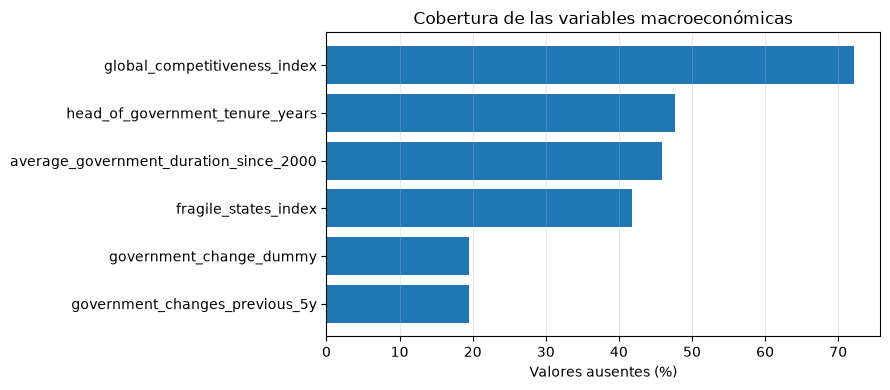

In [246]:
missing_pct = (
    political_complementary_panel[
        political_variables
    ]
    .isna()
    .mean()
    .mul(100)
    .sort_values()
)

plt.figure(figsize=(9, 4))

plt.barh(
    missing_pct.index,
    missing_pct.values
)

plt.xlabel("Valores ausentes (%)")
plt.title("Cobertura de las variables macroeconómicas")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


## Novena fase: Conflicto armado

Este bloque incorpora una medida objetiva de la intensidad de los conflictos armados mediante el número de muertes relacionadas directamente con enfrentamientos bélicos.

Los datos proceden del indicador `VC.BTL.DETH` de los Indicadores de Desarrollo Mundial del Banco Mundial. La fuente original de la información es el Uppsala Conflict Data Program —UCDP—.

El indicador contabiliza las muertes militares y civiles directamente relacionadas con combates, ataques guerrilleros, emboscadas y bombardeos producidos entre las partes participantes en un conflicto.

La variable complementa los indicadores de estabilidad política y fragilidad estatal, que se basan principalmente en valoraciones institucionales, mediante una medida cuantitativa de acontecimientos violentos observados.

             Mayor número de muertes en combate
                       ⇒ Mayor riesgo país

In [275]:
CONFLICT_INDICATORS = {
    "VC.BTL.DETH": "battle_related_deaths"
}

In [276]:
conflict_downloads = []

for indicator_code, variable_name in CONFLICT_INDICATORS.items():

    print(
        f"Descargando {variable_name} "
        f"({indicator_code})..."
    )

    indicator_data = download_indicator(
        indicator_code=indicator_code,
        variable_name=variable_name
    )

    if not indicator_data.empty:
        conflict_downloads.append(indicator_data)


if not conflict_downloads:
    raise RuntimeError(
        "No se ha descargado la variable de conflicto."
    )


wdi_conflict_long = pd.concat(
    conflict_downloads,
    ignore_index=True
)

Descargando battle_related_deaths (VC.BTL.DETH)...


In [277]:
wdi_conflict_long = (
    wdi_conflict_long[
        wdi_conflict_long["iso3"].isin(
            countries["iso3"]
        )
    ]
    .sort_values(["iso3", "year"])
    .reset_index(drop=True)
)

display(wdi_conflict_long.head())

,iso3,year,indicator_code,variable,value
0,ABW,2000,VC.BTL.DETH,battle_related_deaths,NaN
1,ABW,2001,VC.BTL.DETH,battle_related_deaths,NaN
2,ABW,2002,VC.BTL.DETH,battle_related_deaths,NaN
3,ABW,2003,VC.BTL.DETH,battle_related_deaths,NaN
4,ABW,2004,VC.BTL.DETH,battle_related_deaths,NaN


In [278]:
wdi_conflict_values = (
    wdi_conflict_long[
        ["iso3", "year", "value"]
    ]
    .rename(
        columns={
            "value": "battle_related_deaths"
        }
    )
    .drop_duplicates(
        subset=["iso3", "year"]
    )
)

In [279]:
conflict_panel = (
    country_year_grid.merge(
        wdi_conflict_values,
        on=["iso3", "year"],
        how="left",
        validate="one_to_one"
    )
    .sort_values(["iso3", "year"])
    .reset_index(drop=True)
)

In [280]:
conflict_panel["armed_conflict_dummy"] = np.where(
    conflict_panel["battle_related_deaths"].notna(),
    (
        conflict_panel["battle_related_deaths"] > 0
    ).astype(int),
    np.nan
)

conflict_panel["log_battle_related_deaths"] = np.where(
    conflict_panel["battle_related_deaths"].notna(),
    np.log1p(
        conflict_panel["battle_related_deaths"]
    ),
    np.nan
)

In [281]:
conflict_variables = [
    "battle_related_deaths",
    "armed_conflict_dummy",
    "log_battle_related_deaths"
]


summary_conflict = (
    conflict_panel[conflict_variables]
    .describe(
        percentiles=[0.25, 0.50, 0.75]
    )
    .T
)


summary_conflict["missing_values"] = (
    conflict_panel[conflict_variables]
    .isna()
    .sum()
)


summary_conflict["missing_pct"] = (
    conflict_panel[conflict_variables]
    .isna()
    .mean()
    .mul(100)
)


summary_conflict = summary_conflict[
    [
        "count",
        "missing_values",
        "missing_pct",
        "mean",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max"
    ]
].round(2)

display(summary_conflict)

,count,missing_values,missing_pct,mean,std,min,25%,50%,75%,max
battle_related_deaths,808.0,4617,85.11,2221.64,10295.63,0.0,52.00,244.5,948.25,163210.0
armed_conflict_dummy,808.0,4617,85.11,0.99,0.11,0.0,1.00,1.0,1.00,1.0
log_battle_related_deaths,808.0,4617,85.11,5.47,2.10,0.0,3.97,5.5,6.86,12.0


In [282]:
period_label = f"{START_YEAR}_{END_YEAR}"


wdi_conflict_long.to_csv(
    RAW_PATH
    / f"wdi_conflict_long_{period_label}.csv",
    index=False,
    encoding="utf-8-sig"
)


conflict_panel.to_csv(
    PROCESSED_PATH
    / f"wdi_conflict_panel_{period_label}.csv",
    index=False,
    encoding="utf-8-sig"
)


summary_conflict[
    ["count", "missing_values", "missing_pct"]
].to_csv(
    PROCESSED_PATH
    / f"wdi_conflict_coverage_{period_label}.csv",
    encoding="utf-8-sig"
)


print(
    "Variable de conflicto guardada correctamente."
)

Variable de conflicto guardada correctamente.


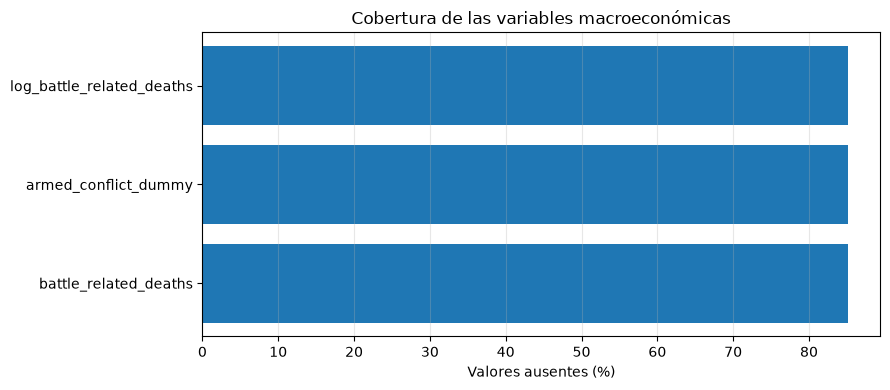

In [283]:
missing_pct = (
    conflict_panel[conflict_variables]
    .isna()
    .mean()
    .mul(100)
    .sort_values()
)

plt.figure(figsize=(9, 4))

plt.barh(
    missing_pct.index,
    missing_pct.values
)

plt.xlabel("Valores ausentes (%)")
plt.title("Cobertura de las variables macroeconómicas")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()